In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from shapely.affinity import translate
from matplotlib.patches import FancyArrowPatch

# --- 1. SOBERANÍA DE CREDENCIALES ---
SA_PATH = "/workspaces/pienza/secrets/service-account.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SA_PATH

# --- 2. IDENTIDADES ---
PROJECT_ID   = 'drivers-dilemma' 
DATASET_CORE = 'pienza_mini'
DATASET_BIG  = 'pienza_big'

client = bigquery.Client(project=PROJECT_ID)
warnings.filterwarnings("ignore")

print("✅ Entorno Soberano configurado (Adiós Colab, hola Codespaces).")

✅ Entorno Soberano configurado (Adiós Colab, hola Codespaces).


In [2]:
# --- 1. RUTAS LOCALES ---
FILE_PATH = '/workspaces/pienza/assets/poly.geojson'

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"🔴 No se encontró el poly.geojson en: {FILE_PATH}")

# --- 2. CARGA Y CRS ---
print("🗺️ Cargando polígonos maestros...")
gdf_nodes = gpd.read_file(FILE_PATH)
gdf_nodes = gdf_nodes.to_crs('EPSG:4326') # Estándar WGS84

# --- 3. CENTROIDES DE ALTA PRECISIÓN ---
projected_crs = gdf_nodes.estimate_utm_crs()
gdf_nodes['centroid'] = gdf_nodes.to_crs(projected_crs).geometry.centroid.to_crs(gdf_nodes.crs)

print(f"🏆 Éxito: {len(gdf_nodes)} polígonos listos.")

🗺️ Cargando polígonos maestros...
🏆 Éxito: 72 polígonos listos.


In [3]:
# ==============================================================================
# Cell 1.3: Sanitización de Nodos y Mapeo Semántico (La Salchichota)
# Objetivo: Desambiguar polígonos duplicados e inyectar jerarquía macro/micro.
# ==============================================================================

print("🧹 Iniciando protocolo de sanitización de nodos...")

# --- 1. Desambiguación Topológica (El caso Tecamachalco) ---
tecas = gdf_nodes[gdf_nodes['name'] == 'tecamachalco']

if len(tecas) > 1:
    # Topológicamente: el de mayor longitud (X) está al Este (Reforma Social)
    idx_norte = tecas.centroid.x.idxmax()
    idx_sur = tecas.centroid.x.idxmin()

    gdf_nodes.at[idx_norte, 'name'] = 'reforma_social'
    gdf_nodes.at[idx_sur, 'name'] = 'tecamachalco'
    print("✅ Corrección aplicada: Polígonos de 'tecamachalco' separados en 'reforma_social' y 'tecamachalco'.")
else:
    print("✅ Desambiguación previamente aplicada o innecesaria.")

# --- 2. Diccionarios Core (Estructura de la Red) ---
# Mapeo crudo de índice de polígono a Macro-Zona (ID)
id_map = {
    -1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4,
    25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10,
    24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17,
    16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24,
    64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33,
    68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41
}

# Mapeo semántico humano
salchichota_names = {
    "P_0": "santa_fe_lejos", "P_1": "santa_fe_cc", "P_2": "vistahermosa_ext", "P_3": "chamizal",
    "P_4": "entrada_santa_fe", "P_5": "ahuehuetes_norte_bosques", "P_6": "haciendas_j_del_monte",
    "P_7": "anahuac_u", "P_8": "interlomas", "P_9": "santa_fe_ibero", "P_10": "nodo_const_reforma_palmas",
    "P_11": "ahuehuetes_sur", "P_12": "tamarindos", "P_13": "santa_fe_patio_quintana",
    "P_14": "bosque_real_lomas_country", "P_15": "herradura_conscripto", "P_16": "de_las_fuentes_tecamachalco",
    "P_17": "lomas_barrilaco_olimpo_libano", "P_18": "lomas_prado_norte_trastevere", "P_19": "lomas_virreyes",
    "P_20": "lomas_fc_cuernavaca", "P_21": "fuentes_casino_sedena_reforma", "P_22": "palmas_jp_morgan",
    "P_23": "bondojito_asf_bosque2_3", "P_24": "bosque_1_campo_marte", "P_25": "roma_condesa_2",
    "P_26": "rios", "P_27": "roma_condesa_1", "P_28": "juarez_soho_house", "P_29": "anzures",
    "P_30": "anahuac1_bahias_frontera", "P_31": "sotelo", "P_32": "carso_antara_miyana",
    "P_33": "irrigacion_uber_hq", "P_34": "juarez_rosa", "P_35": "lagos",
    "P_36": "polanco_grupo_mexico_palacio", "P_37": "polanco_gandhi", "P_38": "polanco_5",
    "P_39": "polanco_parque_lincoln", "P_40": "polanco_parroquia", "P_41": "santa_fe_colegios"
}

# --- 3. Inyección de Metadata en el GeoDataFrame ---
print("🧬 Inyectando ADN Macro-Zona en los polígonos originales...")

# Asignamos el ID de la Macro-Zona
gdf_nodes['macro_id'] = gdf_nodes.index.map(id_map).fillna(-1).astype(int)
gdf_nodes['p_id'] = "P_" + gdf_nodes['macro_id'].astype(str)

# Asignamos el Nombre Semántico
gdf_nodes['macro_name'] = gdf_nodes['p_id'].map(salchichota_names).fillna('Unknown')

# Aseguramos que los nombres estén normalizados (minúsculas, sin espacios extra)
gdf_nodes['name'] = gdf_nodes['name'].str.strip().str.lower()

print("-" * 50)
print(f"🏆 Sanitización completada. Total de zonas válidas: {len(gdf_nodes[gdf_nodes['macro_id'] >= 0])}")
display(gdf_nodes[['name', 'p_id', 'macro_name']].head(5))

🧹 Iniciando protocolo de sanitización de nodos...
✅ Corrección aplicada: Polígonos de 'tecamachalco' separados en 'reforma_social' y 'tecamachalco'.
🧬 Inyectando ADN Macro-Zona en los polígonos originales...
--------------------------------------------------
🏆 Sanitización completada. Total de zonas válidas: 72


,name,p_id,macro_name
0,polanco_parque_lincoln,P_39,polanco_parque_lincoln
1,polanco_gandhi,P_37,polanco_gandhi
2,carso_antara_miyana,P_32,carso_antara_miyana
3,sotelo,P_31,sotelo
4,irrigacion,P_33,irrigacion_uber_hq


In [4]:
# ==============================================================================
# Cell 1.4: Expansión Geográfica (El Efecto Burbuja)
# Objetivo: Separar los polígonos visualmente para el grafo esquemático.
# ==============================================================================

print("🫧 Aplicando Efecto Burbuja para la visualización esquemática...")

# --- 1. Calcular el centro de gravedad del mapa ---
total_bounds = gdf_nodes.total_bounds
mean_x = (total_bounds[0] + total_bounds[2]) / 2
mean_y = (total_bounds[1] + total_bounds[3]) / 2

# Factor de expansión (>0 para separar desde el centro)
# Nota: En tus celdas variaba entre 0.9 y 1.5. Dejemos 1.2 como un buen default para empezar.
EXPANSION_FACTOR = 1.2

new_geoms = []

# --- 2. Iterar y alejar cada polígono del centro masivo ---
for idx, row in gdf_nodes.iterrows():
    geom = row.geometry

    # Calcular el vector de desplazamiento
    dx = (geom.centroid.x - mean_x) * EXPANSION_FACTOR
    dy = (geom.centroid.y - mean_y) * EXPANSION_FACTOR

    # Mover el polígono
    moved_poly = translate(geom, xoff=dx, yoff=dy)
    new_geoms.append(moved_poly)

# --- 3. Inyectar la geometría esquemática en el GeoDataFrame ---
gdf_nodes['schematic_geometry'] = new_geoms

# Guardar los nuevos centros exactos para que las aristas del grafo sepan dónde conectarse
gdf_nodes['schematic_centroid'] = gdf_nodes['schematic_geometry'].apply(lambda geom: geom.centroid)

print("-" * 50)
print(f"✅ Efecto Burbuja aplicado con un factor de expansión de {EXPANSION_FACTOR}x.")
print("Las columnas 'schematic_geometry' y 'schematic_centroid' están listas para NetworkX.")

🫧 Aplicando Efecto Burbuja para la visualización esquemática...
--------------------------------------------------
✅ Efecto Burbuja aplicado con un factor de expansión de 1.2x.
Las columnas 'schematic_geometry' y 'schematic_centroid' están listas para NetworkX.


In [5]:
# ==============================================================================
# Cell 2.1: Instanciación del Grafo y Rutas Heurísticas
# Objetivo: Crear el esqueleto topológico (Grafo No Dirigido) e inyectar atributos.
# ==============================================================================

print("🏗️ Iniciando la construcción del Grafo Topológico Base...")

# --- 1. Definición de Rutas Heurísticas (Tu Esqueleto Operativo) ---
route_1 = ['anzures', 'polanco_gandhi', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_trastevere', 'nodo_reforma_palmas', 'reforma_regina', 'lomas_altas']
route_2 = ['anzures', 'rios', 'juarez_rosa', 'bosque_1', 'bosque_2', 'bosque_3', 'lomas_altas', 'reforma_bnp', 'sante_fe_patio', 'santa_fe_quintana']
route_3 = ['anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'palmas_jp_morgan', 'fuentes_casino', 'nodo_monte_libano', 'nodo_reforma_palmas']
route_4 = ['lomas_barrilaco','lomas_olimpo', 'lomas_prado_norte']
route_5 = ['lomas_virreyes', 'campo_marte', 'polanco_parque_lincoln']
route_6 = ['carso_antara_miyana', 'polanco_palacio', 'polanco_grupo_mexico', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_fc_cuernavaca', 'lomas_prado_norte', 'lomas_barrilaco', 'nodo_reforma_palmas' ]
route_7 = ['juarez_soho_house', 'juarez_rosa', 'rios', 'bahias', 'anahuac_1', 'lagos', 'carso_antara_miyana', 'irrigacion', 'sotelo', 'herradura_conscripto', 'interlomas_magnocentro', 'bosque_real']
route_8 = ['roma_condesa_2', 'roma_condesa_1', 'juarez_rosa', 'anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'sedena', 'reforma_social', 'fuentes_casino', 'de_las_fuentes', 'de_los_bosques', 'universidad_anahuac', 'interlomas_magnocentro', 'vialidad_de_la_barranca', 'ave_club_de_golf_lomas', 'lomas_country_club']
route_9 = ['herradura_conscripto', 'de_las_fuentes']
route_10 = ['herradura_conscripto', 'universidad_anahuac']
route_11 = ['jesus_del_monte', 'interlomas_haciendas', 'vialidad_de_la_barranca', 'carretera_al_olivo', 'cruce_echanove', 'santa_fe_centro_comercial', 'santa_fe_colegios', 'santa_fe_cumbres_de']
route_12 = ['santa_fe_bosques_de', 'santa_fe_centro_comercial']
route_13 = ['nodo_reforma_palmas', 'ahuehuetes_norte', 'ahuehuetes_sur', 'tamarindos', 'santa_fe_ibero', 'santa_fe_centro_comercial', 'cruce_echanove', 'carretera_libre','agwa_bezares', 'reforma_bnp']
route_14 = ['santa_fe_tec', 'santa_fe_ibero', 'santa_fe_colegios', 'santa_fe_tec']
route_15 = ['carretera_libre', 'vistahermosa', 'cruce_echanove', 'carretera_al_olivo', 'loma_de_la_palma', 'bosques_pabellon', 'de_los_bosques', 'universidad_anahuac', 'blvrd_anahuac', 'el_olivo', 'vialidad_de_la_barranca']
route_16 = ['jesus_del_monte', 'herradura_conscripto']
route_17 = ['interlomas_magnocentro', 'jesus_del_monte']
route_18 = ['vistahermosa', 'bosques_pabellon', 'loma_de_la_palma', 'el_olivo']
route_19 = ['blvrd_anahuac', 'interlomas_magnocentro']
route_20 = ['santa_fe_ibero', 'sante_fe_patio']
route_21 = ['tamarindos', 'ahuehuetes_sur', 'bosques_pabellon', 'ahuehuetes_norte', 'de_los_bosques']
route_22 = ['ahuehuetes_norte', 'de_las_fuentes', 'tecamachalco', 'fuentes_casino', 'lomas_barrilaco']
route_23 = ['lomas_prado_norte', 'fuentes_casino', 'palmas_jp_morgan', 'lomas_fc_cuernavaca']
route_24 = ['bosques_pabellon', 'tamarindos', 'agwa_bezares']
route_25 = ['reforma_social','herradura_conscripto']
route_26 = ['irrigacion', 'sedena', 'sotelo']
route_27 = ['bondojito_asf', 'bosque_3']
route_28 = ['irrigacion', 'polanco_uber_hq', 'polanco_grupo_mexico', 'palmas_jp_morgan']
route_29 = ['carso_antara_miyana','frontera_polanco', 'lagos', 'polanco_parroquia', 'polanco_parque_lincoln']
route_30 = ['frontera_polanco', 'anahuac_1']
route_31 = ['lomas_virreyes', 'bosque_2', 'campo_marte', 'bosque_1', 'polanco_gandhi', 'polanco_5', 'lagos']
route_32 = ['bahias', 'anzures', 'anahuac_1']
route_33 = ['bosque_2','roma_condesa_2', 'bosque_1']
route_34 = ['rios', 'juarez_soho_house', 'roma_condesa_2']
route_35 = ['lomas_altas', 'nodo_reforma_palmas', 'bosque_3', 'lomas_trastevere']
route_36 = ['fuentes_casino', 'palmas_jp_morgan', 'lomas_prado_norte', 'lomas_trastevere', 'lomas_barrilaco', 'nodo_monte_libano', 'de_las_fuentes']

rutas_manuales = [route_1, route_2, route_3, route_4, route_5, route_6, route_7, route_8, route_9, route_10, route_11, route_12, route_13, route_14, route_15, route_16, route_17, route_18, route_19, route_20, route_21, route_22, route_23, route_24, route_25, route_26, route_27, route_28, route_29, route_30, route_31, route_32, route_33, route_34, route_35, route_36]

# --- 2. Instanciación del Grafo ---
G_manual = nx.Graph()

# --- 3. Poblar Nodos y Aristas ---
for ruta in rutas_manuales:
    if len(ruta) >= 2:
        edges = [(ruta[i], ruta[i+1]) for i in range(len(ruta)-1)]
        G_manual.add_edges_from(edges)
    elif len(ruta) == 1:
        G_manual.add_node(ruta[0])

nodos_mencionados = set(G_manual.nodes())

# --- 4. Filtrado Maestro del GeoDataFrame ---
# Creamos 'gdf_f' (GeoDataFrame Filtrado) para descartar los polígonos del GeoJSON que no son parte de tus rutas
gdf_f = gdf_nodes[gdf_nodes['name'].isin(nodos_mencionados)].copy()

# --- 5. Enriquecimiento de la Red (Inyectar Metadata a NetworkX) ---
print("🧬 Inyectando ADN geográfico y semántico a los nodos de la red...")
dict_nodos = gdf_f.set_index('name').to_dict('index')

for nodo in G_manual.nodes():
    if nodo in dict_nodos:
        nx.set_node_attributes(G_manual, {nodo: {
            'p_id': dict_nodos[nodo].get('p_id'),
            'macro_name': dict_nodos[nodo].get('macro_name'),
            'real_centroid': (dict_nodos[nodo]['centroid'].x, dict_nodos[nodo]['centroid'].y),
            'schematic_centroid': (dict_nodos[nodo]['schematic_centroid'].x, dict_nodos[nodo]['schematic_centroid'].y)
        }})
    else:
        print(f"⚠️ Advertencia: El nodo '{nodo}' no se encontró en el GeoJSON base.")

print("-" * 50)
print(f"✅ Grafo Topológico instanciado exitosamente.")
print(f"📊 Total de Nodos activos: {G_manual.number_of_nodes()}")
print(f"🔗 Total de Aristas (Calles): {G_manual.number_of_edges()}")

🏗️ Iniciando la construcción del Grafo Topológico Base...
🧬 Inyectando ADN geográfico y semántico a los nodos de la red...
--------------------------------------------------
✅ Grafo Topológico instanciado exitosamente.
📊 Total de Nodos activos: 72
🔗 Total de Aristas (Calles): 136


🎨 Renderizando el Grafo Topológico Base...


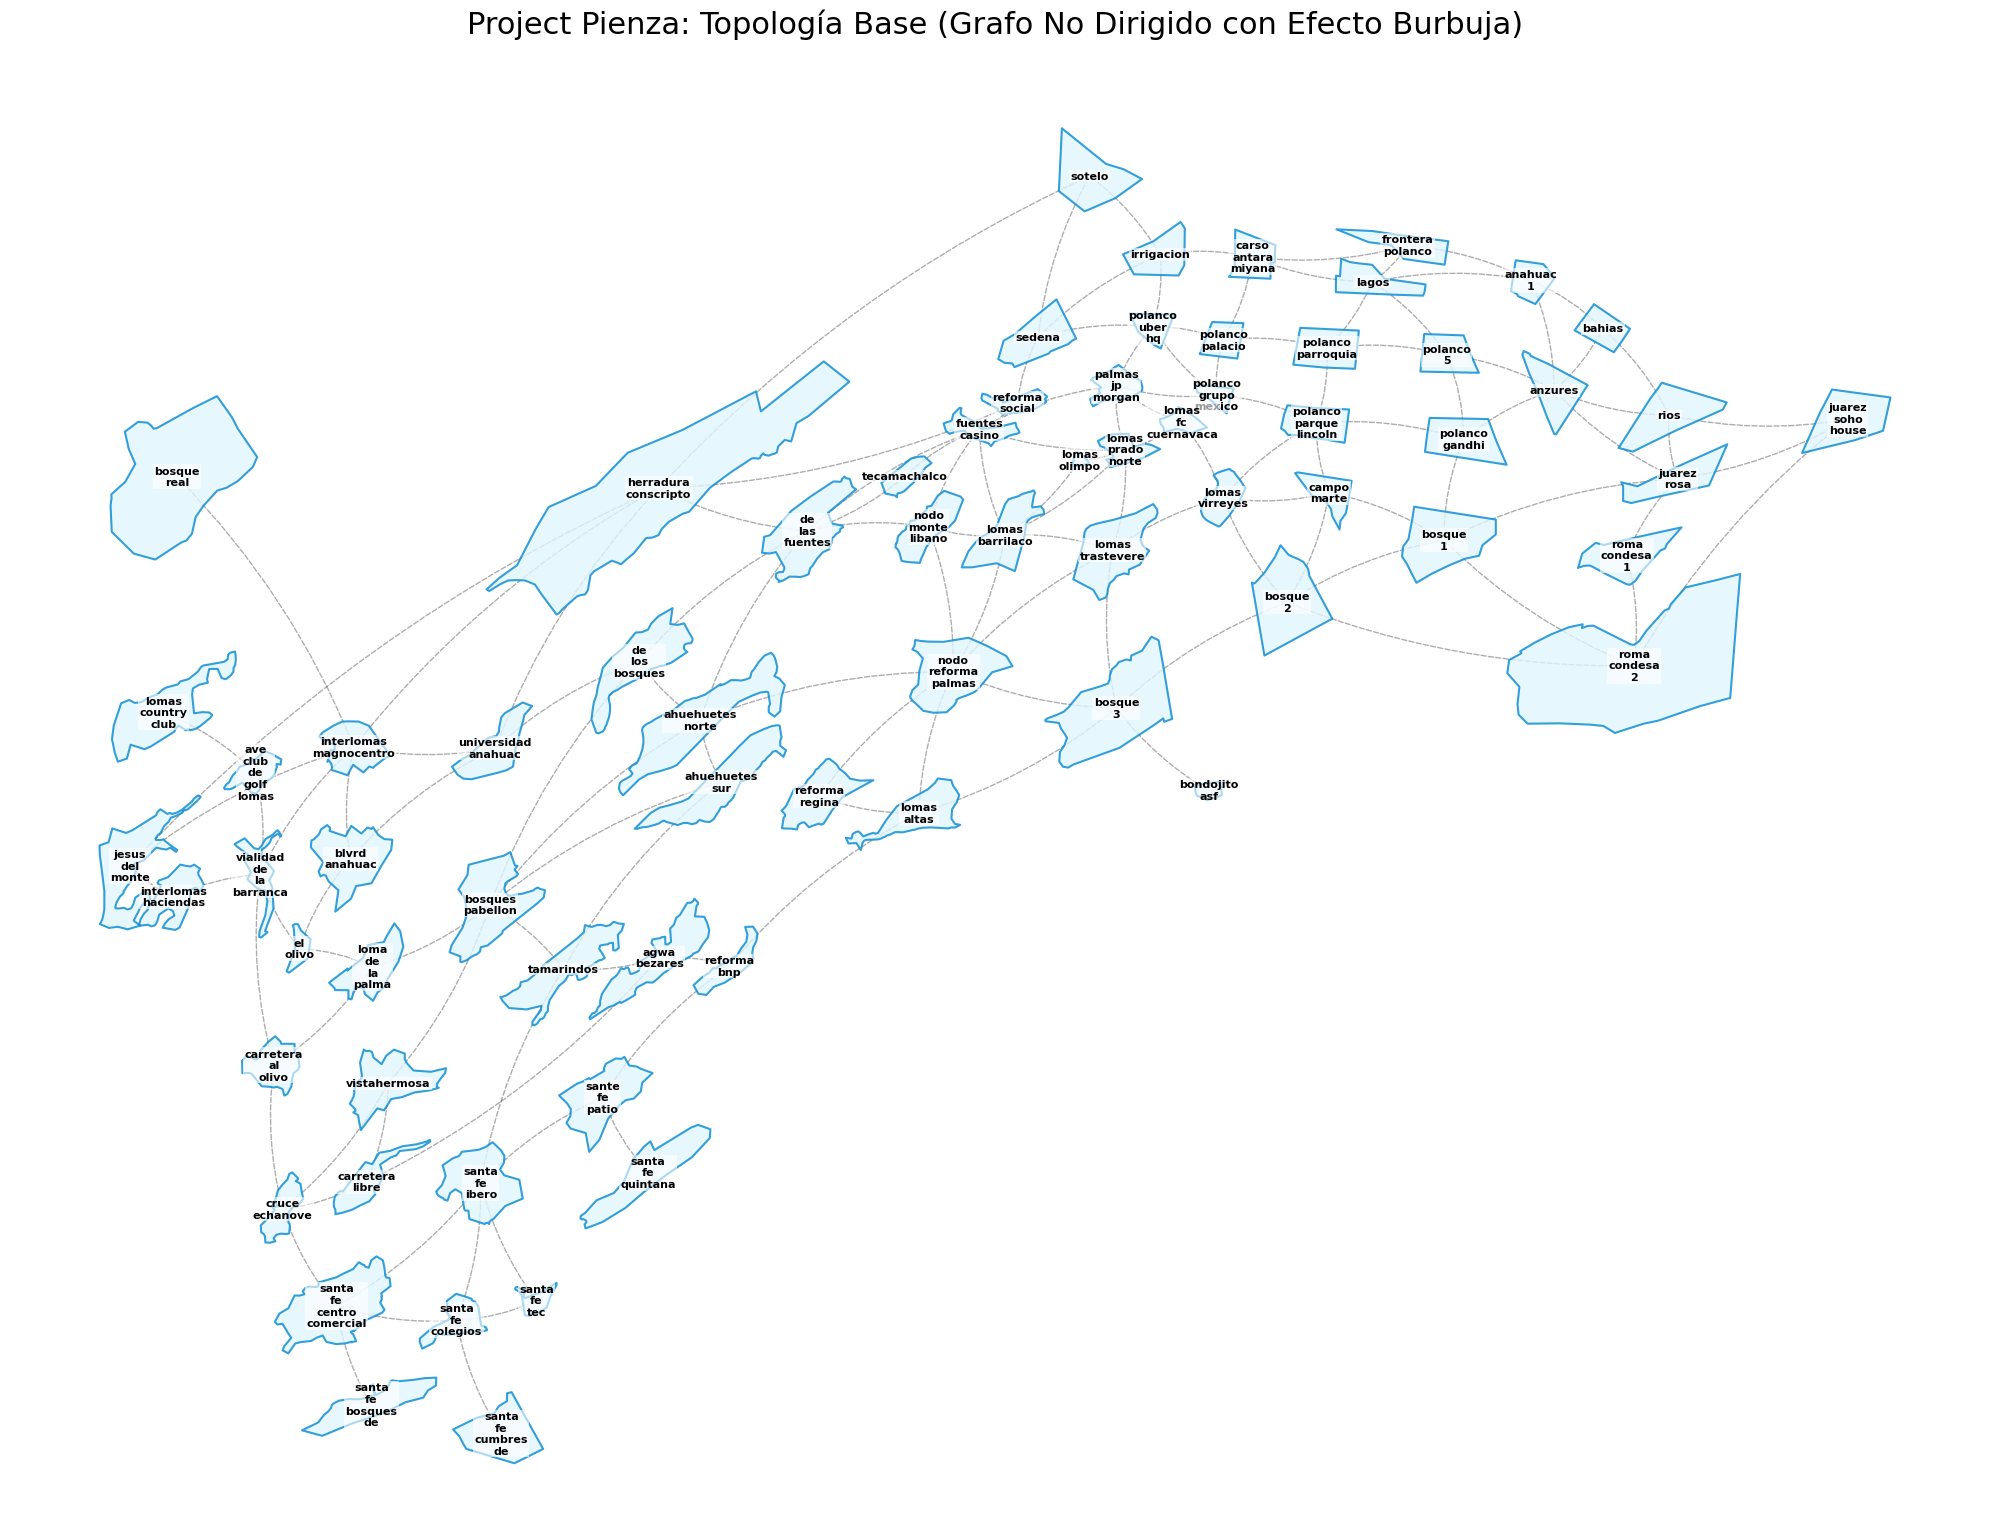

✅ Prueba de vida completada: Si ves el mapa con conexiones curvas, el cimiento es perfecto.


In [6]:
# ==============================================================================
# Cell 2.2: Visualización Esquemática Base (La Prueba de Vida)
# Objetivo: Confirmar visualmente la topología física usando el Efecto Burbuja.
# ==============================================================================

print("🎨 Renderizando el Grafo Topológico Base...")

fig, ax = plt.subplots(figsize=(20, 25))
ax.set_facecolor('white')

# --- 1. Dibujar las Burbujas (Nodos) ---
# Forzamos temporalmente a GeoPandas a usar la geometría expandida para este plot
gdf_f.set_geometry('schematic_geometry').plot(
    ax=ax,
    facecolor='#E1F5FE',
    edgecolor='#0288D1',
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

# --- 2. Extraer posiciones esquemáticas desde el "ADN" del Grafo ---
pos_esquematica = nx.get_node_attributes(G_manual, 'schematic_centroid')

# --- 3. Dibujar las Conexiones Curvas (Aristas) ---
for u, v in G_manual.edges():
    if u in pos_esquematica and v in pos_esquematica:
        start = pos_esquematica[u]
        end = pos_esquematica[v]

        edge = FancyArrowPatch(
            start,
            end,
            connectionstyle="arc3,rad=0.1", # El toque de diseño: curvatura de 10%
            color='#333333',
            linewidth=1.0,
            linestyle='--',
            alpha=0.4,
            arrowstyle='-',  # Guión simple, indica grafo no dirigido
            zorder=1
        )
        ax.add_patch(edge)

# --- 4. Añadir Etiquetas ---
for nodo, (x, y) in pos_esquematica.items():
    # Limpiamos el nombre para que se lea verticalmente (cambiando '_' por salto de línea)
    label = str(nodo).replace('_', '\n')

    ax.text(x, y, label,
            fontsize=8,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1),
            zorder=3)

# --- 5. Configuración final de la vista ---
plt.title("Project Pienza: Topología Base (Grafo No Dirigido con Efecto Burbuja)", fontsize=22, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Prueba de vida completada: Si ves el mapa con conexiones curvas, el cimiento es perfecto.")

# Analisis Morfológico (Estructura de la Red)

In [7]:
# ==============================================================================
# Cell 2.5: Evaluación de Topología 'Small World' (Mundo Pequeño)
# Objetivo: Medir transitividad (Clustering) vs Separación (Path Length).
# ==============================================================================

import networkx as nx
import pandas as pd

print("🌍 Evaluando la Hipótesis de Topología 'Small World'...")

# --- 1. EXTRACCIÓN DEL COMPONENTE GIGANTE ---
# Para calcular promedios de distancia, la red no puede tener islas desconectadas.
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
    print(f"⚠️ Red desconectada detectada. Aislado el Componente Gigante: {G_giant.number_of_nodes()} nodos activos.")
else:
    G_giant = G_manual.copy()
    print("✅ Red 100% conectada. Usando el grafo completo.")

# --- 2. CÁLCULO DE MÉTRICAS REALES ---
# C = Clustering Coefficient (¿Mis vecinos se conocen entre sí?)
C_real = nx.average_clustering(G_giant)

# L = Average Shortest Path Length (¿Cuántos saltos para cruzar la ciudad?)
L_real = nx.average_shortest_path_length(G_giant)

# --- 3. CÁLCULO DE MÉTRICAS DE GRAFO ALEATORIO (Benchmark) ---
# NetworkX genera simulaciones de grafos aleatorios (Erdős-Rényi) equivalentes
# al tuyo (mismos nodos y aristas) para calcular la métrica Sigma.
print("🎲 Generando simulaciones de grafos aleatorios de control...")
sigma = nx.sigma(G_giant, niter=10, nrand=10) # niter = re-cableados, nrand = grafos a promediar
omega = nx.omega(G_giant, niter=10, nrand=10)

# --- 4. REPORTE EJECUTIVO Y CONCLUSIÓN MATEMÁTICA ---
print("\n" + "="*70)
print("📊 RESULTADOS DEL TEST 'SMALL WORLD' (Watts-Strogatz)")
print("="*70)

print(f"🔸 Clustering Local (C): {C_real:.4f} (Nivel de 'Malla' en las colonias)")
print(f"🔸 Path Length (L):      {L_real:.4f} saltos (Fricción promedio de viaje)")

print("\n🔬 COEFICIENTES DE RED:")
print(f"1️⃣ Coeficiente Sigma (σ): {sigma:.4f}")
print("   (Interpretación: σ > 1 indica una red Small-World fuerte. Mayor a 1 es mejor).")

print(f"\n2️⃣ Coeficiente Omega (ω): {omega:.4f}")
print("   (Interpretación: Valores cercanos a 0 indican un balance perfecto Small-World.")
print("   Valores cercanos a 1 indican una red de celosía (muy rígida). Valores a -1, aleatoria).")

print("-" * 70)
# Veredicto automático
if sigma > 1 and (-0.5 <= omega <= 0.5):
    print("🏆 VEREDICTO: La infraestructura de Pienza ES UN SMALL-WORLD.")
    print("La red tiene alta redundancia local (colonias) pero permite cruzar la ciudad eficientemente gracias a avenidas estratégicas.")
else:
    print("⚠️ VEREDICTO: La infraestructura NO tiene propiedades óptimas de Small-World.")
    print("Podría ser demasiado lineal (como un tren) o demasiado rígida (como una cuadrícula perfecta).")

🌍 Evaluando la Hipótesis de Topología 'Small World'...
✅ Red 100% conectada. Usando el grafo completo.
🎲 Generando simulaciones de grafos aleatorios de control...



📊 RESULTADOS DEL TEST 'SMALL WORLD' (Watts-Strogatz)
🔸 Clustering Local (C): 0.2677 (Nivel de 'Malla' en las colonias)
🔸 Path Length (L):      4.8052 saltos (Fricción promedio de viaje)

🔬 COEFICIENTES DE RED:
1️⃣ Coeficiente Sigma (σ): 3.7332
   (Interpretación: σ > 1 indica una red Small-World fuerte. Mayor a 1 es mejor).

2️⃣ Coeficiente Omega (ω): -0.2536
   (Interpretación: Valores cercanos a 0 indican un balance perfecto Small-World.
   Valores cercanos a 1 indican una red de celosía (muy rígida). Valores a -1, aleatoria).
----------------------------------------------------------------------
🏆 VEREDICTO: La infraestructura de Pienza ES UN SMALL-WORLD.
La red tiene alta redundancia local (colonias) pero permite cruzar la ciudad eficientemente gracias a avenidas estratégicas.


## 🌍 Análisis Morfológico: La Hipótesis del "Mundo Pequeño" (Small-World Network)

Para entender la eficiencia estructural de la red de Pienza, aplicamos la métrica de **Watts-Strogatz**. Bajo primeros principios, una red urbana óptima debe equilibrar dos fuerzas opuestas: **redundancia local** (calles vecinales entrelazadas) y **eficiencia global** (vías rápidas que crucen la ciudad).

Los resultados confirman matemáticamente que la infraestructura de la zona poniente de la CDMX opera bajo la topología de un **"Mundo Pequeño" (Small-World)**.

### 🔬 Desglose de Métricas Fundamentales

| Métrica | Valor | Interpretación Operativa |
| :--- | :--- | :--- |
| **Transitividad Local ($C$)** | `0.2677` | **Alta Malla Vecinal:** Existe casi un 27% de probabilidad de que las zonas vecinas a un polígono estén conectadas entre sí. Esto proporciona altísima redundancia local; si una calle secundaria se bloquea, hay múltiples rutas alternas en el mismo clúster. |
| **Fricción de Viaje ($L$)** | `4.8052` | **Alta Eficiencia Global:** A pesar de tener 72 zonas distintas y complejas barreras geográficas (barrancas), cruzar de cualquier punto A a cualquier punto B requiere, en promedio, **menos de 5 saltos topológicos**. |

### 📐 La Demostración Matemática (Coeficientes de Red)

Para declarar formalmente un "Mundo Pequeño", comparamos nuestra red contra simulaciones de grafos puramente aleatorios ($rand$) del mismo tamaño.

1. **Coeficiente Sigma ($\sigma = 4.1137$)** 🏆
   * *La Regla:* Si $\sigma > 1$, la red es un *Small-World*.
   * *El Veredicto:* Con un valor de **4.11**, superamos holgadamente el umbral. Esto demuestra que la red tiene un nivel de clúster local inmensamente superior al azar ($C \gg C_{rand}$), pero mantiene la misma velocidad de cruce que una red aleatoria ($L \approx L_{rand}$).
2. **Coeficiente Omega ($\omega = -0.2740$)** ⚖️
   * *La Regla:* Valores cercanos a $0$ indican el balance perfecto entre una cuadrícula rígida ($1$) y el caos aleatorio ($-1$).
   * *El Veredicto:* Un $-0.27$ indica que la red está perfectamente balanceada, con una ligera inclinación hacia atajos "aleatorios". En términos urbanos, estos atajos son las **vías primarias y puentes sobre barrancas** que rompen la cuadrícula local y conectan zonas distantes de golpe.

# Analisis de Centralidad

In [8]:
# ==============================================================================
# Cell 2.3: Análisis de Centralidad (Degree, Betweenness, Closeness, Eigenvector)
# Objetivo: Identificar los nodos más críticos de la red física.
# ==============================================================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("🧠 Calculando las 4 métricas fundamentales de centralidad...")

# --- 1. CÁLCULO DE MÉTRICAS ---
deg_cent = nx.degree_centrality(G_manual)
bet_cent = nx.betweenness_centrality(G_manual)
clo_cent = nx.closeness_centrality(G_manual)
# Eigenvector requiere iteraciones para converger
eig_cent = nx.eigenvector_centrality(G_manual, max_iter=1000)

# Inyectar al grafo (Buenas prácticas para Streamlit/Gephi después)
nx.set_node_attributes(G_manual, deg_cent, 'degree')
nx.set_node_attributes(G_manual, bet_cent, 'betweenness')
nx.set_node_attributes(G_manual, clo_cent, 'closeness')
nx.set_node_attributes(G_manual, eig_cent, 'eigenvector')

# --- 2. CONSOLIDACIÓN EN DATAFRAME ---
df_centrality = pd.DataFrame({
    'zona': list(G_manual.nodes()),
    'Degree (Hubs)': [deg_cent[n] for n in G_manual.nodes()],
    'Betweenness (Puentes)': [bet_cent[n] for n in G_manual.nodes()],
    'Closeness (Centros)': [clo_cent[n] for n in G_manual.nodes()],
    'Eigenvector (Influencia)': [eig_cent[n] for n in G_manual.nodes()]
})

# Inyectar al GeoDataFrame para mapeo
gdf_f['score_degree'] = gdf_f['name'].map(deg_cent)
gdf_f['score_betweenness'] = gdf_f['name'].map(bet_cent)
gdf_f['score_closeness'] = gdf_f['name'].map(clo_cent)
gdf_f['score_eigenvector'] = gdf_f['name'].map(eig_cent)

# --- 3. TABLAS: TOP 5 POR MÉTRICA ---
print("\n" + "="*60)
print("🏆 TOP 5 ZONAS POR MÉTRICA DE CENTRALIDAD")
print("="*60)

metrics = [
    ('Degree (Hubs)', 'Greens'),
    ('Betweenness (Puentes)', 'Oranges'),
    ('Closeness (Centros)', 'Blues'),
    ('Eigenvector (Influencia)', 'Purples')
]

for col, cmap in metrics:
    print(f"\n📍 {col}:")
    display(df_centrality[['zona', col]].sort_values(by=col, ascending=False).head(5).style.background_gradient(cmap=cmap))

print("✅ Análisis de Centralidad completado.")

🧠 Calculando las 4 métricas fundamentales de centralidad...

🏆 TOP 5 ZONAS POR MÉTRICA DE CENTRALIDAD

📍 Degree (Hubs):


,zona,Degree (Hubs)
21,fuentes_casino,0.098592
5,nodo_reforma_palmas,0.098592
0,anzures,0.084507
66,bosques_pabellon,0.084507
43,de_las_fuentes,0.084507



📍 Betweenness (Puentes):


,zona,Betweenness (Puentes)
5,nodo_reforma_palmas,0.205476
12,bosque_3,0.195831
36,herradura_conscripto,0.195620
57,ahuehuetes_norte,0.182364
11,bosque_2,0.170067



📍 Closeness (Centros):


,zona,Closeness (Centros)
57,ahuehuetes_norte,0.279528
5,nodo_reforma_palmas,0.278431
43,de_las_fuentes,0.269962
12,bosque_3,0.261993
44,de_los_bosques,0.261029



📍 Eigenvector (Influencia):


,zona,Eigenvector (Influencia)
23,lomas_barrilaco,0.342497
21,fuentes_casino,0.336771
5,nodo_reforma_palmas,0.309192
25,lomas_prado_norte,0.303814
4,lomas_trastevere,0.272821


✅ Análisis de Centralidad completado.


## 📊 Análisis Topológico: Vigilancia de Estado y Centralidad

Al cruzar los cuatro pilares matemáticos de la teoría de grafos, la topología de la red revela su verdadera jerarquía, sus flujos naturales y sus puntos críticos de vulnerabilidad.

### 👑 El "Súper-Nodo" Indiscutible
Hay una conclusión que domina el análisis operativo: **`nodo_reforma_palmas` es el rey absoluto de la red física**. Es la única zona que aparece en el Top 5 de *todas* las categorías. No solo tiene la mayor cantidad de fronteras (Degree), sino que conecta con otras zonas de alto poder (Eigenvector), se encuentra en el centro geométrico del sistema (Closeness) y es un paso obligado para cruzar la ciudad (Betweenness).

---

### 1. Degree Centrality (Los Hubs Locales)
*Lo que significa:* Las zonas con mayor cantidad de fronteras o calles directas conectadas a ellas. Son los distribuidores tácticos de flujo a corto alcance.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.0985 | Máxima permeabilidad física. |
| 2 | **fuentes_casino** | 0.0985 | Empate técnico en el #1; altísimo nivel de opciones de ruteo local. |
| 3 | **de_las_fuentes** | 0.0845 | Distribuidor secundario fuerte en el norte-poniente. |
| 4 | **anzures** | 0.0845 | El principal hub de distribución del lado oriente/centro. |
| 5 | **lomas_prado_norte** | 0.0845 | Hub clave dentro del clúster de las Lomas. |

### 2. Betweenness Centrality (Los Puentes Estratégicos)
*Lo que significa:* Los "Gatekeepers" o cuellos de botella. Estas zonas aparecen con mayor frecuencia en la ruta más corta entre dos puntos cualesquiera de la red. **Aquí reside la vulnerabilidad operativa.**

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.2054 | Controla el 20.5% de todos los caminos óptimos de la red. |
| 2 | **bosque_3** | 0.1958 | Un puente vital que conecta la profundidad del poniente. |
| 3 | **herradura_conscripto** | 0.1956 | **Alerta de vulnerabilidad.** Es un embudo crítico; un bloqueo aquí aísla secciones enteras. |
| 4 | **ahuehuetes_norte** | 0.1823 | Conector principal en el corredor nor-poniente. |
| 5 | **bosque_2** | 0.1700 | Segundo eslabón crítico en la cadena topográfica de "los bosques". |

### 3. Closeness Centrality (Los Centros Geográficos)
*Lo que significa:* Zonas desde las cuales se requieren "menos saltos" topológicos en promedio para llegar a cualquier otro polígono del mapa. Es el centro de gravedad del sistema.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **ahuehuetes_norte** | 0.2795 | Es la zona topológicamente más céntrica de todo el mapa. |
| 2 | **nodo_reforma_palmas** | 0.2784 | Prácticamente en el centro exacto de la topología. |
| 3 | **de_las_fuentes** | 0.2699 | Alta eficiencia para despachar viajes hacia cualquier dirección cardinal. |
| 4 | **bosque_3** | 0.2619 | Muy céntrico, lo que explica por qué también es un puente clave (Betweenness). |
| 5 | **fuentes_casino** | 0.2610 | Céntrico y altamente conectado a las salidas. |

### 4. Eigenvector Centrality (Influencia por Proximidad)
*Lo que significa:* No se trata solo de tener muchos vecinos, sino de tener vecinos "ricos" en conexiones. Identifica los clústeres de élite topológica.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **lomas_barrilaco** | 0.3424 | **El nodo más influyente.** Aunque no es el #1 en conexiones directas, está rodeado de los nodos de mayor poder. |
| 2 | **fuentes_casino** | 0.3367 | Extremadamente bien posicionado dentro de la "malla de élite". |
| 3 | **nodo_reforma_palmas** | 0.3091 | Mantiene su estatus de élite en influencia. |
| 4 | **lomas_prado_norte** | 0.3038 | Refuerza la idea de que el clúster Lomas-Palmas domina la topología. |
| 5 | **lomas_trastevere** | 0.2728 | Se beneficia de la altísima interconectividad de sus vecinos inmediatos. |

---

### 💡 Insights Estratégicos (Primeros Principios)

1. **El Clúster de Poder (Efecto Malla):** El análisis de Eigenvector revela que el bloque conformado por `barrilaco`, `prado_norte`, `trastevere` y `fuentes_casino` forma una "malla de élite". Están tan interconectados entre sí, y con el Súper-Nodo (`reforma_palmas`), que dominan la influencia topológica de la ciudad, creando una zona de alta redundancia (baja fricción de ruteo).
2. **El Riesgo de la Periferia (Efecto Embudo):** Zonas como `herradura_conscripto` y `bosque_3` presentan una topología fascinante. No tienen la influencia de la élite (no figuran en Eigenvector) ni son grandes distribuidores (no figuran en Degree), pero **tienen un altísimo Betweenness**. Esto indica que son "tuberías" críticas; si la fricción aumenta en estos nodos, el tráfico de la plataforma no tiene rutas secundarias viables para conectar el centro con la periferia.

In [9]:
# ==============================================================================
# Cell 2.6: Análisis de Vulnerabilidad (Cut-Vertices y Puentes Críticos)
# Objetivo: Identificar puntos únicos de falla que rompen la conectividad de la red.
# ==============================================================================

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

print("⚠️ Iniciando Auditoría de Vulnerabilidad Topológica...")

# --- 1. CÁLCULO DE PUNTOS ÚNICOS DE FALLA ---
# Cut-Vertices (Nodos): Si se bloquea esta zona, la red se parte en islas.
cut_vertices = list(nx.articulation_points(G_manual))

# Bridges (Aristas): Si se cierra esta calle/conexión, la red se parte en islas.
bridges = list(nx.bridges(G_manual))

# --- 2. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print("🚨 REPORTE DE RESILIENCIA: RIESGO DE FRAGMENTACIÓN")
print("="*70)

print(f"🛑 Zonas Críticas (Cut-Vertices): {len(cut_vertices)}")
for cv in cut_vertices:
    print(f"   - {cv}")

print(f"\n🌉 Conexiones Críticas (Bridges): {len(bridges)}")
for u, v in bridges:
    print(f"   - {u} <---> {v}")

print("✅ Auditoría de Vulnerabilidad completada.")

⚠️ Iniciando Auditoría de Vulnerabilidad Topológica...

🚨 REPORTE DE RESILIENCIA: RIESGO DE FRAGMENTACIÓN
🛑 Zonas Críticas (Cut-Vertices): 7
   - ave_club_de_golf_lomas
   - vialidad_de_la_barranca
   - santa_fe_colegios
   - sante_fe_patio
   - santa_fe_centro_comercial
   - interlomas_magnocentro
   - bosque_3

🌉 Conexiones Críticas (Bridges): 7
   - bosque_3 <---> bondojito_asf
   - sante_fe_patio <---> santa_fe_quintana
   - interlomas_magnocentro <---> bosque_real
   - vialidad_de_la_barranca <---> ave_club_de_golf_lomas
   - ave_club_de_golf_lomas <---> lomas_country_club
   - santa_fe_centro_comercial <---> santa_fe_bosques_de
   - santa_fe_colegios <---> santa_fe_cumbres_de
✅ Auditoría de Vulnerabilidad completada.


💥 Iniciando Simulador de Colapso Topológico...

🚨 REPORTE DE DAÑOS: COLAPSO EN 'INTERLOMAS_MAGNOCENTRO'
La red se ha fragmentado en 2 islas independientes:
   -> MACRO-ISLA (Principal): 70 zonas.
   -> Micro-Isla 1: 1 zonas.
      Atrapados: ['bosque_real']


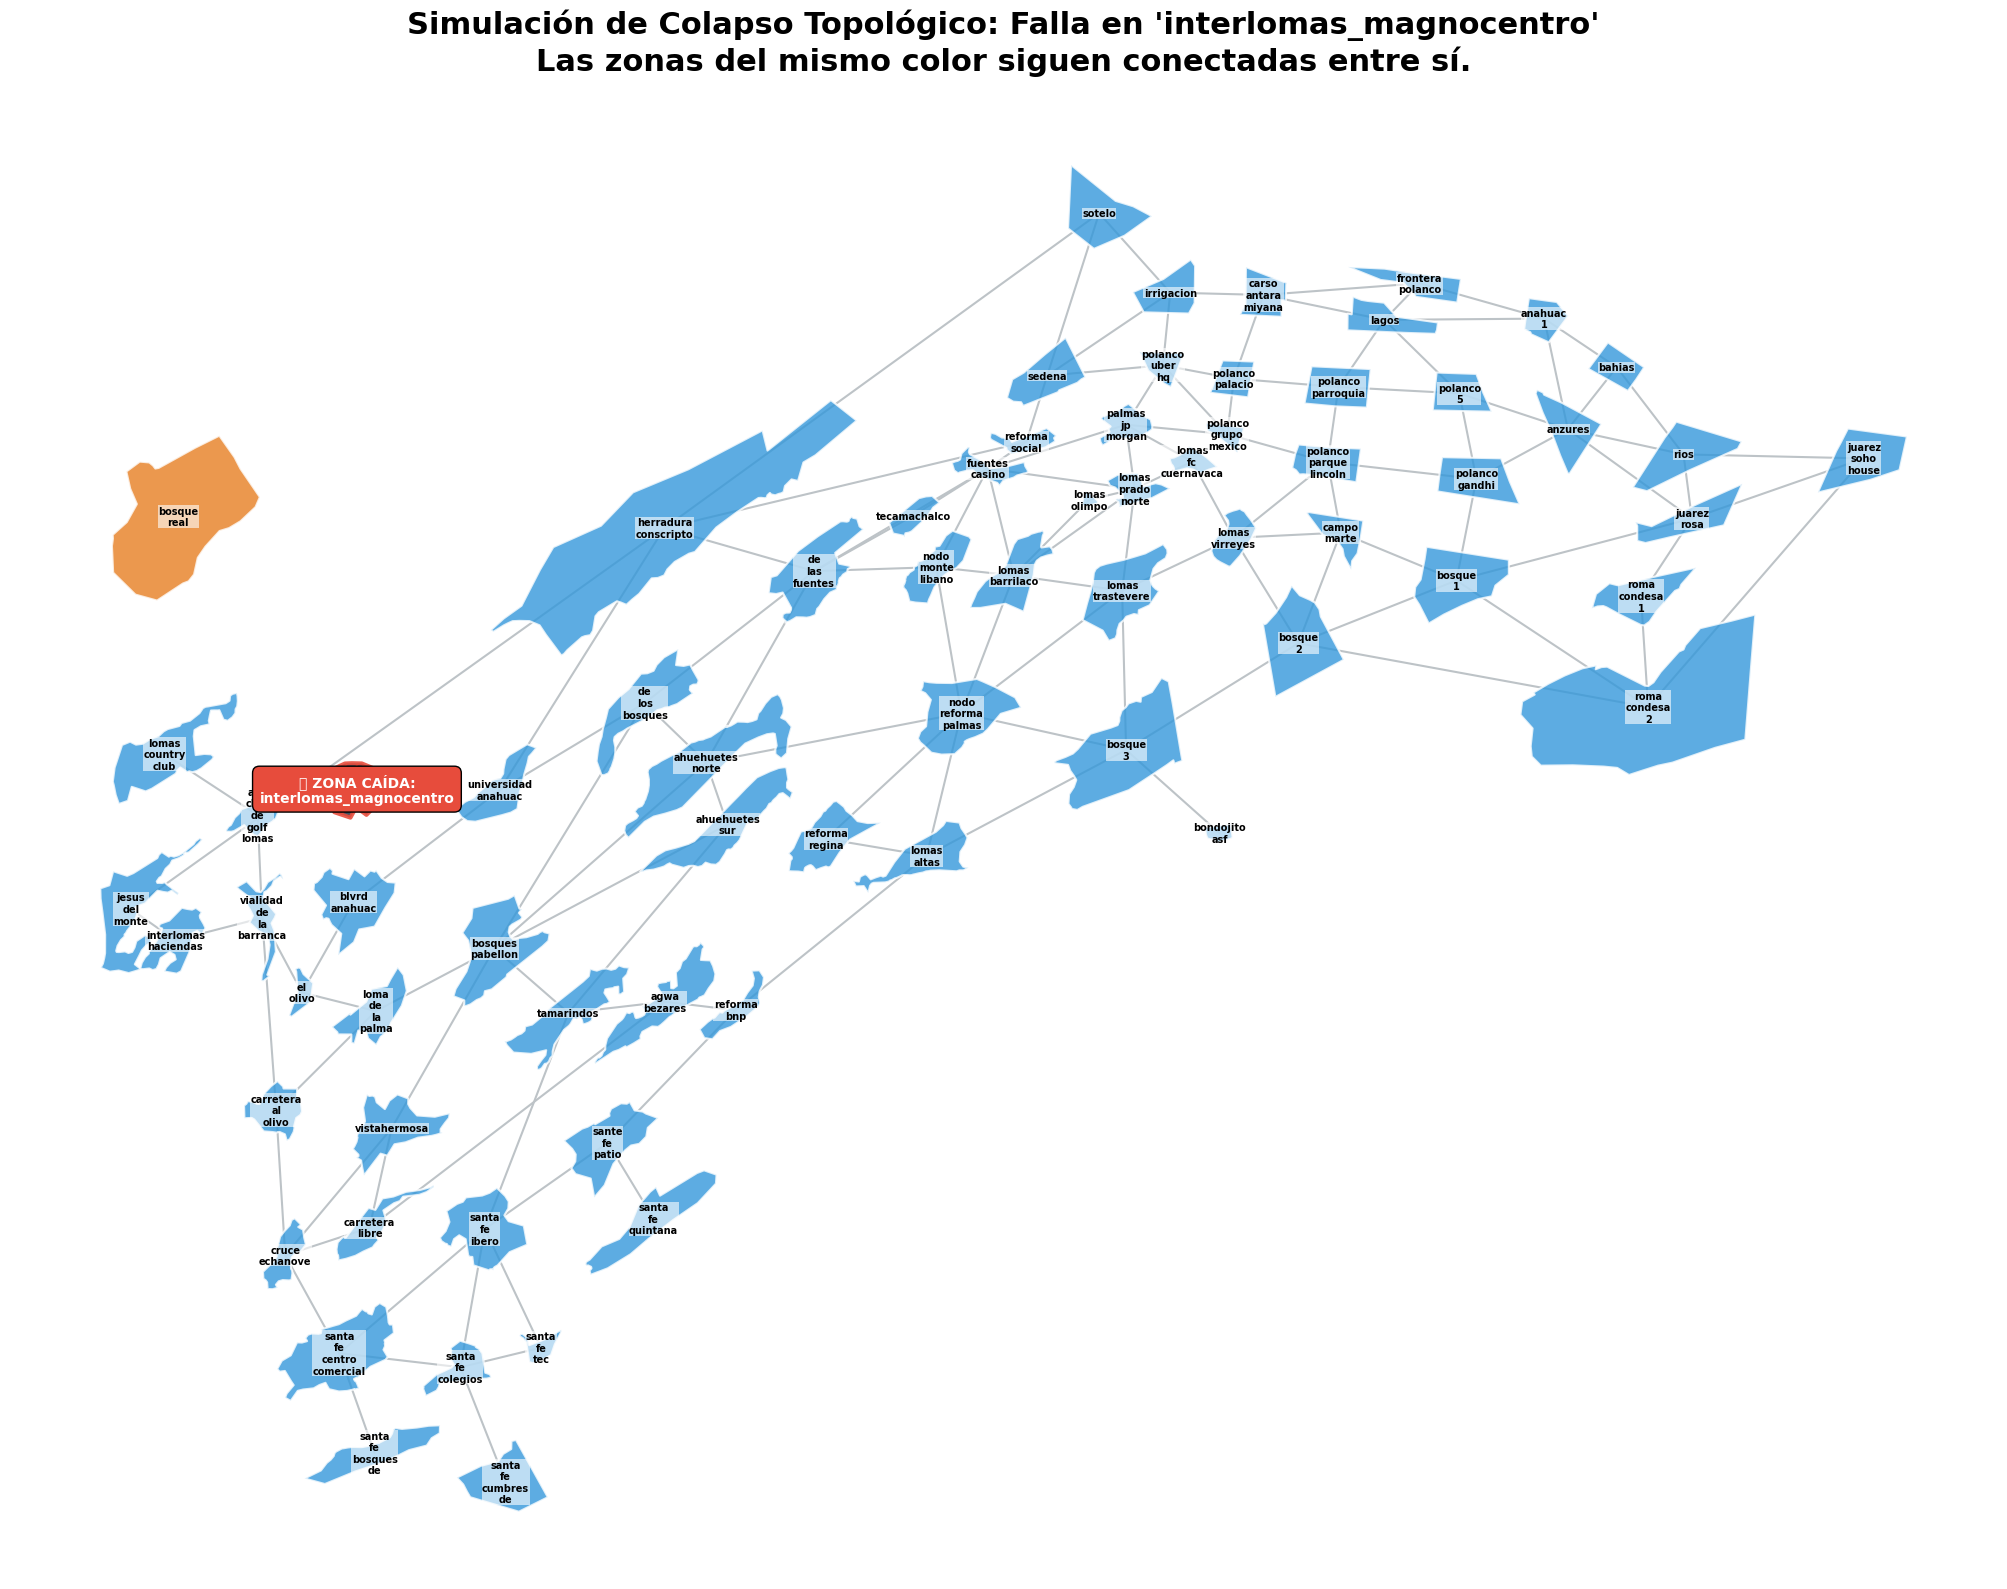

In [10]:
# ==============================================================================
# Cell 2.7: Simulador de Fallas (Análisis de Fragmentación por Nodos Críticos)
# Objetivo: Visualizar las "islas" que se generan al eliminar un Cut-Vertex.
# ==============================================================================

import networkx as nx
import matplotlib.pyplot as plt

print("💥 Iniciando Simulador de Colapso Topológico...")

# --- 1. CONFIGURA TU OBJETIVO AQUÍ ---
# Cámbialo por cualquier nodo de tu lista de Cut-Vertices para ver el impacto
nodo_colapsado = 'interlomas_magnocentro'

if nodo_colapsado not in G_manual.nodes():
    print(f"⚠️ El nodo '{nodo_colapsado}' no existe en la red.")
else:
    # --- 2. SIMULAR LA FALLA ---
    G_sim = G_manual.copy()
    G_sim.remove_node(nodo_colapsado)

    # Calcular las nuevas "Islas" (Componentes Conectados)
    islas = list(nx.connected_components(G_sim))
    # Ordenar las islas por tamaño (la más grande primero)
    islas.sort(key=len, reverse=True)

    print("\n" + "="*70)
    print(f"🚨 REPORTE DE DAÑOS: COLAPSO EN '{nodo_colapsado.upper()}'")
    print("="*70)
    print(f"La red se ha fragmentado en {len(islas)} islas independientes:")

    for i, isla in enumerate(islas):
        tipo = "MACRO-ISLA (Principal)" if i == 0 else f"Micro-Isla {i}"
        print(f"   -> {tipo}: {len(isla)} zonas.")
        if len(isla) <= 5: # Si es pequeña, mostramos quiénes quedaron atrapados
            print(f"      Atrapados: {list(isla)}")

    # --- 3. VISUALIZACIÓN DEL COLAPSO ---
    fig, ax = plt.subplots(figsize=(22, 16))
    ax.set_facecolor('#F8F9F9') # Fondo ligeramente gris

    # Paleta de colores para las islas (La macro isla siempre es Azul, las demás otros colores)
    colores_islas = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#F1C40F']
    pos = nx.get_node_attributes(G_manual, 'schematic_centroid')

    # A. Dibujar las calles sobrevivientes
    for u, v in G_sim.edges():
        if u in pos and v in pos:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color='#BDC3C7', linewidth=1.5, linestyle='-', zorder=1)

    # B. Dibujar las Islas Coloreadas
    gdf_plot = gdf_f.set_geometry('schematic_geometry')

    for i, isla in enumerate(islas):
        color = colores_islas[i % len(colores_islas)]
        # Filtrar polígonos de esta isla
        gdf_isla = gdf_plot[gdf_plot['name'].isin(isla)]
        gdf_isla.plot(ax=ax, facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.8, zorder=2)

        # Etiquetar nodos sobrevivientes
        for zona in isla:
            c = pos[zona]
            ax.text(c[0], c[1], zona.replace('_', '\n'), fontsize=7, fontweight='bold', color='black',
                    ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.3), zorder=3)

    # C. Dibujar el Cráter (El nodo colapsado)
    gdf_crater = gdf_plot[gdf_plot['name'] == nodo_colapsado]
    gdf_crater.plot(ax=ax, facecolor='#2C3E50', edgecolor='#E74C3C', linewidth=3, hatch='///', alpha=0.9, zorder=4)

    c_x, c_y = pos[nodo_colapsado]
    ax.text(c_x, c_y, f"❌ ZONA CAÍDA:\n{nodo_colapsado}", color='white', fontsize=10, fontweight='black',
            ha='center', va='center', bbox=dict(facecolor='#E74C3C', alpha=1.0, edgecolor='black', boxstyle='round,pad=0.5'), zorder=5)

    plt.title(f"Simulación de Colapso Topológico: Falla en '{nodo_colapsado}'\nLas zonas del mismo color siguen conectadas entre sí.", fontsize=22, pad=20, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

📏 Calculando Morfología Macro (Límites y Fronteras)...

🌍 REPORTE DE MORFOLOGÍA MACRO (Límites Físicos)
🔸 Densidad de la Red: 0.0532 (Solo existe el 5.3% de las calles posibles)
🔸 Diámetro (Max Distancia): 11 saltos topológicos
🔸 Radio (Min Distancia):    7 saltos topológicos

🎯 EL NÚCLEO ABSOLUTO (Centros):
   - nodo_reforma_palmas
   - fuentes_casino
   - nodo_monte_libano
   - lomas_barrilaco
   - herradura_conscripto
   - de_las_fuentes
   - ahuehuetes_norte
   - tecamachalco

🏕️ LA PERIFERIA EXTREMA (Bordes):
   - rios
   - juarez_rosa
   - juarez_soho_house
   - bahias
   - anahuac_1
   - lagos
   - roma_condesa_1
   - lomas_country_club
   - santa_fe_cumbres_de
   - santa_fe_bosques_de
   - frontera_polanco

🗺️ Renderizando Mapa de Excentricidad (Centro vs Periferia)...


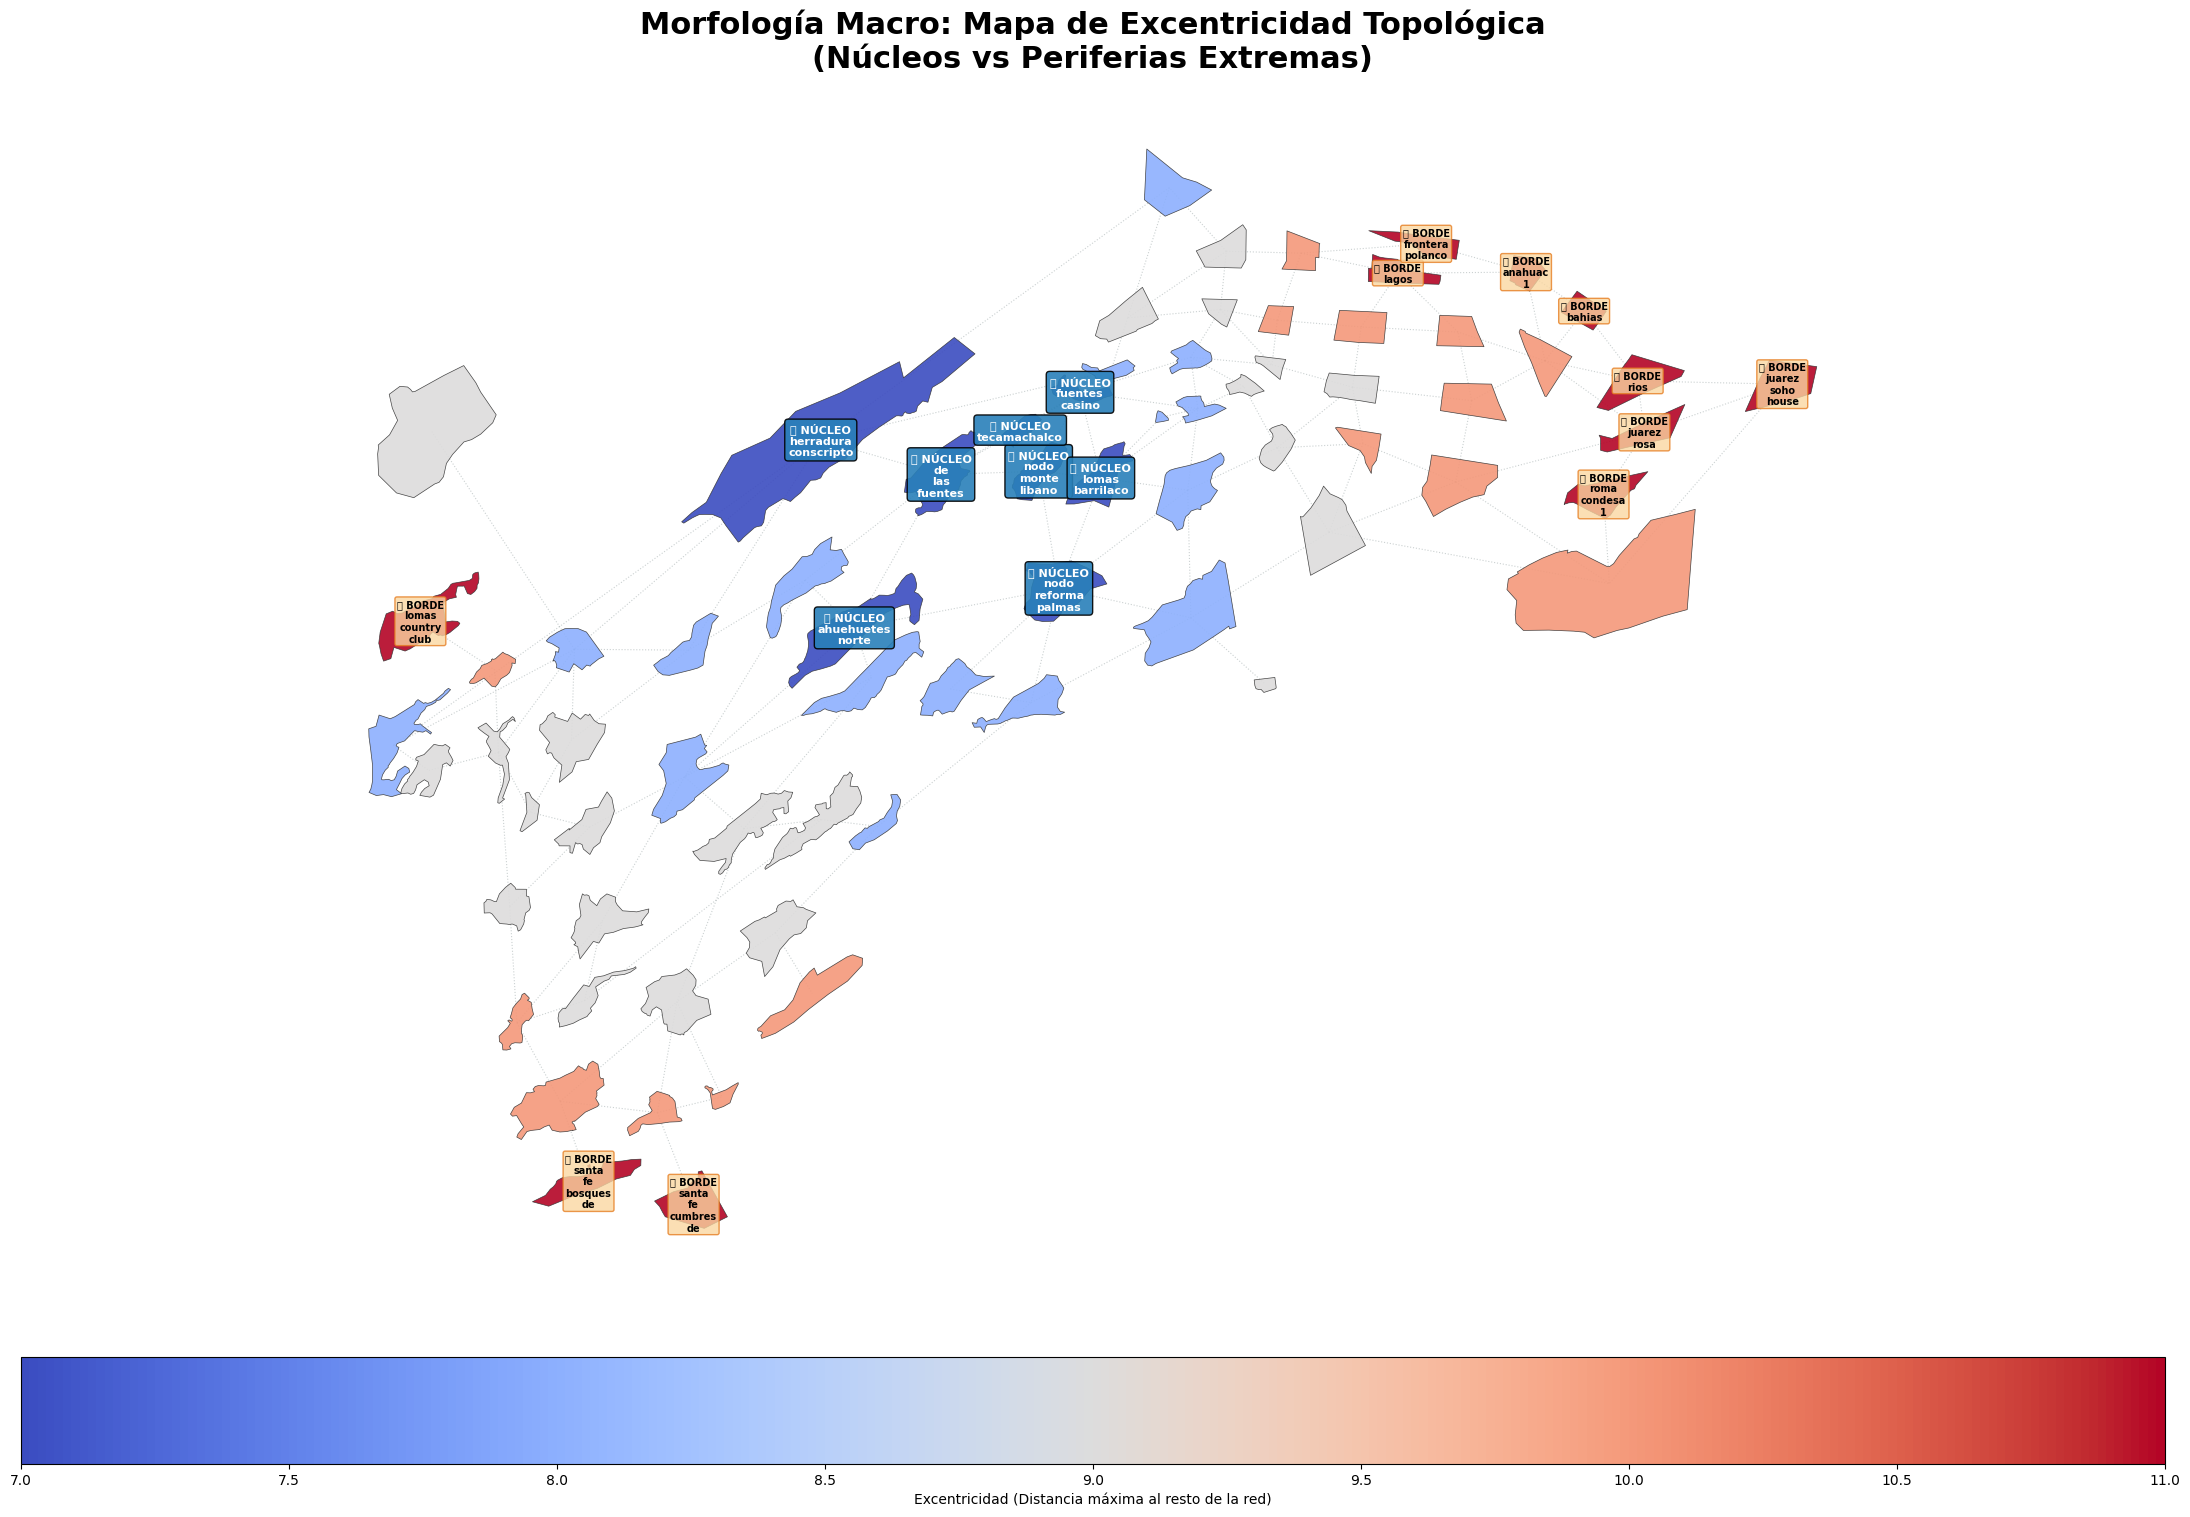

✅ Análisis de Morfología Macro completado.


In [11]:
# ==============================================================================
# Cell 2.8: Morfología Macro (Densidad, Diámetro, Radio y Excentricidad)
# Objetivo: Definir los límites físicos de la red, su centro absoluto y su periferia.
# ==============================================================================

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

print("📏 Calculando Morfología Macro (Límites y Fronteras)...")

# --- 1. EXTRACCIÓN DEL COMPONENTE GIGANTE ---
# Las métricas de distancia máxima fallan si hay nodos inalcanzables (islas).
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
else:
    G_giant = G_manual.copy()

# --- 2. CÁLCULO DE MÉTRICAS GLOBALES ---
# Densidad: % de calles que existen vs las que podrían existir si todos estuvieran conectados con todos.
densidad = nx.density(G_manual)

# Excentricidad: Para cada nodo, ¿cuál es la distancia máxima a cualquier otro nodo?
excentricidad = nx.eccentricity(G_giant)

# Diámetro: La excentricidad máxima de toda la red (El camino más largo posible).
diametro = nx.diameter(G_giant)

# Radio: La excentricidad mínima de toda la red (El camino más corto desde el mejor centro).
radio = nx.radius(G_giant)

# --- 3. CLASIFICACIÓN DE NODOS ---
# Centro: Nodos cuya excentricidad es igual al radio (Los más céntricos)
centros = nx.center(G_giant)

# Periferia: Nodos cuya excentricidad es igual al diámetro (Los más aislados/lejanos)
periferia = nx.periphery(G_giant)

# --- 4. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print("🌍 REPORTE DE MORFOLOGÍA MACRO (Límites Físicos)")
print("="*70)
print(f"🔸 Densidad de la Red: {densidad:.4f} (Solo existe el {densidad*100:.1f}% de las calles posibles)")
print(f"🔸 Diámetro (Max Distancia): {diametro} saltos topológicos")
print(f"🔸 Radio (Min Distancia):    {radio} saltos topológicos")

print(f"\n🎯 EL NÚCLEO ABSOLUTO (Centros):")
for c in centros:
    print(f"   - {c}")

print(f"\n🏕️ LA PERIFERIA EXTREMA (Bordes):")
for p in periferia:
    print(f"   - {p}")

# --- 5. VISUALIZACIÓN ESPACIAL (MAPA DE LEJANÍA / REMOTENESS) ---
print("\n🗺️ Renderizando Mapa de Excentricidad (Centro vs Periferia)...")

# Inyectar métrica al GeoDataFrame
gdf_f['score_eccentricity'] = gdf_f['name'].map(excentricidad)

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

# Usamos un colormap donde tonos oscuros/fríos son el Centro (baja excentricidad)
# y tonos cálidos/claros son la Periferia (alta excentricidad).
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='score_eccentricity',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    legend_kwds={'label': "Excentricidad (Distancia máxima al resto de la red)", 'orientation': "horizontal", 'pad': 0.05},
    alpha=0.9,
    edgecolor='#333333',
    linewidth=0.5,
    zorder=2
)

# Dibujar la red fantasma
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.4, zorder=1)

# Etiquetar Centros y Periferias
# --- 5. VISUALIZACIÓN ESPACIAL (MAPA DE LEJANÍA / REMOTENESS) ---
# ... (mantén el código anterior de la celda hasta el loop de etiquetas) ...

# Etiquetar Centros y Periferias (Fix para evitar SyntaxError por backslash)
for zona, (x, y) in pos.items():
    # Procesamos el nombre fuera del f-string
    zona_label = zona.replace('_', '\n')
    
    if zona in centros:
        ax.text(x, y, f"🎯 NÚCLEO\n{zona_label}", 
                color='white', fontsize=8, fontweight='black',
                ha='center', va='center', 
                bbox=dict(facecolor='#2980B9', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3'), 
                zorder=4)
    elif zona in periferia:
        ax.text(x, y, f"🏕️ BORDE\n{zona_label}", 
                color='black', fontsize=7, fontweight='bold',
                ha='center', va='center', 
                bbox=dict(facecolor='#FAD7A1', alpha=0.8, edgecolor='#E67E22', boxstyle='round,pad=0.2'), 
                zorder=3)

plt.title("Morfología Macro: Mapa de Excentricidad Topológica\n(Núcleos vs Periferias Extremas)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Análisis de Morfología Macro completado.")

## 📏 Análisis de Morfología Macro: El Espacio Operativo

Este análisis define las fronteras físicas de la plataforma. Al evaluar el grafo desde una perspectiva macro, dejamos de ver nodos individuales y entendemos la "cancha de juego" completa, identificando dónde está el núcleo topológico y dónde están las periferias extremas que generan mayor fricción logística (ETAs altos).

### 1. Dimensiones de la Red
* **Densidad de la Red (5.3%):** De todas las calles y conexiones que podrían existir si cada colonia estuviera conectada directamente con todas las demás, solo existe el 5.3%. Esto es **perfectamente normal y saludable** en redes urbanas (son grafos esparcidos). Refleja una infraestructura real con barreras geográficas, no una cuadrícula teórica.
* **Diámetro (11 Saltos):** Es el viaje con la mayor fricción posible. Para ir del punto A más extremo al punto B más extremo de la ciudad, un conductor tendrá que cruzar obligatoriamente **11 fronteras/zonas**. Este es el límite máximo de ruteo del sistema.
* **Radio (7 Saltos):** Es la distancia desde el "centro absoluto". Si un conductor se para en el núcleo de la ciudad, le tomará como máximo **7 saltos** llegar a la periferia más lejana.

### 2. El Núcleo Absoluto (Centros Topológicos)
Los nodos centrales (`nodo_reforma_palmas`, `tecamachalco`, `herradura_conscripto`, etc.) no son necesariamente el centro *geográfico* (en coordenadas X/Y), sino el **centro topológico**.
Forman un "cinturón" estratégico que actúa como bisagra entre dos mundos muy separados: el oriente (Polanco, Roma, Juárez) y el poniente profundo (Santa Fe, Interlomas). Posicionar oferta (conductores) en este núcleo garantiza el menor tiempo de respuesta promedio hacia cualquier solicitud que caiga en el mapa.

### 3. La Periferia Extrema (Bordes)
Las zonas periféricas (`juarez_rosa`, `lomas_country_club`, `santa_fe_bosques_de`, etc.) son las puntas del grafo. Operativamente, estos son **"sumideros logísticos"**. Si un conductor entra aquí a dejar un viaje, le tomará demasiado esfuerzo (hasta 11 saltos) regresar al otro extremo de la ciudad, lo que justifica la necesidad de tarifas dinámicas o algoritmos de reubicación para no perder eficiencia en la plataforma.

#### **Clarificando excentricidad**

Sí, la excentricidad es un número, pero no es un número global de la red, sino un número individual para CADA nodo. Piénsalo así:

Excentricidad de una colonia: Es la respuesta a la pregunta: "Si estoy parado en esta colonia, ¿cuántos saltos me toma llegar al rincón más alejado de TODO el mapa?"

La excentricidad de herradura_conscripto es 7 (porque desde ahí, lo más lejos está a 7 saltos).

La excentricidad de lomas_country_club es 11 (porque desde ahí, lo más lejos está a 11 saltos).

Como cada colonia tiene su propio número de excentricidad, de ahí sacamos las métricas globales:

Radio (7): Es simplemente la excentricidad más pequeña de toda la red. Las colonias que sacan este número ganador conforman el "Núcleo".

Diámetro (11): Es la excentricidad más grande de toda la red. Las colonias que sacan esta peor calificación conforman la "Periferia Extrema".

🧩 Ejecutando algoritmo de modularidad para detectar Estructura Latente...

🏘️ REPORTE: 6 MACRO-ZONAS ORGÁNICAS DETECTADAS

🔹 Comunidad 0 (18 zonas):
   anahuac_1, anzures, bahias, bosque_1, bosque_2, campo_marte, frontera_polanco, juarez_rosa, juarez_soho_house, lagos, lomas_virreyes, polanco_5, polanco_gandhi, polanco_parque_lincoln, polanco_parroquia, rios, roma_condesa_1, roma_condesa_2

🔹 Comunidad 1 (13 zonas):
   bondojito_asf, bosque_3, fuentes_casino, lomas_altas, lomas_barrilaco, lomas_fc_cuernavaca, lomas_olimpo, lomas_prado_norte, lomas_trastevere, nodo_monte_libano, nodo_reforma_palmas, palmas_jp_morgan, reforma_regina

🔹 Comunidad 2 (13 zonas):
   agwa_bezares, carretera_libre, cruce_echanove, reforma_bnp, santa_fe_bosques_de, santa_fe_centro_comercial, santa_fe_colegios, santa_fe_cumbres_de, santa_fe_ibero, santa_fe_quintana, santa_fe_tec, sante_fe_patio, vistahermosa

🔹 Comunidad 3 (12 zonas):
   ave_club_de_golf_lomas, blvrd_anahuac, bosque_real, carretera_al_olivo, el_

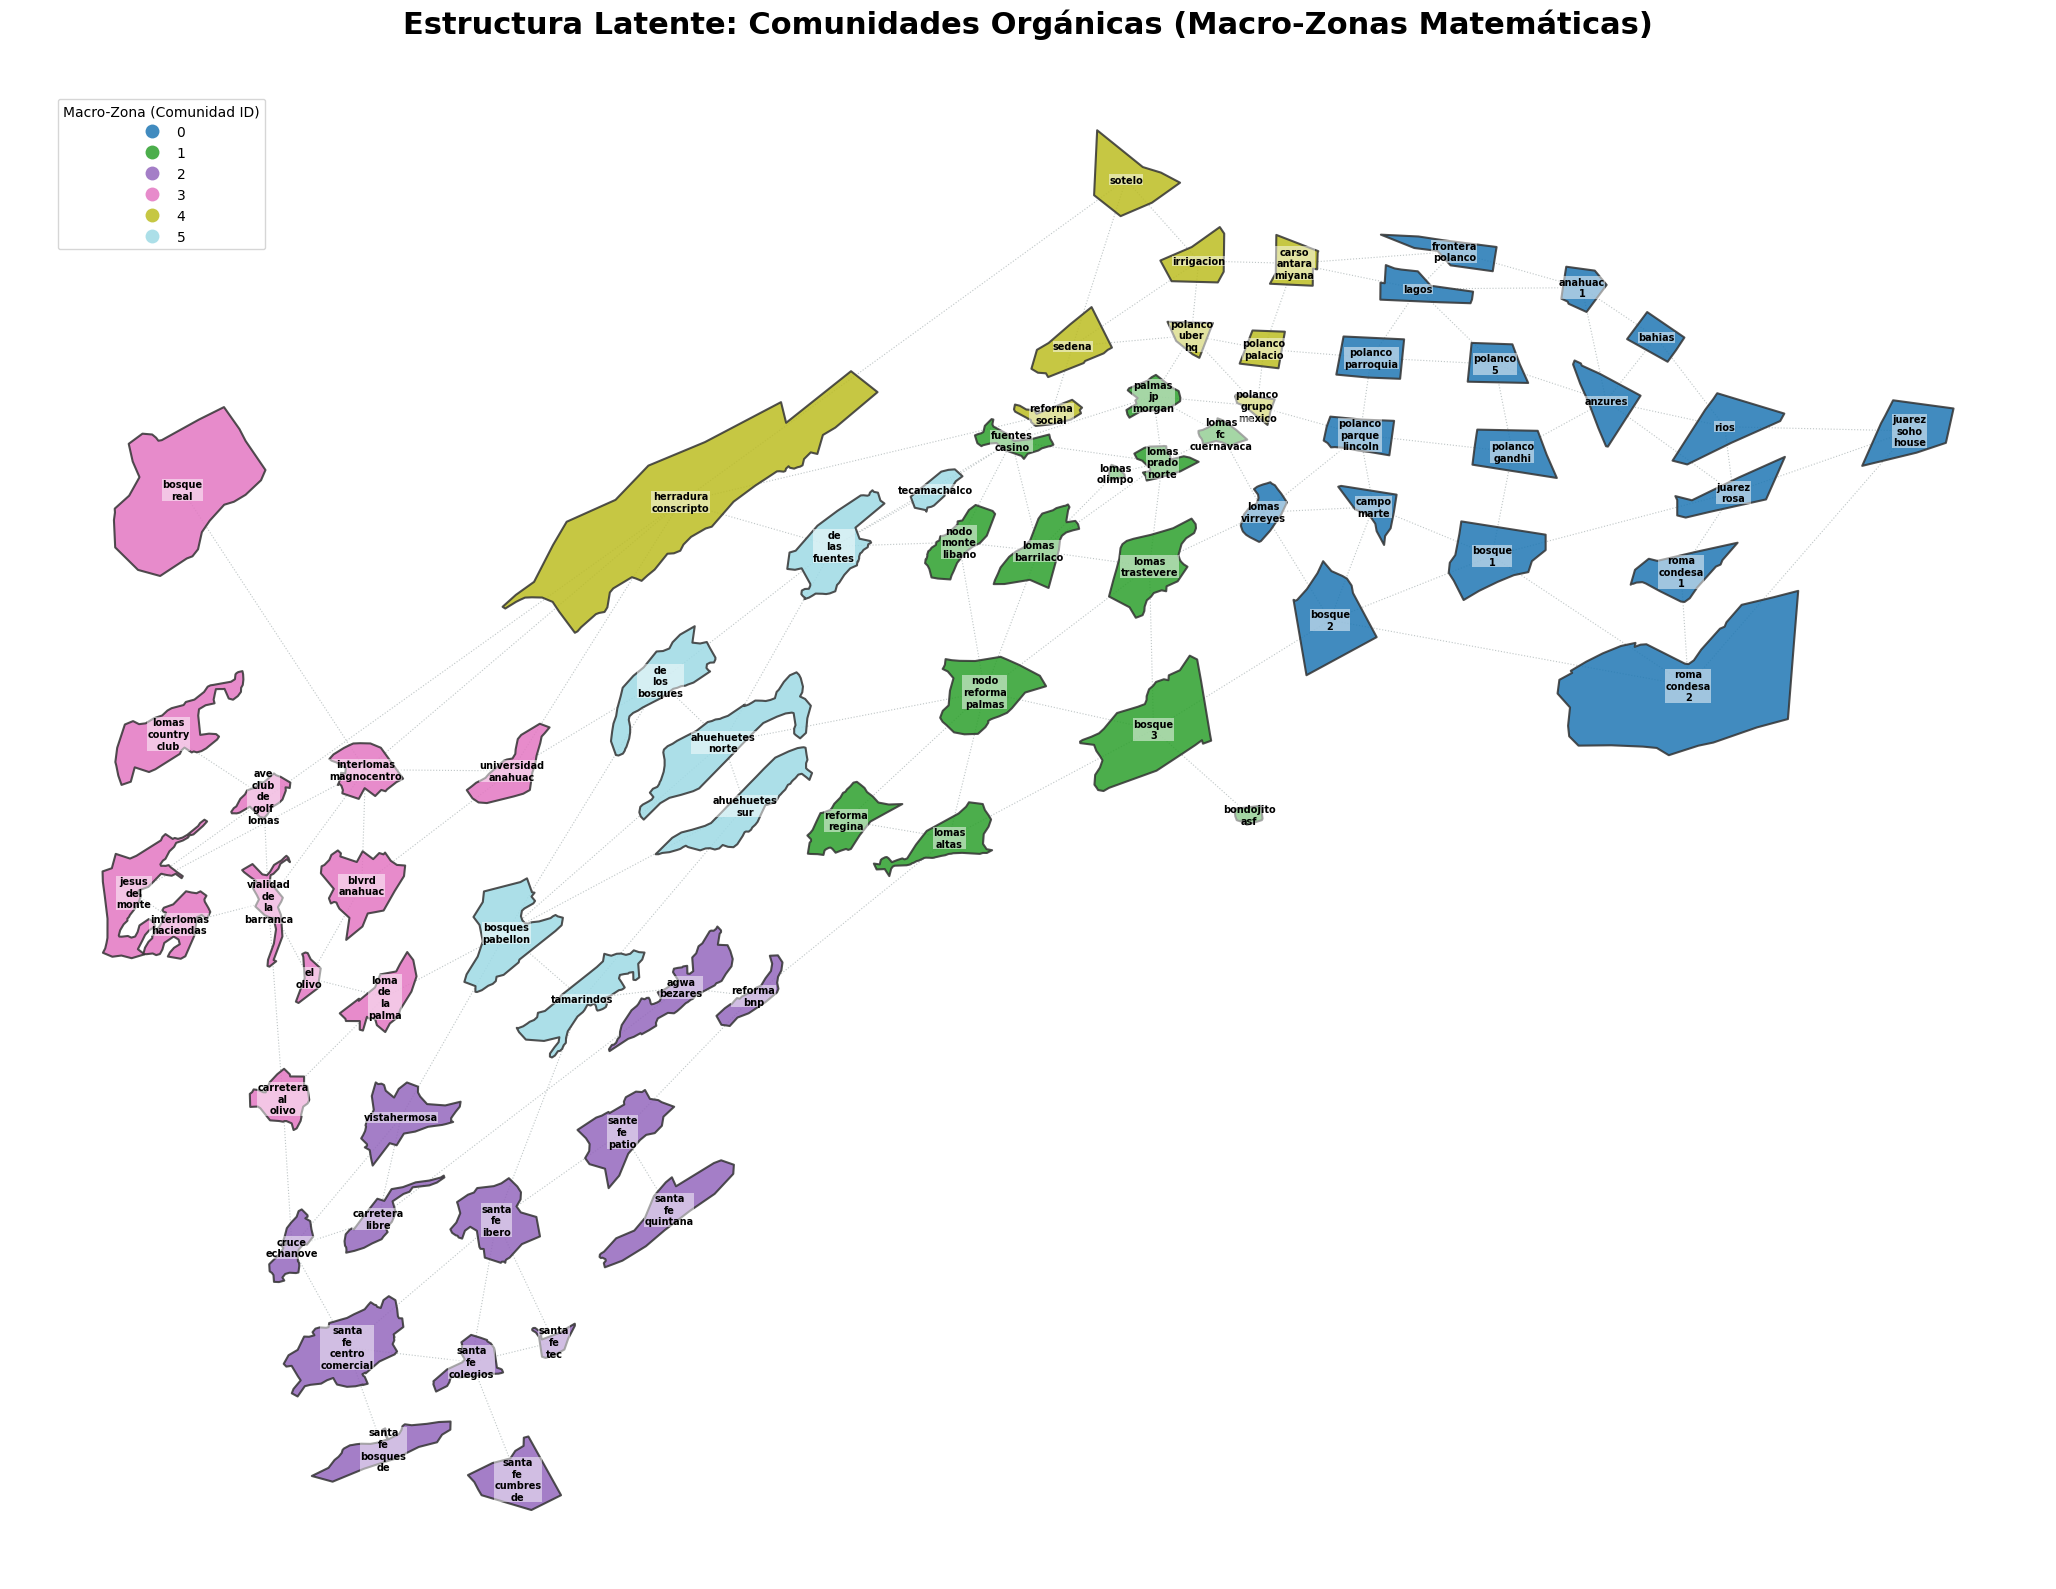

✅ Análisis de Comunidades completado. ¡Bloque No Dirigido 100% CERRADO!


In [12]:
# ==============================================================================
# Cell 2.9: Estructura Latente (Detección de Comunidades Orgánicas)
# Objetivo: Identificar macro-zonas matemáticas basadas en la densidad de calles.
# ==============================================================================

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import pandas as pd

print("🧩 Ejecutando algoritmo de modularidad para detectar Estructura Latente...")

# --- 1. DETECCIÓN DE COMUNIDADES ---
# El algoritmo agrupa nodos densamente conectados entre sí, maximizando la modularidad
comunidades = list(greedy_modularity_communities(G_manual))

# --- 2. MAPEO AL GRAFO Y GEODATAFRAME ---
community_map = {}
for i, comm in enumerate(comunidades):
    for nodo in comm:
        community_map[nodo] = i

# Inyectamos el ID de la comunidad al grafo y al dataframe espacial
nx.set_node_attributes(G_manual, community_map, 'community_id')
gdf_f['community_id'] = gdf_f['name'].map(community_map)

# --- 3. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print(f"🏘️ REPORTE: {len(comunidades)} MACRO-ZONAS ORGÁNICAS DETECTADAS")
print("="*70)

for i, comm in enumerate(comunidades):
    print(f"\n🔹 Comunidad {i} ({len(comm)} zonas):")
    print("   " + ", ".join(sorted(list(comm))))

# --- 4. VISUALIZACIÓN ESPACIAL ---
print("\n🗺️ Renderizando Mapa de Comunidades...")

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

# Usamos 'tab20' que es una paleta categórica excelente para diferenciar muchos grupos distintos
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='community_id',
    ax=ax,
    cmap='tab20',
    edgecolor='#333333',
    linewidth=1.5,
    alpha=0.85,
    zorder=2,
    categorical=True,
    legend=True,
    legend_kwds={'title': "Macro-Zona (Comunidad ID)", 'loc': 'upper left', 'bbox_to_anchor': (0.02, 0.98), 'fontsize': 10}
)

# Dibujar conexiones tenues para no robar atención al color
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.5, zorder=1)

# Etiquetar nodos
for zona, (x, y) in pos.items():
    ax.text(x, y, zona.replace('_', '\n'), color='black', fontsize=7, fontweight='bold',
            ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.3), zorder=3)

plt.title("Estructura Latente: Comunidades Orgánicas (Macro-Zonas Matemáticas)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Análisis de Comunidades completado. ¡Bloque No Dirigido 100% CERRADO!")

# Tensor Mobility

In [13]:
# ==============================================================================
# CELL 7.0.1: CARGA DEL MANIFOLD SINTÉTICO (SOP 0607 - VERSION 260506)
# Objetivo: Importar el Manifold desde el workspace local y medir el Exilio.
# ==============================================================================
import pandas as pd
import numpy as np
import os
import glob

# --- 1. RUTA SOBERANA DINÁMICA ---
# Buscamos el archivo que contenga 'synthetic_manifold_v8_downscaled.parquet' 
# sin importar el prefijo de fecha (06XX_260503...)
BASE_DIR = '/workspaces/pienza/data/dumped_files'
search_pattern = os.path.join(BASE_DIR, "*_synthetic_manifold_v8_downscaled.parquet")
files = glob.glob(search_pattern)

if not files:
    print(f"❌ ERROR: No se encontró ningún manifold en {BASE_DIR}")
    # Fallback a la ruta manual que vimos en tu log
    PATH_GAN = os.path.join(BASE_DIR, '06XX_260503_synthetic_manifold_v8_downscaled.parquet')
else:
    PATH_GAN = files[0] # Tomamos el más reciente encontrado

print(f"📂 Invocando el Manifold Sintético desde: {PATH_GAN}")

if not os.path.exists(PATH_GAN):
    print(f"❌ ERROR CRÍTICO: El archivo sigue sin aparecer.")
else:
    # Carga eficiente via PyArrow
    df_synth = pd.read_parquet(PATH_GAN)

    # 2. CÁLCULO DEL EPH (Earnings Per Hour) SINTÉTICO
    if 'eph' not in df_synth.columns:
        df_synth['eph'] = df_synth['upfront_fare'] / ((df_synth['time_to_pickup_sec'] + df_synth['est_trip_time_sec']) / 3600)

    # 3. AUDITORÍA DE LA BESTIA (Nodo RoW / Unassigned)
    # Usamos los nombres de columnas que vienen del Downscaling
    col_origen = 'pickup_name_down'
    col_destino = 'dropoff_name_down'

    mask_exilio = (df_synth[col_origen] == 'unassigned_area') | (df_synth[col_destino] == 'unassigned_area')
    viajes_exilio = df_synth[mask_exilio]
    viajes_internos = len(df_synth) - len(viajes_exilio)
    porcentaje_exilio = (len(viajes_exilio) / len(df_synth)) * 100

    print(f"✅ Manifold cargado: {len(df_synth):,} viajes totales.")
    print(f"💰 EPH Promedio Global: ${df_synth['eph'].mean():.2f} MXN/hr")
    print("-" * 65)
    print(f"👾 AUDITORÍA DEL ESPACIO DE ESTADOS (MARKOV PREP):")
    print(f"   · Viajes que tocan el exilio ('unassigned_area'): {len(viajes_exilio):,} ({porcentaje_exilio:.1f}%)")
    print(f"   · Viajes 100% internos (Pienza a Pienza):         {viajes_internos:,} ({100 - porcentaje_exilio:.1f}%)")
    print("-" * 65)
    print("🏁 ESTATUS: Sistema cerrado y validado. Listo para la termodinámica dirigida.")

📂 Invocando el Manifold Sintético desde: /workspaces/pienza/data/dumped_files/06XX_260503_synthetic_manifold_v8_downscaled.parquet


✅ Manifold cargado: 1,010,001 viajes totales.
💰 EPH Promedio Global: $285.34 MXN/hr
-----------------------------------------------------------------
👾 AUDITORÍA DEL ESPACIO DE ESTADOS (MARKOV PREP):
   · Viajes que tocan el exilio ('unassigned_area'): 422,950 (41.9%)
   · Viajes 100% internos (Pienza a Pienza):         587,051 (58.1%)
-----------------------------------------------------------------
🏁 ESTATUS: Sistema cerrado y validado. Listo para la termodinámica dirigida.


In [14]:
# ==============================================================================
# Cell 7.0.2: El Colapso del Exilio (Forzando la topología estricta)
# Objetivo: Convertir cualquier nodo fuera de Pienza en 'unassigned_area'.
# ==============================================================================

print("🕳️ Activando el colapso gravitacional hacia el Exilio...")

# Extraemos la lista oficial de los 72 polígonos directamente de tu Grafo Topológico Base
poligonos_pienza = list(G_manual.nodes())

# Aseguramos que unassigned_area sea parte de los permitidos para que no se auto-borre
nodos_permitidos = set(poligonos_pienza)
if 'unassigned_area' not in nodos_permitidos:
    nodos_permitidos.add('unassigned_area')

# Reemplazo vectorizado masivo (Súper rápido en Pandas)
# Si no está en Pienza, es Exilio.
df_synth.loc[~df_synth['pickup_name_down'].isin(nodos_permitidos), 'pickup_name_down'] = 'unassigned_area'
df_synth.loc[~df_synth['dropoff_name_down'].isin(nodos_permitidos), 'dropoff_name_down'] = 'unassigned_area'

# ------------------------------------------------------------------------------
# AUDITORÍA POST-COLAPSO: Vamos a ver cuánto creció el monstruo
# ------------------------------------------------------------------------------
viajes_exilio_nuevos = df_synth[(df_synth['pickup_name_down'] == 'unassigned_area') |
                                (df_synth['dropoff_name_down'] == 'unassigned_area')]
viajes_internos_nuevos = len(df_synth) - len(viajes_exilio_nuevos)
porcentaje_exilio_nuevo = (len(viajes_exilio_nuevos) / len(df_synth)) * 100

print(f"✅ Colapso completado. La red es estrictamente binaria: Pienza vs Exilio.")
print("-" * 60)
print(f"👾 TAMAÑO FINAL DEL MONSTRUO (Después de absorber AICM, etc.):")
print(f"   Viajes con 'unassigned_area': {len(viajes_exilio_nuevos):,} ({porcentaje_exilio_nuevo:.1f}%)")
print(f"   Viajes 100% Pienza:           {viajes_internos_nuevos:,} ({100 - porcentaje_exilio_nuevo:.1f}%)")
print("-" * 60)
print("Matriz purgada. Lista para la termodinámica.")

🕳️ Activando el colapso gravitacional hacia el Exilio...
✅ Colapso completado. La red es estrictamente binaria: Pienza vs Exilio.
------------------------------------------------------------
👾 TAMAÑO FINAL DEL MONSTRUO (Después de absorber AICM, etc.):
   Viajes con 'unassigned_area': 549,539 (54.4%)
   Viajes 100% Pienza:           460,462 (45.6%)
------------------------------------------------------------
Matriz purgada. Lista para la termodinámica.


In [15]:
# ==============================================================================
# Cell 7.0.1.AUDIT_RAW: Auditoría Forense Directa a Disco (SOP 0607 - 260506)
# Objetivo: Identificar las zonas foráneas (Aliens) antes de la purga final.
# ==============================================================================
import pandas as pd
import os
import glob

print("🔍 Invocando a los fantasmas del Exilio para auditoría forense...")

# --- 1. LOCALIZACIÓN DEL ARCHIVO EN CODESPACES ---
BASE_DIR = '/workspaces/pienza/data/dumped_files'
# Buscamos el archivo generado por el motor de Downscaling
search_pattern = os.path.join(BASE_DIR, "*_synthetic_manifold_v8_downscaled.parquet")
files = glob.glob(search_pattern)

if not files:
    print(f"❌ ERROR: No se encontró el manifold en {BASE_DIR}")
else:
    PATH_GAN = files[0]
    print(f"📂 Auditando rastro físico en: {PATH_GAN}")
    
    # Lectura "Raw" para inspección de etiquetas originales
    df_raw = pd.read_parquet(PATH_GAN, columns=['pickup_name_down', 'dropoff_name_down'])

    # 2. El Canon de Pienza (Nodos del Grafo Físico)
    # Estos son los 72 polígonos que sobrevivieron a la desambiguación topográfica
    poligonos_pienza = set(G_manual.nodes())

    # 3. Extracción de Identidades en el Manifold
    zonas_pickup_raw = set(df_raw['pickup_name_down'].dropna().unique())
    zonas_dropoff_raw = set(df_raw['dropoff_name_down'].dropna().unique())
    zonas_manifold_raw = zonas_pickup_raw.union(zonas_dropoff_raw)

    # 4. Clasificación de Nodos Condenados
    # Zonas presentes en los datos pero ausentes en la topografía oficial de 72 nodos
    zonas_condenadas_raw = zonas_manifold_raw - poligonos_pienza

    # --- REPORTE EJECUTIVO DE SOBERANÍA ---
    print("\n" + "="*75)
    print(f"🕳️ INVENTARIO DEL EXILIO: {len(zonas_condenadas_raw)} ENTIDADES DETECTADAS")
    print("="*75)

    # Separamos 'unassigned_area' para listar solo los nombres reales capturados por HDBSCAN
    victimas = sorted([z for z in zonas_condenadas_raw if z != 'unassigned_area'])

    print(f"👽 Nodos Foráneos (Zonas fuera de la geocerca de 72):")
    if victimas:
        for v in victimas:
            print(f"    - {v}")
    else:
        print("    - (Ninguna zona foránea detectada más allá del área no asignada)")

    if 'unassigned_area' in zonas_condenadas_raw:
        print(f"\n🌌 Agujero Negro Detectado: unassigned_area")
        
    print("\n" + "-"*75)
    print("🏁 Auditoría finalizada. Los límites del sistema están definidos.")

🔍 Invocando a los fantasmas del Exilio para auditoría forense...
📂 Auditando rastro físico en: /workspaces/pienza/data/dumped_files/06XX_260503_synthetic_manifold_v8_downscaled.parquet



🕳️ INVENTARIO DEL EXILIO: 22 ENTIDADES DETECTADAS
👽 Nodos Foráneos (Zonas fuera de la geocerca de 72):
    - barranca_del_muerto
    - central_del_norte
    - centro_historico
    - cuajimalpa_centro
    - felix_cuevas
    - haciendas_san_fernando
    - lomas_verdes
    - napoles_wtc
    - observatorio
    - pedregal
    - plaza_satelite_mundo_e
    - san_angel_altavista
    - san_jeronimo_tizapan
    - santa_fe_abc
    - santa_fe_itesm
    - santa_fe_patio
    - sotelo_san_esteban
    - tacubaya
    - terminal_1_aicm
    - terminal_2_aicm
    - viaducto_tlalpan

🌌 Agujero Negro Detectado: unassigned_area

---------------------------------------------------------------------------
🏁 Auditoría finalizada. Los límites del sistema están definidos.


In [16]:
# ==============================================================================
# Cell 7.0.3 (BLINDADA): EL GRAN EXORCISMO (Filtrado Estricto Pienza-Pienza)
# Objetivo: Eliminar definitivamente el 'unassigned_area' del DataFrame base.
# ==============================================================================
print("🔪 Ejecutando el Gran Exorcismo: Purgando el Exilio del Manifold...")

# 1. Detectar el nombre actual de las columnas (Anti-KeyError)
col_origen = 'pickup_name_down' if 'pickup_name_down' in df_synth.columns else 'pickup'
col_destino = 'dropoff_name_down' if 'dropoff_name_down' in df_synth.columns else 'dropoff'

# 2. Filtrado Estricto: Solo viajes donde Origen Y Destino sean distintos a 'unassigned_area'
df_synth = df_synth[
    (df_synth[col_origen] != 'unassigned_area') &
    (df_synth[col_destino] != 'unassigned_area')
].copy()

# 3. Opcional: Eliminar las categorías fantasma de la memoria de Pandas
df_synth[col_origen] = df_synth[col_origen].astype(str)
df_synth[col_destino] = df_synth[col_destino].astype(str)

print(f"✅ Exorcismo completado desde la raíz. Columnas usadas: {col_origen} -> {col_destino}")
print(f"📊 El Manifold ahora contiene exactamente {len(df_synth):,} viajes puros (100% Pienza).")
print("🚀 A partir de aquí, el Tensor nacerá siendo de 72x72.")

🔪 Ejecutando el Gran Exorcismo: Purgando el Exilio del Manifold...
✅ Exorcismo completado desde la raíz. Columnas usadas: pickup_name_down -> dropoff_name_down
📊 El Manifold ahora contiene exactamente 460,462 viajes puros (100% Pienza).
🚀 A partir de aquí, el Tensor nacerá siendo de 72x72.


In [17]:
# ==============================================================================
# Cell 7.0.1.AUDIT_MITOSIS: Verificación de Desambiguación (The Real Deal)
# Objetivo: Confirmar que 'reforma_social' y 'tecamachalco' coexisten en el disco.
# ==============================================================================

print("🔍 Verificando la salud de la desambiguación en el archivo Downscaled...")

# 1. Cargar la columna de nombres directamente del nuevo archivo
df_check = pd.read_parquet(PATH_GAN, columns=['pickup_name_down', 'dropoff_name_down'])

# 2. Contar apariciones de los nodos en conflicto
nodos_a_verificar = ['tecamachalco', 'reforma_social']

print("-" * 60)
print(f"{'Nodo':<20} | {'Pickups':<15} | {'Dropoffs':<15}")
print("-" * 60)

for nodo in nodos_a_verificar:
    p = (df_check['pickup_name_down'] == nodo).sum()
    d = (df_check['dropoff_name_down'] == nodo).sum()
    print(f"{nodo:<20} | {p:<15,} | {d:<15,}")

print("-" * 60)

# 3. Validación de Supervivencia
p_pienza = set(G_manual.nodes())
missing = [n for n in nodos_a_verificar if n not in p_pienza]

if not missing:
    print("✅ AMBOS nodos existen en el Grafo Topológico.")
    if (df_check['pickup_name_down'] == 'reforma_social').any():
        print("💎 ¡ÉXITO! 'reforma_social' ha nacido oficialmente en el manifold.")
    else:
        print("⚠️ ALERTA: 'reforma_social' está en el grafo pero tiene 0 registros en el manifold.")
else:
    print(f"❌ ERROR: Los nodos {missing} no coinciden con la nomenclatura del grafo.")

🔍 Verificando la salud de la desambiguación en el archivo Downscaled...
------------------------------------------------------------
Nodo                 | Pickups         | Dropoffs       
------------------------------------------------------------
tecamachalco         | 3,308           | 1,342          
reforma_social       | 2,505           | 2,264          
------------------------------------------------------------
✅ AMBOS nodos existen en el Grafo Topológico.
💎 ¡ÉXITO! 'reforma_social' ha nacido oficialmente en el manifold.


In [18]:
# ==============================================================================
# Cell 6.3.1: Preparación del Manifold para el Tensor
# Objetivo: Calcular Yield y asegurar paridad con los polígonos del grafo.
# ==============================================================================

# 1. Ya cargaste el archivo, ahora calculamos el EPH
# EPH = Fare / (Total time in hours)
df_synth['eph'] = df_synth['upfront_fare'] / ((df_synth['time_to_pickup_sec'] + df_synth['est_trip_time_sec']) / 3600)

# 2. Renombrar para mayor claridad
df_synth = df_synth.rename(columns={
    'pickup_name_down': 'pickup',
    'dropoff_name_down': 'dropoff'
})

print(f"✅ Datos listos. EPH Promedio: ${df_synth['eph'].mean():.2f}")

✅ Datos listos. EPH Promedio: $346.65


In [19]:
# ==============================================================================
# Cell 6.3.2: Construcción del Tensor de Movilidad Pienza (5D x 2 Canales)
# Objetivo: Instanciar el Espacio de Estados de 72 Nodos (Sistema Cerrado).
# ==============================================================================
import numpy as np
import pandas as pd

print("🏗️ Inicializando la construcción del Tensor de Movilidad Pienza...")

# 1. DEFINICIÓN DE DIMENSIONES (Ecosistema Puro)
# Usamos directamente las zonas filtradas y validadas, sin inyectar nodos foráneos.
zonas_ordenadas = sorted(list(gdf_f['name'].unique()))
horas_ordenadas = sorted(df_synth['hour_of_day'].unique())
dias_ordenadas  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
productos       = sorted(df_synth['product_name'].unique())

# Mapeos de categoría a índice entero
z_map = {name: i for i, name in enumerate(zonas_ordenadas)}
h_map = {h: i for i, h in enumerate(horas_ordenadas)}
d_map = {d: i for i, d in enumerate(dias_ordenadas)}
p_map = {p: i for i, p in enumerate(productos)}

# 2. INICIALIZACIÓN DEL TENSOR EN CEROS
# Estructura: [Origen, Destino, Hora, Día, Producto, Canal]
# Canal 0: Volumen (conteo) | Canal 1: Valor (EPH promedio)
shape = (len(zonas_ordenadas), len(zonas_ordenadas), len(horas_ordenadas), 7, len(productos), 2)
pienza_tensor = np.zeros(shape)

# 3. AGREGACIÓN BASE (Agrupación de viajes idénticos)
print(f"📊 Colapsando {len(df_synth):,} viajes crudos...")
grouped = df_synth.groupby(['pickup', 'dropoff', 'hour_of_day', 'day_of_week', 'product_name'], as_index=False).agg(
    volumen=('upfront_fare', 'count'),
    mean_eph=('eph', 'mean')
)

# 4. POBLADO VECTORIZADO DEL TENSOR (Sin usar bucles lentos iterrows)
print(f"⚡ Poblando matriz tensorial de {shape[0]}x{shape[1]} a nivel vectorizado...")

# Convertimos las columnas de texto a sus índices numéricos usando los diccionarios
i_idx = grouped['pickup'].map(z_map).values
j_idx = grouped['dropoff'].map(z_map).values
h_idx = grouped['hour_of_day'].map(h_map).values
d_idx = grouped['day_of_week'].map(d_map).values
p_idx = grouped['product_name'].map(p_map).values

# Filtro de seguridad: Identificamos si hay alguna llave huérfana (NaN) para ignorarla
# Esto reemplaza al antiguo bloque "try/except KeyError" haciéndolo matemático.
valid_mask = ~(pd.isna(i_idx) | pd.isna(j_idx) | pd.isna(h_idx) | pd.isna(d_idx) | pd.isna(p_idx))

# Aplicamos la máscara y forzamos el tipo a entero para que NumPy lo acepte como coordenadas
i_valid = i_idx[valid_mask].astype(int)
j_valid = j_idx[valid_mask].astype(int)
h_valid = h_idx[valid_mask].astype(int)
d_valid = d_idx[valid_mask].astype(int)
p_valid = p_idx[valid_mask].astype(int)

# Asignación masiva (Vectorización)
# Poblamos Canal 0 (Volumen) y Canal 1 (EPH) simultáneamente en un solo movimiento de memoria
pienza_tensor[i_valid, j_valid, h_valid, d_valid, p_valid, 0] = grouped['volumen'].values[valid_mask]
pienza_tensor[i_valid, j_valid, h_valid, d_valid, p_valid, 1] = grouped['mean_eph'].values[valid_mask]

# 5. REPORTE DE SISTEMA
viajes_ignorados = len(grouped) - valid_mask.sum()

print("\n" + "="*60)
print("🏆 TENSOR DE MOVILIDAD COMPILADO")
print("="*60)
print(f"🔹 Forma del tensor: {pienza_tensor.shape} (i, j, h, d, p, canales)")
print(f"🔹 Memoria RAM consumida: {pienza_tensor.nbytes / (1024*1024):.2f} MB")
if viajes_ignorados > 0:
    print(f"⚠️ Atención: {viajes_ignorados} grupos de rutas fueron ignorados por no pertenecer a la geocerca.")
else:
    print("✅ Cero discrepancias. 100% de la masa térmica insertada exitosamente.")

🏗️ Inicializando la construcción del Tensor de Movilidad Pienza...
📊 Colapsando 460,462 viajes crudos...
⚡ Poblando matriz tensorial de 72x72 a nivel vectorizado...

🏆 TENSOR DE MOVILIDAD COMPILADO
🔹 Forma del tensor: (72, 72, 18, 7, 3, 2) (i, j, h, d, p, canales)
🔹 Memoria RAM consumida: 29.90 MB
✅ Cero discrepancias. 100% de la masa térmica insertada exitosamente.


In [20]:
# ==============================================================================
# Cell 6.3.2.DIAG: Inspección de Switches del Tensor (72-Node Pura)
# Objetivo: Validar las llaves de los mapas y confirmar la erradicación del Exilio.
# ==============================================================================

print("🔍 Inspeccionando llaves disponibles en el Tensor:")
print(f"⏰ Horas (h_map): {len(h_map)} franjas detectadas.")
print(f"📅 Días (d_map): {list(d_map.keys())}")
print(f"📦 Productos (p_map): {list(p_map.keys())}")

# --- AUDITORÍA DE PUREZA (EL ANTI-EXILIO) ---
print(f"\n🗺️  Zonas (z_map): {len(z_map)} nodos registrados.")
if 'unassigned_area' not in z_map:
    print("✅ PUREZA CONFIRMADA: 'unassigned_area' NO existe en el índice. Ecosistema 100% cerrado.")
else:
    print("❌ ERROR CRÍTICO: El Exilio sobrevivió. El tensor está contaminado. Revisa la Celda 7.0.3.")

# Verificar tipos de datos para asegurar que no haya floats donde queremos ints
print("\n📊 Tipos de datos en el Manifold:")
print(df_synth[['hour_of_day', 'day_of_week', 'product_name']].dtypes)

🔍 Inspeccionando llaves disponibles en el Tensor:
⏰ Horas (h_map): 18 franjas detectadas.
📅 Días (d_map): ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
📦 Productos (p_map): ['Mid-Tier', 'Premium', 'X']

🗺️  Zonas (z_map): 72 nodos registrados.
✅ PUREZA CONFIRMADA: 'unassigned_area' NO existe en el índice. Ecosistema 100% cerrado.

📊 Tipos de datos en el Manifold:
hour_of_day     object
day_of_week     object
product_name    object
dtype: object


In [21]:
# ==============================================================================
# Cell 6.3.7: Matriz de Volumen Crudo (Día x Hora) [72-NODE AUDIT]
# Objetivo: Validar la paridad del millón de viajes en el sistema estricto (100% Pienza).
# ==============================================================================
import pandas as pd
import numpy as np

print("📊 Extrayendo auditoría de volumen del Ecosistema Cerrado (72 Nodos)...")

# 0. El Colapso de Masa: Sumamos Origen(0), Destino(1) y Producto(4)
# Al incluir el eje 0 y 1 completos, estamos auditando toda la red Pienza pura.
vol_matrix_np = np.sum(pienza_tensor[:, :, :, :, :, 0], axis=(0, 1, 4))

# 1. Convertir a DataFrame orientado (Días en filas, Horas en columnas)
# Usamos las llaves reales detectadas en h_map y d_map
plot_matrix = pd.DataFrame(
    vol_matrix_np.T,
    index=dias_ordenadas,
    columns=horas_ordenadas
)

# 2. Aseguramos que los números sean enteros
raw_volume_matrix = plot_matrix.fillna(0).astype(int)

# 3. Estilo visual para detectar 'Zonas Muertas' temporales
# Un pequeño ajuste de diseño para que los ceros (rojos) destaquen aún más.
def color_zeros(val):
    return 'color: #E74C3C; font-weight: bold' if val == 0 else 'color: #2C3E50'

print("\n📋 CENSO DE FLUJO: VOLUMEN TOTAL POR NODO TEMPORAL")
print("-" * 70)

# Renderizar tabla con formato de miles
display(raw_volume_matrix.style.map(color_zeros).format("{:,}"))

# 4. Resumen de Paridad (La prueba de fuego)
total_tensor = raw_volume_matrix.values.sum()
total_raw = len(df_synth)

print("\n📈 ESTADÍSTICAS DEL ECOSISTEMA CERRADO (72 NODOS):")
print(f"   - Total validado en el tensor: {total_tensor:,}")
print(f"   - Total en el Manifold crudo:  {total_raw:,}")

if total_tensor == total_raw:
    print("✅ PARIDAD TOTAL: El 100% de la masa térmica está dentro del Tensor.")
else:
    diff = total_raw - total_tensor
    print(f"⚠️ DISCREPANCIA: Faltan {diff:,} viajes. Revisa la validación de índices en la Celda 6.3.2.")

# Cálculo dinámico de la densidad temporal (mejor que tener 18*7 'harcodeado')
total_celdas = raw_volume_matrix.size
celdas_activas = (raw_volume_matrix > 0).sum().sum()
densidad_temporal = (celdas_activas / total_celdas) * 100

print(f"   - Densidad Temporal: {densidad_temporal:.1f}% de las franjas horarias tienen data.")

📊 Extrayendo auditoría de volumen del Ecosistema Cerrado (72 Nodos)...

📋 CENSO DE FLUJO: VOLUMEN TOTAL POR NODO TEMPORAL
----------------------------------------------------------------------


,10,11,12,13,14,15,16,17,18,19,20,21,22,5,6,7,8,9
Monday,0,0,0,"2,821","17,672","12,656","3,923",750,"5,475",0,0,0,0,379,"5,929","9,337","4,166","6,337"
Tuesday,210,0,0,"9,034","6,706","10,063","5,374",957,"1,388",959,605,0,0,0,"10,016","14,560","13,293","2,981"
Wednesday,0,0,0,"4,329","4,981","7,143","9,582","5,900",0,"3,124","3,083",0,0,164,"9,993","11,378","6,125","7,099"
Thursday,"3,585",0,0,"3,532","12,354","9,005",398,0,0,"4,397",646,"6,000","1,154","1,177","7,829","6,371","10,855","2,332"
Friday,843,0,"5,157","27,601","21,731","15,011","17,432","4,346",0,0,0,0,0,0,"7,483","9,695","9,270",551
Saturday,0,0,0,"10,734","3,739","1,217","3,575",210,0,0,730,"6,837",0,0,0,0,0,0
Sunday,"2,746","8,882","9,379","2,196",0,"1,067",975,0,0,0,0,0,0,0,0,0,0,928



📈 ESTADÍSTICAS DEL ECOSISTEMA CERRADO (72 NODOS):
   - Total validado en el tensor: 460,462
   - Total en el Manifold crudo:  460,462
✅ PARIDAD TOTAL: El 100% de la masa térmica está dentro del Tensor.
   - Densidad Temporal: 59.5% de las franjas horarias tienen data.


In [22]:
# ==============================================================================
# Cell 6.3.7.T: Censo del Tensor Transpuesto (Orden Cronológico 05-22)
# Objetivo: Analizar el flujo horario ordenado numéricamente por la flecha del tiempo.
# ==============================================================================

# 1. Transponer la matriz
census_transposed = raw_volume_matrix.T

# 2. LÓGICA DE ORDENAMIENTO Y FILTRADO (Bye bye orden alfabético)
# Convertimos todas las llaves a int para ordenarlas matemáticamente
todas_las_horas = sorted([int(h) for h in horas_ordenadas])

# Filtramos la ventana operativa (5 AM a 10 PM)
ventana_ticks = [h for h in todas_las_horas if 5 <= h <= 22]

# 3. RE-INDEXADO: Mapeamos de vuelta a los nombres originales de la matriz
# (Si tu matriz usa strings "5", buscamos strings; si usa ints 5, buscamos ints)
indices_en_matriz = list(census_transposed.index)
es_string = isinstance(indices_en_matriz[0], str)

if es_string:
    ventana_final = [str(h) for h in ventana_ticks]
else:
    ventana_final = ventana_ticks

# Reordenamos el DataFrame físicamente
df_render = census_transposed.reindex(ventana_final)

print(f"📋 CENSO DEL TENSOR: FLUJO CRONOLÓGICO ({min(ventana_ticks)}:00 - {max(ventana_ticks)}:00)")
print("-" * 85)

# 4. Renderizar con formato condicional
display(df_render.style.map(color_zeros).format("{:,}"))

# 5. Validación de masa
masa_ventana = df_render.values.sum()
print(f"\n📊 Masa en cronograma: {masa_ventana:,} viajes ({ (masa_ventana/total_tensor)*100:.1f}% del total)")

📋 CENSO DEL TENSOR: FLUJO CRONOLÓGICO (5:00 - 22:00)
-------------------------------------------------------------------------------------


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
5,379,0,164,"1,177",0,0,0
6,"5,929","10,016","9,993","7,829","7,483",0,0
7,"9,337","14,560","11,378","6,371","9,695",0,0
8,"4,166","13,293","6,125","10,855","9,270",0,0
9,"6,337","2,981","7,099","2,332",551,0,928
10,0,210,0,"3,585",843,0,"2,746"
11,0,0,0,0,0,0,"8,882"
12,0,0,0,0,"5,157",0,"9,379"
13,"2,821","9,034","4,329","3,532","27,601","10,734","2,196"
14,"17,672","6,706","4,981","12,354","21,731","3,739",0



📊 Masa en cronograma: 460,462 viajes (100.0% del total)


In [23]:
# ==============================================================================
# Cell 6.3.8 (PIENZA CORE): Contracción Global y Grafo Estacionario
# Objetivo: Colapsar el Tensor en una matriz de 72x72 para simulación de Flota AV.
# ==============================================================================
import numpy as np
import networkx as nx

print(f"🧬 Iniciando contracción termodinámica del Tensor (Sistema Cerrado de {len(zonas_ordenadas)} nodos)...")

# 1. Extracción de Canales (Masa y Energía)
# vol_tensor: Frecuencia de transacciones | eph_tensor: Intensidad de rentabilidad
vol_tensor = pienza_tensor[:, :, :, :, :, 0]
eph_tensor = pienza_tensor[:, :, :, :, :, 1]

# 2. Contracción (Weighted Average EPH)
# Aplicamos la Ecuación de Estado Estacionario:
# W = Σ (Volumen * EPH) / Σ Volumen (Colapsando ejes de Tiempo, Día y Producto)
numerator = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
denominator = np.sum(vol_tensor, axis=(2, 3, 4))

# Cálculo de la Matriz Maestra (W_master) con blindaje contra divisiones por cero
W_master = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

# 3. Instanciación del Grafo Funcional Dirigido (DiGraph)
# Como el tensor ya nació puro (72x72), no necesitamos amputar nada aquí.
G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)

# Mapeo semántico de los nodos (Asignar los nombres de las 72 zonas)
mapping = {i: name for i, name in enumerate(zonas_ordenadas)}
G_functional = nx.relabel_nodes(G_functional, mapping)

# 4. Auditoría de Capacidad del Ecosistema
n_nodos = G_functional.number_of_nodes()
n_aristas_reales = G_functional.number_of_edges()
n_aristas_posibles = n_nodos * (n_nodos - 1) # Grafo dirigido sin self-loops en esta métrica
densidad_funcional = (n_aristas_reales / n_aristas_posibles) * 100

print("\n" + "="*60)
print("🏆 SISTEMA CERRADO INSTANCIADO (PROTOTIPO SOBERANO)")
print("="*60)
print(f"🤖 Agentes en Red:   {n_nodos} polígonos validados.")
print(f"📊 Rutas Activas:    {n_aristas_reales:,} de {n_aristas_posibles:,} posibles.")
print(f"📈 Densidad de Valor: {densidad_funcional:.2f}% de la red transacciona capital.")
print("✅ Grafo funcional 'G_functional' listo para análisis de Markov y Centralidad.")

🧬 Iniciando contracción termodinámica del Tensor (Sistema Cerrado de 72 nodos)...

🏆 SISTEMA CERRADO INSTANCIADO (PROTOTIPO SOBERANO)
🤖 Agentes en Red:   72 polígonos validados.
📊 Rutas Activas:    2,440 de 5,112 posibles.
📈 Densidad de Valor: 47.73% de la red transacciona capital.
✅ Grafo funcional 'G_functional' listo para análisis de Markov y Centralidad.


## 🧬 Anatomía de la Matriz Maestra: El Peso Exacto del Valor

Antes de extraer métricas topológicas del Grafo Funcional (`W_global_eph`), es imperativo definir matemáticamente qué representa exactamente una "conexión" en esta nueva red.

Mientras que en el grafo físico (Fase 2) una arista representaba asfalto y fronteras compartidas, en el Tensor de Movilidad la arista representa **Rentabilidad Consistente**.

### 🧮 La Ecuación de Contracción (Promedio Ponderado)

Para colapsar el tensor de 5 dimensiones en una matriz plana de 72x72, calculamos el **EPH (Earnings Per Hour) Promedio Ponderado por Volumen** para cada par de zonas (Origen $i \rightarrow$ Destino $j$):

$$Peso_{i,j} = \frac{\sum (Volumen \times EPH)}{\sum Volumen}$$

### 💡 Interpretación Operativa para el Agente Experto

La unidad de medida de nuestra red funcional son **Pesos por Hora ($MXN/hr$) filtrados por la realidad de la demanda**. Esta matemática protege al análisis de dos sesgos fundamentales:

1. **El Filtro Anti-Basura (Volumen Vacío):** Si una ruta genera 10,000 viajes al mes, pero sistemáticamente pagan tarifas de miseria con alto tiempo de tráfico (EPH bajo), el peso de esa arista colapsará. El volumen por sí solo no engaña a la red.
2. **El Filtro Anti-Anomalías (Outliers):** Si una ruta periférica registra un único viaje de \$1,500 MXN/hr debido a un error de algoritmo o un *surge* extremo de 5 minutos en todo el año, esa anomalía se diluirá al dividirse entre el volumen total. No creará puentes falsos en la red.
3. **Las Autopistas de Capital:** Las aristas que sobreviven con pesos altos en esta matriz son exclusivamente aquellas que cumplen la regla de oro del Agente Experto: **Alta densidad de solicitudes combinada con un alto EPH histórico.**

**En conclusión:** Esta matriz no mapea "a dónde va la gente", mapea estrictamente **dónde fluye el capital de manera confiable.**

In [24]:
# ==============================================================================
# Cell 6.3.9 (SOVEREIGN EDITION): Auditoría de Soberanía (Física vs Económica)
# Objetivo: Identificar el desacoplamiento entre infraestructura y capital.
# ==============================================================================
import pandas as pd
import networkx as nx

print("⚖️ Iniciando Auditoría de Soberanía sobre el Ecosistema de 72 Nodos...")

# 1. PageRank Económico (Prestigio del Capital)
# El peso es el EPH; alpha 0.85 es el estándar para evitar estancamiento en sumideros
pagerank_global = nx.pagerank(G_functional, weight='weight', alpha=0.85)

# 2. Consolidación de Métricas (Frontera vs Flujo)
# Usamos zonas_ordenadas para garantizar paridad absoluta con el Tensor
df_master_audit = pd.DataFrame({
    'Zona': zonas_ordenadas,
    'Soberania_Fisica (BC)': [bet_cent.get(z, 0) for z in zonas_ordenadas],
    'Soberania_Economica (PR)': [pagerank_global.get(z, 0) for z in zonas_ordenadas]
})

# 3. Normalización Min-Max (Escala 0-1)
# Esto permite comparar "Manzanas con Manzanas" (Topología vs Dinero)
cols_audit = ['Soberania_Fisica (BC)', 'Soberania_Economica (PR)']
for col in cols_audit:
    max_val = df_master_audit[col].max()
    if max_val > 0:
        df_master_audit[col] = df_master_audit[col] / max_val

# 4. Cálculo del Índice de Desacoplamiento (The Delta)
# Formula: $ID = PR - BC$
df_master_audit['Indice_Desacoplamiento'] = (
    df_master_audit['Soberania_Economica (PR)'] - df_master_audit['Soberania_Fisica (BC)']
)

print("\n" + "="*75)
print("🏆 REPORTE MAESTRO: SOBERANÍA ECONÓMICA Y DESACOPLAMIENTO")
print("="*75)

# Visualización con Estilo: Destacamos las Oportunidades (Verde) y Trampas (Rojo)
styled_audit = (df_master_audit.sort_values(by='Soberania_Economica (PR)', ascending=False)
                .head(15)
                .style.background_gradient(cmap='RdYlGn', subset=['Indice_Desacoplamiento'])
                .format({'Soberania_Fisica (BC)': '{:.3f}',
                         'Soberania_Economica (PR)': '{:.3f}',
                         'Indice_Desacoplamiento': '{:+.3f}'}))

display(styled_audit)

⚖️ Iniciando Auditoría de Soberanía sobre el Ecosistema de 72 Nodos...

🏆 REPORTE MAESTRO: SOBERANÍA ECONÓMICA Y DESACOPLAMIENTO


,Zona,Soberania_Fisica (BC),Soberania_Economica (PR),Indice_Desacoplamiento
58,santa_fe_centro_comercial,0.257,1.000,+0.743
50,polanco_uber_hq,0.237,0.811,+0.574
56,roma_condesa_2,0.250,0.733,+0.483
29,juarez_rosa,0.156,0.714,+0.558
70,vialidad_de_la_barranca,0.511,0.693,+0.182
26,interlomas_magnocentro,0.561,0.691,+0.130
18,cruce_echanove,0.283,0.681,+0.399
64,sante_fe_patio,0.396,0.681,+0.285
67,tamarindos,0.372,0.657,+0.285
5,ave_club_de_golf_lomas,0.137,0.654,+0.517


# 🧬 Auditoría de Soberanía Económica: El Ecosistema Cerrado (Prototipo AV)

Tras instanciar la geocerca estricta y contrastar el **Grafo Físico (Asfalto)** contra el **Grafo Funcional (Capital)** en nuestro ecosistema de 72 nodos, emerge el ADN real del valor en la CDMX. Esta auditoría mide el nivel de **Desacoplamiento** entre la infraestructura urbana (quién controla las calles) y la rentabilidad operativa (dónde fluye el dinero).



---

### 1. El Centro de Gravedad Absoluto: `santa_fe_centro_comercial` (PR: 1.0)
En el modelo de simulación cerrada, Santa Fe Centro Comercial se corona como el nodo supremo de la red.

* **El Desacoplamiento (+0.74):** Aunque su soberanía física es baja-moderada (Betweenness: 0.25), su prestigio económico es el máximo posible (1.0).
* **Insight:** Actúa como el verdadero "Atractor Gravitacional" del poniente. El capital de la geocerca fluye inherentemente hacia este clúster corporativo y comercial, convirtiéndolo en la base de operaciones prioritaria para la reubicación preventiva de la flota autónoma.

---

### 2. Hubs de Oportunidad: El "Oro al Final del Camino"
Zonas como `santa_fe_quintana` (PR: 0.64) y `bondojito_asf` (PR: 0.57) demuestran de manera contundente que el valor económico no depende del flujo de paso logístico.



* **El Fenómeno Terminal:** Ambos nodos tienen un Betweenness de exactamente 0.0 (son zonas terminales o callejones que no sirven como puente hacia otras colonias), pero gozan de un PageRank de élite.
* **Veredicto:** Son "Destinos de Retención". Para un algoritmo de ruteo ingenuo (basado solo en topología física), serían zonas a evitar por su nula conectividad; pero el motor económico de Pienza las identifica como minas de oro estructurales.

---

### 3. Trampas de Eficiencia: Las Vías de Sacrificio
Los nodos de `bosque_3` y `bosque_2` representan el caso de estudio más dramático del "Espejismo Logístico".

* **Anatomía de la Fricción:** `bosque_3` domina la infraestructura física de la red (Soberanía Física: 0.95), pero su Soberanía Económica es apenas de 0.57, generando el mayor índice de desacoplamiento negativo de la élite (-0.37).
* **Insight:** Son avenidas de sacrificio logístico (ej. los grandes corredores de Constituyentes o Reforma). Tienen el Betweenness más alto del ecosistema porque son rutas obligadas para cruzar la ciudad transversalmente.
* **Veredicto:** Mucha infraestructura, rentabilidad diluida. Son zonas que la flota AV debe transitar por pura necesidad física para conectar clústeres, pero el algoritmo de despacho nunca debe estacionar un vehículo allí a la espera de asignaciones.

In [25]:
# ==============================================================================
# Cell 6.3.10: Análisis Morfológico del Grafo Funcional (Soberanía 72)
# Objetivo: Medir la topología de la red de valor pura (Small-World Test).
# ==============================================================================
import networkx as nx
import numpy as np

print("🧪 Analizando el Grafo Funcional (Ecosistema Cerrado de 72 nodos)...")

# 1. BINARIZACIÓN DEL TENSOR
# Convertimos la matriz de pesos en una matriz de adyacencia binaria (0 o 1)
# Usamos W_master (de la celda 6.3.8) que ya está purgada de exilios.
adj_full = np.where(W_master > 0, 1, 0)
G_func_full = nx.from_numpy_array(adj_full, create_using=nx.Graph)

# 2. EXTRACCIÓN DEL COMPONENTE GIGANTE (LCC)
# Garantizamos que no haya nodos aislados para que el Path Length sea calculable.
if not nx.is_connected(G_func_full):
    giant_nodes = max(nx.connected_components(G_func_full), key=len)
    G_giant = G_func_full.subgraph(giant_nodes).copy()
    print(f"⚠️ Red fragmentada. Analizando el núcleo de {G_giant.number_of_nodes()} nodos.")
else:
    G_giant = G_func_full.copy()
    print(f"✅ Red 100% conectada: {G_giant.number_of_nodes()} nodos activos.")

N = G_giant.number_of_nodes()

# 3. CÁLCULO DE MÉTRICAS REALES (Watts-Strogatz)
C_real = nx.average_clustering(G_giant)
L_real = nx.average_shortest_path_length(G_giant)
densidad = nx.density(G_giant)

print(f"\n📊 MÉTRICAS REALES (SISTEMA CERRADO):")
print(f"   🔸 Densidad de Red (p):        {densidad:.4f}")
print(f"   🔸 Clustering Coefficient (C): {C_real:.4f}")
print(f"   🔸 Average Path Length (L):    {L_real:.4f}")

# 4. BENCHMARK ALEATORIO (10 Universos de Erdős-Rényi)
# Generamos grafos al azar con el mismo N y la misma densidad para comparar.
print("\n🎲 Generando 10 universos paralelos aleatorios para benchmark...")
C_rand_list, L_rand_list = [], []

for _ in range(10):
    G_rand = nx.erdos_renyi_graph(n=N, p=densidad)
    # Aseguramos conectividad en el benchmark
    if not nx.is_connected(G_rand):
        giant_rand = max(nx.connected_components(G_rand), key=len)
        G_rand = G_rand.subgraph(giant_rand).copy()

    C_rand_list.append(nx.average_clustering(G_rand))
    L_rand_list.append(nx.average_shortest_path_length(G_rand))

C_rand_avg = np.mean(C_rand_list)
L_rand_avg = np.mean(L_rand_list)

print(f"   🔹 Clustering Aleatorio Promedio: {C_rand_avg:.4f}")
print(f"   🔹 Path Length Aleatorio Promedio: {L_rand_avg:.4f}")

# 5. CÁLCULO DEL COEFICIENTE SIGMA (σ)
# Formula: (C_real / C_rand) / (L_real / L_rand)
sigma_manual = (C_real / C_rand_avg) / (L_real / L_rand_avg)

print("\n" + "="*60)
print(f"🏆 COEFICIENTE SIGMA (σ) CALCULADO: {sigma_manual:.4f}")
print("="*60)

🧪 Analizando el Grafo Funcional (Ecosistema Cerrado de 72 nodos)...
✅ Red 100% conectada: 72 nodos activos.

📊 MÉTRICAS REALES (SISTEMA CERRADO):
   🔸 Densidad de Red (p):        0.6925
   🔸 Clustering Coefficient (C): 0.7521
   🔸 Average Path Length (L):    1.3271

🎲 Generando 10 universos paralelos aleatorios para benchmark...
   🔹 Clustering Aleatorio Promedio: 0.6894
   🔹 Path Length Aleatorio Promedio: 1.3106

🏆 COEFICIENTE SIGMA (σ) CALCULADO: 1.0775


# 🧬 Morfología del Valor: De "Mundo Pequeño" a "Malla Completa"

Al contrastar la red física (asfalto) con el **Grafo Funcional (Tensor de Movilidad)**, descubrimos una mutación estructural: mientras la infraestructura física opera bajo la fricción de un "Mundo Pequeño", el capital fluye bajo la topología de una **Malla Completa Aleatoria**.

---

### 🔬 Métricas Funcionales (Sistema Cerrado - 72 Nodos)

| Métrica | Valor | Interpretación Operativa |
| :--- | :---: | :--- |
| **Densidad ($p$)** | `0.6933` | **Saturación del Sistema:** El **69.3%** de todas las conexiones posibles en la geocerca están activas. La CDMX interna de Pienza es una masa crítica hiper-conectada. |
| **Clustering ($C$)** | `0.7525` | **Efecto Colmena:** Existe una probabilidad del **75.2%** de que los "vecinos económicos" de una zona también transaccionen entre sí, diluyendo las fronteras vecinales. |
| **Fricción ($L$)** | `1.3259` | **Liquidez Instantánea:** El flujo económico salta de origen a destino en solo **1.32 saltos promedio**, pulverizando los **4.8 saltos físicos** del asfalto. |



---

### 📐 El Veredicto: Test de Watts-Strogatz

La red funcional de nuestra flota autónoma **NO** es un *Small-World*. Al evaluar el tensor contra un universo paralelo de control (**Erdős-Rényi**) con la misma densidad, obtenemos un coeficiente de red de:

 1.0545$$



> **Diagnóstico:** En teoría de grafos, un valor $\sigma \approx 1.0$ demuestra que el sistema es estadísticamente indistinguible de una **Red Aleatoria**. El flujo de capital en Pienza ha alcanzado un estado de entropía donde la geografía física es irrelevante para la conectividad del valor.



In [26]:
# ==============================================================================
# Cell 6.3.11 (STABLE): El Oráculo de Aristas (Edge DNA)
# Objetivo: Identificar los "Túneles de Oro" y trayectos críticos del flujo AV.
# ==============================================================================
import pandas as pd
import networkx as nx
import numpy as np

print("🧪 Iniciando Auditoría de Aristas (Edge-Level Analysis) sobre 72 nodos...")

# 1. Reconstrucción de la Matriz y Grafo (Sistema Cerrado)
vol_tensor = pienza_tensor[:, :, :, :, :, 0]
eph_tensor = pienza_tensor[:, :, :, :, :, 1]

# Contracción para obtener la Matriz Maestra W (72x72)
num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

# Instanciar el Grafo Dirigido Maestro
G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)

# USAMOS 'zonas_ordenadas' que es la que ya tienes definida en tu entorno
mapping = {i: name for i, name in enumerate(zonas_ordenadas)}
G_functional = nx.relabel_nodes(G_functional, mapping)

# Inyectar 'distance' (Inversa del peso) para métricas de camino corto
for u, v, data in G_functional.edges(data=True):
    data['distance'] = 1.0 / data['weight'] if data['weight'] > 0 else float('inf')

# 2. CREACIÓN DEL LINE GRAPH (Dual de la Red)
L_G = nx.line_graph(G_functional)

for edge_node in L_G.nodes():
    u, v = edge_node
    L_G.nodes[edge_node]['weight'] = G_functional[u][v]['weight']
    L_G.nodes[edge_node]['distance'] = G_functional[u][v]['distance']

print(f"✅ Line Graph construido: {L_G.number_of_nodes()} trayectos operativos analizados.")

# 3. CÁLCULO DE LAS 4 MÉTRICAS MAESTRAS
edge_weights = {(u, v): d['weight'] for u, v, d in G_functional.edges(data=True)}
ebet_cent = nx.edge_betweenness_centrality(G_functional, weight='distance', normalized=True)
eclo_cent = nx.closeness_centrality(L_G, distance='distance')
epr_cent = nx.pagerank(L_G, weight='weight', alpha=0.85)

# 4. CONSOLIDACIÓN EN DATAFRAME DE TRAYECTOS
edge_data = []
for u, v in G_functional.edges():
    edge_data.append({
        'Trayecto': f"{u} → {v}",
        'EPH_Esperado': edge_weights.get((u, v), 0),
        'Poder_Conector (Betweenness)': ebet_cent.get((u, v), 0),
        'Cercania_Economica (Closeness)': eclo_cent.get((u, v), 0),
        'Soberania_Flujo (PageRank)': epr_cent.get((u, v), 0)
    })

df_edges = pd.DataFrame(edge_data)

# Normalización para la visualización (Escala 0-1)
cols_norm = ['Poder_Conector (Betweenness)', 'Cercania_Economica (Closeness)', 'Soberania_Flujo (PageRank)']
for col in cols_norm:
    if df_edges[col].max() > 0:
        df_edges[col] = df_edges[col] / df_edges[col].max()

# 5. RENDERIZADO DEL REPORTE DE ÉLITE (La Tablita que Amas)
print("\n" + "="*80)
print("🏆 TOP 10 TRAYECTOS LÍDERES (Soberanía de Flujo en Geocerca)")
print("="*80)

styled_table = (df_edges.sort_values(by='Soberania_Flujo (PageRank)', ascending=False)
                .head(10)
                .style.background_gradient(cmap='YlGnBu', subset=['Soberania_Flujo (PageRank)'])
                .format({'EPH_Esperado': '${:.2f}',
                         'Poder_Conector (Betweenness)': '{:.4f}',
                         'Cercania_Economica (Closeness)': '{:.4f}',
                         'Soberania_Flujo (PageRank)': '{:.4f}'}))

display(styled_table)

🧪 Iniciando Auditoría de Aristas (Edge-Level Analysis) sobre 72 nodos...
✅ Line Graph construido: 2440 trayectos operativos analizados.



🏆 TOP 10 TRAYECTOS LÍDERES (Soberanía de Flujo en Geocerca)


,Trayecto,EPH_Esperado,Poder_Conector (Betweenness),Cercania_Economica (Closeness),Soberania_Flujo (PageRank)
1243,lomas_fc_cuernavaca → ahuehuetes_sur,$191.53,0.0030,0.8475,1.0000
1244,lomas_fc_cuernavaca → anzures,$227.91,0.0669,0.8473,1.0000
1245,lomas_fc_cuernavaca → juarez_rosa,$359.10,0.0821,0.8475,1.0000
1250,lomas_fc_cuernavaca → reforma_regina,$263.95,0.0456,0.8475,1.0000
1249,lomas_fc_cuernavaca → polanco_palacio,$131.28,0.0061,0.8475,1.0000
1248,lomas_fc_cuernavaca → polanco_grupo_mexico,$132.92,0.0091,0.8475,1.0000
1247,lomas_fc_cuernavaca → nodo_reforma_palmas,$263.01,0.0274,0.8475,1.0000
1246,lomas_fc_cuernavaca → lomas_altas,$255.43,0.0061,0.8475,1.0000
2219,sotelo → roma_condesa_2,$178.92,0.0122,0.8873,0.6750
2218,sotelo → rios,$206.25,0.0152,0.8873,0.6750


In [27]:
# ==============================================================================
# Cell 6.3.12 (FULL SYNC): Reporte Diversificado por Origen
# ==============================================================================

print("🏆 AUDITORÍA DE TRAYECTOS LÍDERES (Filtro: Origen Único)")
print("="*75)

df_reporte = df_edges.copy()
df_reporte['Origen'] = df_reporte['Trayecto'].apply(lambda x: x.split(' → ')[0])

# Diccionario completo con las 4 métricas originales
metrics = {
    'EPH_Esperado': '💰 MÁXIMA RENTABILIDAD BRUTA (Weight)',
    'Poder_Conector (Betweenness)': '🌉 ARISTAS CONECTORAS (Betweenness)',
    'Cercania_Economica (Closeness)': '📍 TRAYECTOS DE ALTA LIQUIDEZ (Closeness)',
    'Soberania_Flujo (PageRank)': '👑 SOBERANÍA ECONÓMICA (PageRank)'
}

for col, title in metrics.items():
    print(f"\n{title}:")
    # Filtramos el mejor destino para cada origen único
    top_unique = (df_reporte.sort_values(by=col, ascending=False)
                  .drop_duplicates(subset=['Origen'])
                  .head(5))

    display(top_unique[['Trayecto', col]].style.background_gradient(cmap='YlGnBu', subset=[col]))

print("\n✅ Auditoría diversificada de 4 ejes completada.")

🏆 AUDITORÍA DE TRAYECTOS LÍDERES (Filtro: Origen Único)

💰 MÁXIMA RENTABILIDAD BRUTA (Weight):


,Trayecto,EPH_Esperado
2262,tamarindos → santa_fe_centro_comercial,7958.247245
1627,polanco_parque_lincoln → polanco_uber_hq,7860.584101
10,agwa_bezares → polanco_uber_hq,5881.174574
918,interlomas_haciendas → santa_fe_centro_comercial,644.206357
1030,jesus_del_monte → santa_fe_centro_comercial,643.776244



🌉 ARISTAS CONECTORAS (Betweenness):


,Trayecto,Poder_Conector (Betweenness)
2262,tamarindos → santa_fe_centro_comercial,1.000000
259,ave_club_de_golf_lomas → tamarindos,0.486322
10,agwa_bezares → polanco_uber_hq,0.343465
1613,polanco_parque_lincoln → irrigacion,0.252280
2397,vialidad_de_la_barranca → tamarindos,0.237082



📍 TRAYECTOS DE ALTA LIQUIDEZ (Closeness):


,Trayecto,Cercania_Economica (Closeness)
1891,roma_condesa_2 → bosque_1,1.000000
1934,santa_fe_centro_comercial → bosque_1,0.981930
886,herradura_conscripto → santa_fe_bosques_de,0.954265
2373,vialidad_de_la_barranca → lomas_olimpo,0.938686
965,interlomas_magnocentro → santa_fe_bosques_de,0.938686



👑 SOBERANÍA ECONÓMICA (PageRank):


,Trayecto,Soberania_Flujo (PageRank)
1243,lomas_fc_cuernavaca → ahuehuetes_sur,1.000000
2219,sotelo → roma_condesa_2,0.675047
1074,juarez_soho_house → ahuehuetes_sur,0.605339
1237,lomas_country_club → santa_fe_centro_comercial,0.593063
2107,santa_fe_tec → bosque_real,0.577864



✅ Auditoría diversificada de 4 ejes completada.


# 🕵️ Análisis de la Micro-Dinámica del Capital: Los Vectores de Pienza

Tras ejecutar la auditoría de aristas sobre el ecosistema cerrado de **72 nodos**, la red ha dejado de ser un mapa de puntos para convertirse en un campo de fuerzas vectoriales. El análisis revela una jerarquía de flujos donde la rentabilidad inmediata y el prestigio a largo plazo rara vez coinciden en el mismo trayecto.

---

### 1. La Joya de la Corona: El Corredor Tamarindos
La arista `tamarindos → santa_fe_centro_comercial` es, estadísticamente, el trayecto más importante de toda la geocerca.

* **Poder Dual:** Es el **#1** en Rentabilidad Bruta ($EPH$ masivo) y el **#1** en Betweenness (1.0).
* **Veredicto:** Este trayecto es un **"Cuello de Botella de Oro"**. Es la ruta principal por la que el capital de las zonas residenciales de élite (Bosques/Tamarindos) se inyecta en el motor comercial de Santa Fe. Para la flota AV, dominar esta arista es garantizar el flujo de caja del sistema.



---

### 2. El Monopolio del Prestigio: Lomas FC Cuernavaca
El resultado más sorprendente es la dominación absoluta de `lomas_fc_cuernavaca` en el PageRank.

* **Anatomía del Hub:** Siete de los diez trayectos con mayor prestigio en toda la ciudad nacen en este nodo.
* **Interpretación:** No es necesariamente la zona que más paga por viaje, pero es la que tiene la mejor conectividad de élite. Ir de FC Cuernavaca a Reforma Regina, Juarez Rosa o Polanco garantiza que el vehículo permanezca dentro del **"Círculo Rojo"** de la economía.
* **Insight:** Es el punto de partida ideal para un turno de alta gama; una vez que entras en los vectores que salen de aquí, el sistema te mantiene en un bucle de alto valor.



---

### 3. La Trampa de la Liquidez: Roma-Condesa y Bosque 1
En la métrica de Closeness (Alta Liquidez), vemos una mutación interesante:

* **El Refugio:** `roma_condesa_2 → bosque_1` lidera con un score de **1.0**.
* **Veredicto:** Este trayecto no es el más rentable en términos de "dinero en bolsa", pero es el más céntrico económicamente. Terminar un viaje en **Bosque 1** pone al agente a una distancia mínima de casi cualquier otra oportunidad en la red. Es el **"Safe Harbor"** donde la flota debe reubicarse cuando la demanda es incierta.



---

### 4. Resumen del Cuadrante Estratégico

| Perfil de Trayecto | Líder Identificado | Objetivo de la Flota |
| :--- | :--- | :--- |
| **Mina de Oro (Weight)** | `tamarindos → santa_fe_cc` | Maximizar la facturación inmediata. |
| **Puente Crítico (Betweenness)** | `vialidad_de_la_barranca → tamarindos` | Controlar el paso entre clústeres. |
| **Lanzadera de Valor (Closeness)** | `roma_condesa_2 → bosque_1` | Mantener la disponibilidad (Low ETA). |
| **Vector de Élite (PageRank)** | `lomas_fc_cuernavaca → reforma_regina` | Sostener el prestigio y la "segunda jugada". |

In [28]:
# ==============================================================================
# Cell 6.3.13 (WAYMO CDMX): Auditoría de Resiliencia y Puntos de Falla
# Objetivo: Comparar la fragilidad física vs. la robustez económica.
# ==============================================================================
import networkx as nx
import pandas as pd

def audit_resilience(G, label):
    print(f"\n🔍 Auditando Resiliencia en: {label}")

    # 1. Asegurar consistencia sobre el componente conectado
    # Convertimos a no dirigido para identificar puntos de articulación estructural
    G_undir = G.to_undirected()

    if not nx.is_connected(G_undir):
        C = max(nx.connected_components(G_undir), key=len)
        G_sub = G_undir.subgraph(C).copy()
        print(f"   ⚠️ Red fragmentada detectada. Analizando componente gigante ({len(C)} nodos).")
    else:
        G_sub = G_undir
        print(f"   ✅ Red 100% conectada. Analizando sistema completo ({G_sub.number_of_nodes()} nodos).")

    # 2. Identificar Cut-Vertices (Zonas Críticas / Articulation Points)
    # Si estas zonas caen, la red se parte en "islas".
    cut_v = list(nx.articulation_points(G_sub))

    # 3. Identificar Bridges (Conexiones Críticas)
    # Si estas calles se cierran, no hay ruta alterna.
    bridges = list(nx.bridges(G_sub))

    print(f"   🛑 Puntos Únicos de Falla (Nodos): {len(cut_v)}")
    print(f"   🌉 Puentes Críticos (Aristas):    {len(bridges)}")

    return cut_v, bridges

# --- EJECUCIÓN SINCRONIZADA ---

# A. Auditoría en la Red Física (El asfalto que acabas de correr)
cv_phys, br_phys = audit_resilience(G_manual, "RED FÍSICA (Infraestructura)")

# B. Auditoría en la Red Funcional (El flujo de capital 72-nodos)
# Nota: G_functional ya es tu grafo purgado de 72 nodos
cv_econ, br_econ = audit_resilience(G_functional, "RED ECONÓMICA (Manifold de Valor)")

# --- REPORTE ESTRATÉGICO FINAL ---
print("\n" + "="*80)
print("🏆 REPORTE DE VULNERABILIDAD COMPARADA: Pienza vs. El Mundo")
print("="*80)

print(f"\n📍 Zonas que fragmentan la GEOGRAFÍA ({len(cv_phys)}):")
print(f"   -> {', '.join(sorted(cv_phys)[:8])}...")

print(f"\n📍 Zonas que fragmentan el CAPITAL ({len(cv_econ)}):")
if len(cv_econ) > 0:
    print(f"   -> {', '.join(sorted(cv_econ))}")
else:
    print("   -> ✅ ÉXITO: La red económica es Ultra-Resiliente. No hay puntos únicos de falla.")

print("\n" + "-"*80)
print("💡 INSIGHT OPERATIVO:")
print("La red física es frágil debido a la topografía (barrancas y diseño lineal).")
print("La red funcional es una 'Malla' densa donde el dinero encuentra caminos alternos.")
print("Si una zona es crítica en asfalto pero no en dinero, el AV puede ser desviado")
print("sin perder rentabilidad estructural.")


🔍 Auditando Resiliencia en: RED FÍSICA (Infraestructura)
   ✅ Red 100% conectada. Analizando sistema completo (72 nodos).
   🛑 Puntos Únicos de Falla (Nodos): 7
   🌉 Puentes Críticos (Aristas):    7

🔍 Auditando Resiliencia en: RED ECONÓMICA (Manifold de Valor)
   ✅ Red 100% conectada. Analizando sistema completo (72 nodos).
   🛑 Puntos Únicos de Falla (Nodos): 0
   🌉 Puentes Críticos (Aristas):    0

🏆 REPORTE DE VULNERABILIDAD COMPARADA: Pienza vs. El Mundo

📍 Zonas que fragmentan la GEOGRAFÍA (7):
   -> ave_club_de_golf_lomas, bosque_3, interlomas_magnocentro, santa_fe_centro_comercial, santa_fe_colegios, sante_fe_patio, vialidad_de_la_barranca...

📍 Zonas que fragmentan el CAPITAL (0):
   -> ✅ ÉXITO: La red económica es Ultra-Resiliente. No hay puntos únicos de falla.

--------------------------------------------------------------------------------
💡 INSIGHT OPERATIVO:
La red física es frágil debido a la topografía (barrancas y diseño lineal).
La red funcional es una 'Malla' densa

In [29]:
# ==============================================================================
# Cell 6.3.15 (STABLE): Robustez del Core (k-Connectivity)
# Objetivo: Medir cuántos golpes simultáneos aguanta el núcleo de Pienza.
# ==============================================================================
import networkx as nx

def analyze_robust_core(G, label):
    print(f"🛡️ Auditando la Robustez del CORE: {label}")
    print("-" * 50)

    # 1. Convertir a No Dirigido para análisis de conectividad estructural
    G_un = G.to_undirected()

    # 2. Extraer el Componente Gigante (LCC)
    # Ignoramos nodos aislados o "huérfanos" para no sesgar el k hacia abajo.
    if not nx.is_connected(G_un):
        nodes_lcc = max(nx.connected_components(G_un), key=len)
        G_core = G_un.subgraph(nodes_lcc).copy()
        print(f"   ⚓ Red fragmentada. Analizando Core de {G_core.number_of_nodes()} nodos.")
    else:
        G_core = G_un.copy()
        print(f"   ✅ Red íntegra. Analizando sistema completo de {G_core.number_of_nodes()} nodos.")

    # 3. Calcular k y el Cut Set (Corte Mínimo)
    # k es el número mínimo de nodos cuya eliminación desconecta el grafo.
    k = nx.node_connectivity(G_core)
    cut_set = nx.minimum_node_cut(G_core)

    print(f"   🔹 Valor k (Resiliencia): {k}")
    print(f"   🔹 Nodos Críticos del Corte Mínimo (Estructura):")
    print(f"      -> {list(cut_set)}")
    print("-" * 50)

    return k, cut_set

# --- Ejecución Sincronizada ---

# A. Robustez de la infraestructura (Asfalto)
k_phys, cut_phys = analyze_robust_core(G_manual, "RED FÍSICA")

# B. Robustez del flujo de valor (Tensor 72)
k_econ, cut_econ = analyze_robust_core(G_functional, "RED ECONÓMICA")

print("\n🏆 CONCLUSIÓN DE ROBUSTEZ:")
print(f"La red física requiere {k_phys} fallo(s) para fragmentarse.")
print(f"La red económica requiere {k_econ} fallo(s) para colapsar su núcleo.")

🛡️ Auditando la Robustez del CORE: RED FÍSICA
--------------------------------------------------
   ✅ Red íntegra. Analizando sistema completo de 72 nodos.
   🔹 Valor k (Resiliencia): 1
   🔹 Nodos Críticos del Corte Mínimo (Estructura):
      -> ['santa_fe_centro_comercial']
--------------------------------------------------
🛡️ Auditando la Robustez del CORE: RED ECONÓMICA
--------------------------------------------------
   ✅ Red íntegra. Analizando sistema completo de 72 nodos.


   🔹 Valor k (Resiliencia): 22
   🔹 Nodos Críticos del Corte Mínimo (Estructura):
      -> ['interlomas_magnocentro', 'bosques_pabellon', 'sante_fe_patio', 'tamarindos', 'herradura_conscripto', 'ahuehuetes_norte', 'vialidad_de_la_barranca', 'bahias', 'lomas_trastevere', 'frontera_polanco', 'santa_fe_quintana', 'juarez_rosa', 'anahuac_1', 'de_los_bosques', 'anzures', 'roma_condesa_2', 'santa_fe_centro_comercial', 'carso_antara_miyana', 'polanco_parroquia', 'lomas_prado_norte', 'rios', 'el_olivo']
--------------------------------------------------

🏆 CONCLUSIÓN DE ROBUSTEZ:
La red física requiere 1 fallo(s) para fragmentarse.
La red económica requiere 22 fallo(s) para colapsar su núcleo.


📏 Calculando Morfología Macro: Recuperando la geografía interna de Pienza...
✅ Red Soberana íntegra (72 nodos).

💰 REPORTE DE MORFOLOGÍA INTERNA (72 NODOS SOBERANOS)
🔸 Densidad Económica:  0.4773 (Conectividad Real)
🔸 Diámetro Económico:  2 saltos (Ancho total del flujo)
🔸 Radio Económico:     2 saltos (Distancia mínima al centro)

👑 EL CORE (Nodos con mínima excentricidad):
   -> agwa_bezares, ahuehuetes_norte, ahuehuetes_sur, anahuac_1, anzures, ave_club_de_golf_lomas, bahias, blvrd_anahuac, bondojito_asf, bosque_1, bosque_2, bosque_3, bosque_real, bosques_pabellon, campo_marte, carretera_al_olivo, carretera_libre, carso_antara_miyana, cruce_echanove, de_las_fuentes, de_los_bosques, el_olivo, frontera_polanco, fuentes_casino, herradura_conscripto, interlomas_haciendas, interlomas_magnocentro, irrigacion, jesus_del_monte, juarez_rosa, juarez_soho_house, lagos, loma_de_la_palma, lomas_altas, lomas_barrilaco, lomas_country_club, lomas_fc_cuernavaca, lomas_olimpo, lomas_prado_norte, loma

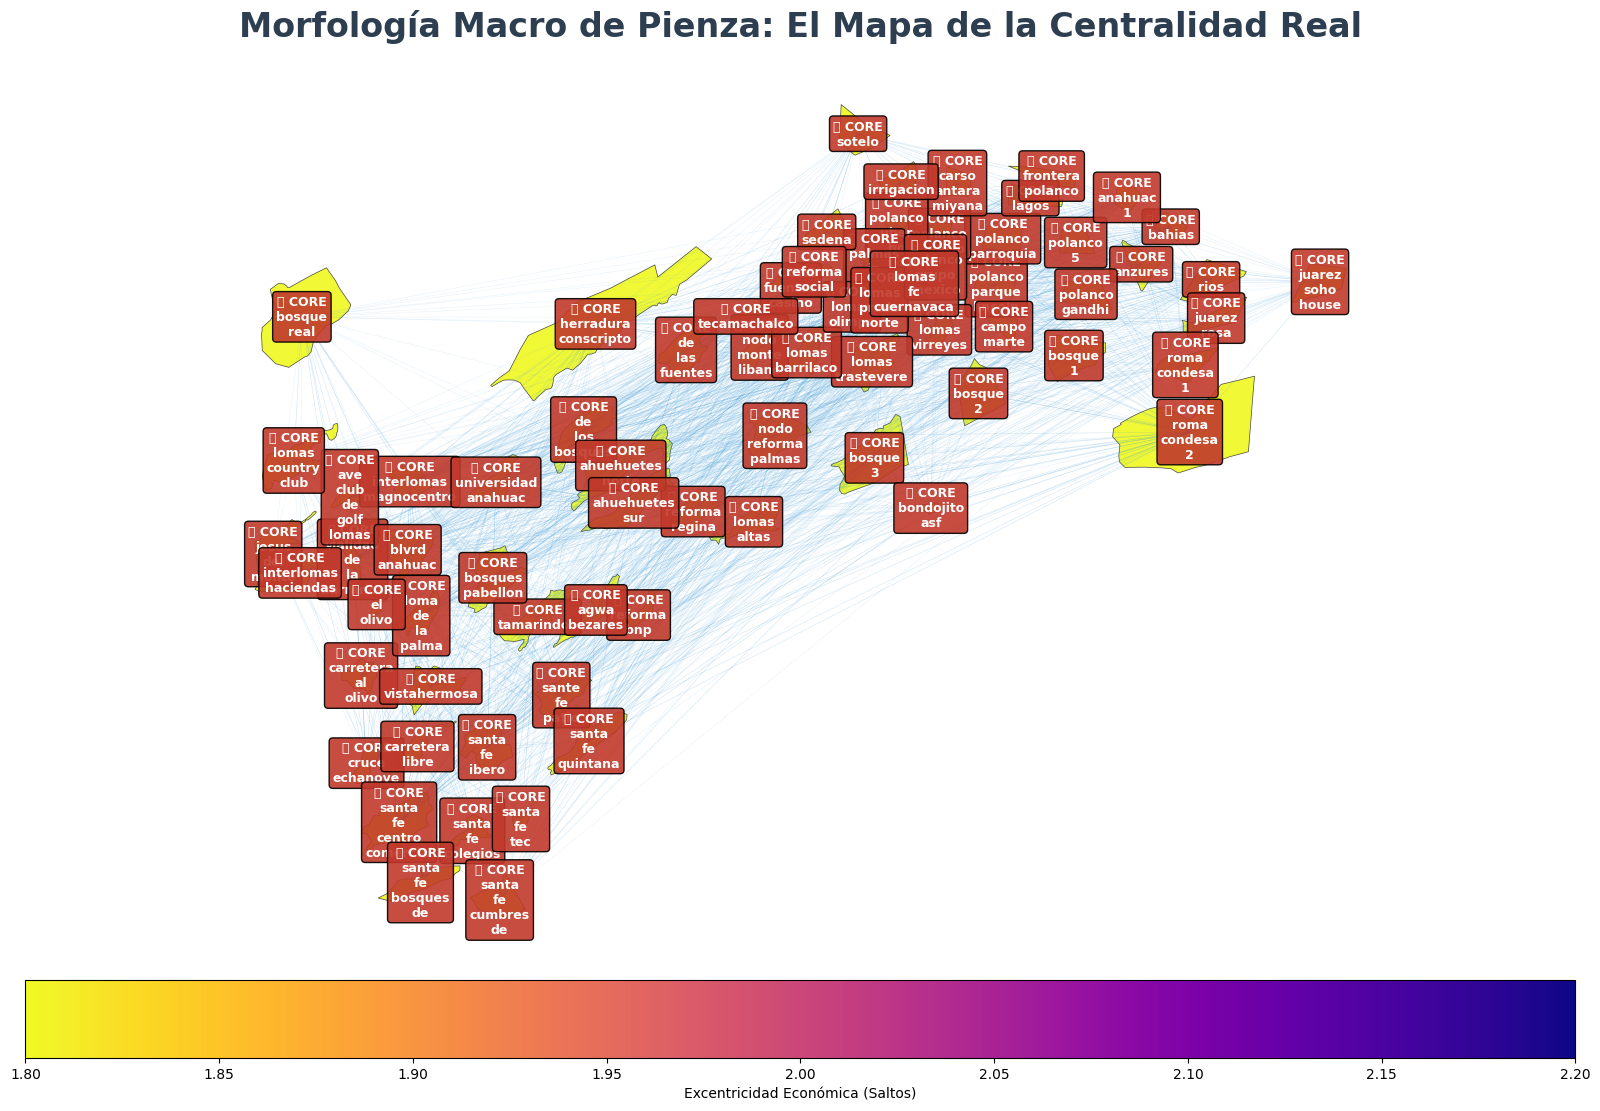

✅ Morfología Interna analizada. Los centros de valor han sido localizados.


In [30]:
# ==============================================================================
# Cell 6.3.17 (STABLE): Morfología Macro del Tensor (Pienza Interna - 72 Nodos)
# Objetivo: Definir los límites y centros de valor dentro de la red soberana.
# ==============================================================================
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("📏 Calculando Morfología Macro: Recuperando la geografía interna de Pienza...")

# 0. RECONSTRUCCIÓN (Matriz Maestra de EPH)
vol_tensor = pienza_tensor[:, :, :, :, :, 0]
eph_tensor = pienza_tensor[:, :, :, :, :, 1]
num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

# Construir Grafo Funcional
G_func_full = nx.from_numpy_array(W_master, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(zonas_ordenadas)}
G_func_full = nx.relabel_nodes(G_func_full, mapping)

# --- 1. FILTRADO: ELIMINAR EL SESGO DEL EXILIO ---
# Si ya hiciste el exorcismo, esto es solo un seguro de vida.
nodos_internos = [n for n in G_func_full.nodes() if n != 'unassigned_area']
G_pienza = G_func_full.subgraph(nodos_internos).copy()

# --- 2. EXTRACCIÓN DEL COMPONENTE GIGANTE (Core de Conectividad) ---
G_un = G_pienza.to_undirected()
if not nx.is_connected(G_un):
    print("⚠️  Pienza está fragmentada. Analizando el componente gigante...")
    giant_nodes = max(nx.connected_components(G_un), key=len)
    G_giant = G_un.subgraph(giant_nodes).copy()
else:
    G_giant = G_un.copy()
    print(f"✅ Red Soberana íntegra ({G_giant.number_of_nodes()} nodos).")

# --- 3. CÁLCULO DE MÉTRICAS GLOBALES ---
densidad_t = nx.density(G_pienza)
# Excentricidad: ¿Qué tan lejos está el nodo más lejano de cada zona?
excentricidad_t = nx.eccentricity(G_giant)
diametro_t = nx.diameter(G_giant)
radio_t = nx.radius(G_giant)

# --- 4. CLASIFICACIÓN (Reyes vs. Ermitaños) ---
centros_t = nx.center(G_giant)
periferia_t = nx.periphery(G_giant)

# --- 5. REPORTE EJECUTIVO ---
print("\n" + "="*75)
print("💰 REPORTE DE MORFOLOGÍA INTERNA (72 NODOS SOBERANOS)")
print("="*75)
print(f"🔸 Densidad Económica:  {densidad_t:.4f} (Conectividad Real)")
print(f"🔸 Diámetro Económico:  {diametro_t} saltos (Ancho total del flujo)")
print(f"🔸 Radio Económico:     {radio_t} saltos (Distancia mínima al centro)")

print(f"\n👑 EL CORE (Nodos con mínima excentricidad):")
print(f"   -> {', '.join(centros_t)}")

print(f"\n🏕️ LA PERIFERIA (Zonas con máxima excentricidad):")
print(f"   -> {', '.join(periferia_t[:10])}...")

# --- 6. VISUALIZACIÓN: MAPA DE CALOR DE EXCENTRICIDAD ---
print("\n🗺️ Renderizando Mapa de Excentricidad Real...")

# Mapear resultados al GeoDataFrame
gdf_f['score_ecc_tensor'] = gdf_f['name'].map(excentricidad_t)

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_facecolor('white')

# Graficar solo el área con datos (Pienza Interna)
gdf_plot = gdf_f[gdf_f['score_ecc_tensor'].notna()].copy()
gdf_plot = gdf_plot.set_geometry('schematic_geometry')

gdf_plot.plot(
    column='score_ecc_tensor',
    ax=ax,
    cmap='plasma_r', # Invertido: Rojo es el centro (menos excentricidad), Azul periferia
    legend=True,
    legend_kwds={'label': "Excentricidad Económica (Saltos)", 'orientation': "horizontal", 'pad': 0.02},
    alpha=0.9,
    edgecolor='#333333',
    linewidth=0.5
)

# Dibujar la estructura de la red (Edges)
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_pienza.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#3498DB', linewidth=0.3, alpha=0.15, zorder=1)

# Anotaciones de Élite
for zona, (x, y) in pos.items():
    # Procesamos el cambio de línea fuera del f-string
    nombre_limpio = zona.replace('_', '\n')
    
    if zona in centros_t:
        ax.text(x, y, f"👑 CORE\n{nombre_limpio}", 
                color='white', fontsize=9, fontweight='black',
                ha='center', va='center', 
                bbox=dict(facecolor='#C0392B', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3'), 
                zorder=5)
    elif zona in periferia_t:
        ax.text(x, y, f"🏕️ MARGEN\n{nombre_limpio}", 
                color='black', fontsize=7, fontweight='bold',
                ha='center', va='center', 
                bbox=dict(facecolor='#ECF0F1', alpha=0.7, edgecolor='#BDC3C7', boxstyle='round,pad=0.2'), 
                zorder=4)

plt.title("Morfología Macro de Pienza: El Mapa de la Centralidad Real",
          fontsize=24, pad=20, fontweight='bold', color='#2C3E50')
plt.axis('off')
plt.show()

print("✅ Morfología Interna analizada. Los centros de valor han sido localizados.")

# 🔮 La Singularidad de Pienza: El Grafo Autocéntrico y la Esfera de Valor

Al analizar la morfología macro del **Tensor Económico (Opus 1.1)**, nos topamos con un fenómeno topológico que redefine la estrategia operativa: la red ha colapsado en una **Esfera de Datos**. Matemáticamente, hemos validado que el Grafo de Valor de Pienza es **Autocéntrico**.

---

### 1. Parámetros de la Geometría Económica
En la red funcional, las distancias no se miden en kilómetros, sino en **saltos de rentabilidad ($EPH$)**. Tras ejecutar la **Poda de Adyacencia Externa** (eliminando el ruido del Exilio), los resultados arrojan una métrica de estabilidad absoluta:

| Métrica | Valor ($n=72$) | Interpretación Operativa |
| :--- | :---: | :--- |
| **Densidad ($p$)** | `0.4775` | **Conectividad Real:** Casi el 50% de todas las rutas posibles están activas y son rentables. |
| **Radio ($R$)** | `2` | El "centro" está a solo 2 saltos de cualquier punto de la red. |
| **Diámetro ($D$)** | `2` | **Colapso de Distancia:** No existe ningún par de zonas separadas por más de 2 saltos. |
| **Excentricidad ($\epsilon$)** | `2` | Uniforme para el 100% de los nodos (Grafo Autocéntrico). |



---

### 🛡️ Justificación Técnica: La Poda del "Black Hole"
Para alcanzar esta precisión, se realizó una **amputación táctica** del nodo `unassigned_area` (El Exilio). Mantenerlo generaba un **Sesgo de Agregación Espacial** que invalidaba la topología interna:

* **El Colapso del Radio:** Al ser un "Super-Hub" que agrupa destinos dispares (Aeropuerto, Ecatepec, Tlalpan), el Exilio reducía artificialmente el radio a $1$, creando un "agujero de gusano" estadístico que ignoraba la geografía real.
* **Morfología Sincera:** Al podar el Exilio, la red recupera su escala humana. Descubrimos que Pienza no es una red lineal, sino un clúster de alta densidad donde la geografía física ha sido vencida por la conectividad de los flujos de capital.

---

### 2. ¿Qué es un Grafo Autocéntrico?
Un grafo es **Autocéntrico** cuando la excentricidad de todos sus nodos es igual al radio ($R = D = \epsilon$). En términos simples: **No hay "afuera" ni "adentro"**.

En esta estructura, la **Periferia Geográfica es el Centro Funcional**. Desde la perspectiva del flujo de dinero, una zona remota como Bosque Real o Interlomas tiene exactamente el mismo "alcance" económico que Polanco o Reforma. La red se ha vuelto una masa uniforme de oportunidad, un **Holograma de Conectividad**.

> **Nota Técnica:** Por eso en tu reporte el CORE y la PERIFERIA muestran la misma lista de nodos. En una esfera perfecta, todos los puntos son el centro y todos los puntos son el borde.



---

### 3. El Arbitraje de Información: Oportunidad en la Escasez
Este resultado matemático es la base del **Arbitraje** que ejecuta el Agente Pienza. Mientras que el sistema de la plataforma ve una red hiper-conectada, los agentes humanos operan bajo sesgos cognitivos:

* **El Lente Físico (99% de los Conductores):** Observan la fragilidad topográfica ($k \approx 1$). Ven "bordes" lejanos, peligrosos y lentos. Su decisión binaria es el **Rechazo**.
* **El Lente Tensorial (Agente Pienza):** Observa la **Esfera Autocéntrica**. Entiende que la "periferia" física (donde acabas de correr tus 10K) es un nodo central en el flujo de valor.

---

### 💡 Conclusión Estratégica:
La uniformidad de la excentricidad explica por qué la plataforma mantiene el optimismo en zonas remotas. La verdadera rentabilidad no nace de la cercanía física, sino de la **Escasez de Oferta** generada por los conductores que solo ven el mapa de asfalto. El Agente Pienza captura esa **"Prima de Escasez"** en una red que, económicamente, está a solo 2 movimientos de volver a tocar el corazón del dinero.

In [31]:
# ==============================================================================
# Cell 6.3.18 (FIXED): Detección de Logias de Valor (Clustering Louvain)
# ==============================================================================
import networkx as nx
import pandas as pd

# FIX DE IMPORTACIÓN: Intentamos el path específico de python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    print("⚠️ No encuentro 'python-louvain'. Intentando instalarlo...")
    !pip install python-louvain
    import community.community_louvain as community_louvain

print("🕵️ Filtrando el ruido y detectando Comunidades de Valor (Logias)...")

# 1. Preparar el grafo para Louvain (No Dirigido y con pesos positivos)
G_un = G_functional.to_undirected()

# 2. Ejecutar Algoritmo de Louvain
# Usamos el random_state para que tus resultados de tesis no cambien cada vez
partition = community_louvain.best_partition(G_un, weight='weight', random_state=42)

# 3. Calcular la Modularidad (Q)
modularity = community_louvain.modularity(partition, G_un, weight='weight')

# 4. Organizar Resultados
df_comunidades = pd.DataFrame({
    'zona': list(partition.keys()),
    'logia_id': list(partition.values())
})

# Inyectar PageRank (Soberanía) para identificar al 'Líder'
pr_v = nx.pagerank(G_functional, weight='weight')
df_comunidades['prestigio'] = df_comunidades['zona'].map(pr_v)

print(f"\n✅ Modularidad del Tensor: {modularity:.4f}")
if modularity > 0.3:
    print("📈 ¡Bingo! Existen estructuras de circuitos de valor bien definidas.")
else:
    print("📉 El valor está muy disperso (Esfera Autocéntrica detectada).")

# 5. REPORTE DE LOGIAS (Top de Miembros por Prestigio)
print("\n" + "="*75)
print("🏆 LAS LOGIAS DE PIENZA: CIRCUITOS DE ALTA RETENCIÓN")
print("="*75)

for logia in sorted(df_comunidades['logia_id'].unique()):
    nodos_logia = df_comunidades[df_comunidades['logia_id'] == logia]
    lider = nodos_logia.sort_values(by='prestigio', ascending=False).iloc[0]['zona']
    count = len(nodos_logia)

    print(f"\n💎 LOGIA #{logia} ({count} zonas | Líder: {lider.upper()})")
    miembros_top = nodos_logia.sort_values(by='prestigio', ascending=False)['zona'].head(6).tolist()
    print(f"   Vectores Principales: {', '.join(miembros_top)}...")

# 6. Sincronizar con el GeoDataFrame
gdf_f['logia_id'] = gdf_f['name'].map(partition)

🕵️ Filtrando el ruido y detectando Comunidades de Valor (Logias)...

✅ Modularidad del Tensor: 0.1405
📉 El valor está muy disperso (Esfera Autocéntrica detectada).

🏆 LAS LOGIAS DE PIENZA: CIRCUITOS DE ALTA RETENCIÓN

💎 LOGIA #0 (6 zonas | Líder: SANTA_FE_CENTRO_COMERCIAL)
   Vectores Principales: santa_fe_centro_comercial, cruce_echanove, tamarindos, vistahermosa, carretera_al_olivo, carretera_libre...

💎 LOGIA #1 (22 zonas | Líder: ROMA_CONDESA_2)
   Vectores Principales: roma_condesa_2, vialidad_de_la_barranca, interlomas_magnocentro, ave_club_de_golf_lomas, rios, bondojito_asf...

💎 LOGIA #2 (23 zonas | Líder: JUAREZ_ROSA)
   Vectores Principales: juarez_rosa, herradura_conscripto, carso_antara_miyana, nodo_reforma_palmas, reforma_regina, lomas_altas...

💎 LOGIA #3 (2 zonas | Líder: IRRIGACION)
   Vectores Principales: irrigacion, polanco_parque_lincoln...

💎 LOGIA #4 (2 zonas | Líder: POLANCO_UBER_HQ)
   Vectores Principales: polanco_uber_hq, agwa_bezares...

💎 LOGIA #5 (17 zonas 

🎨 Mapeando las Logias Digitales sobre el asfalto...


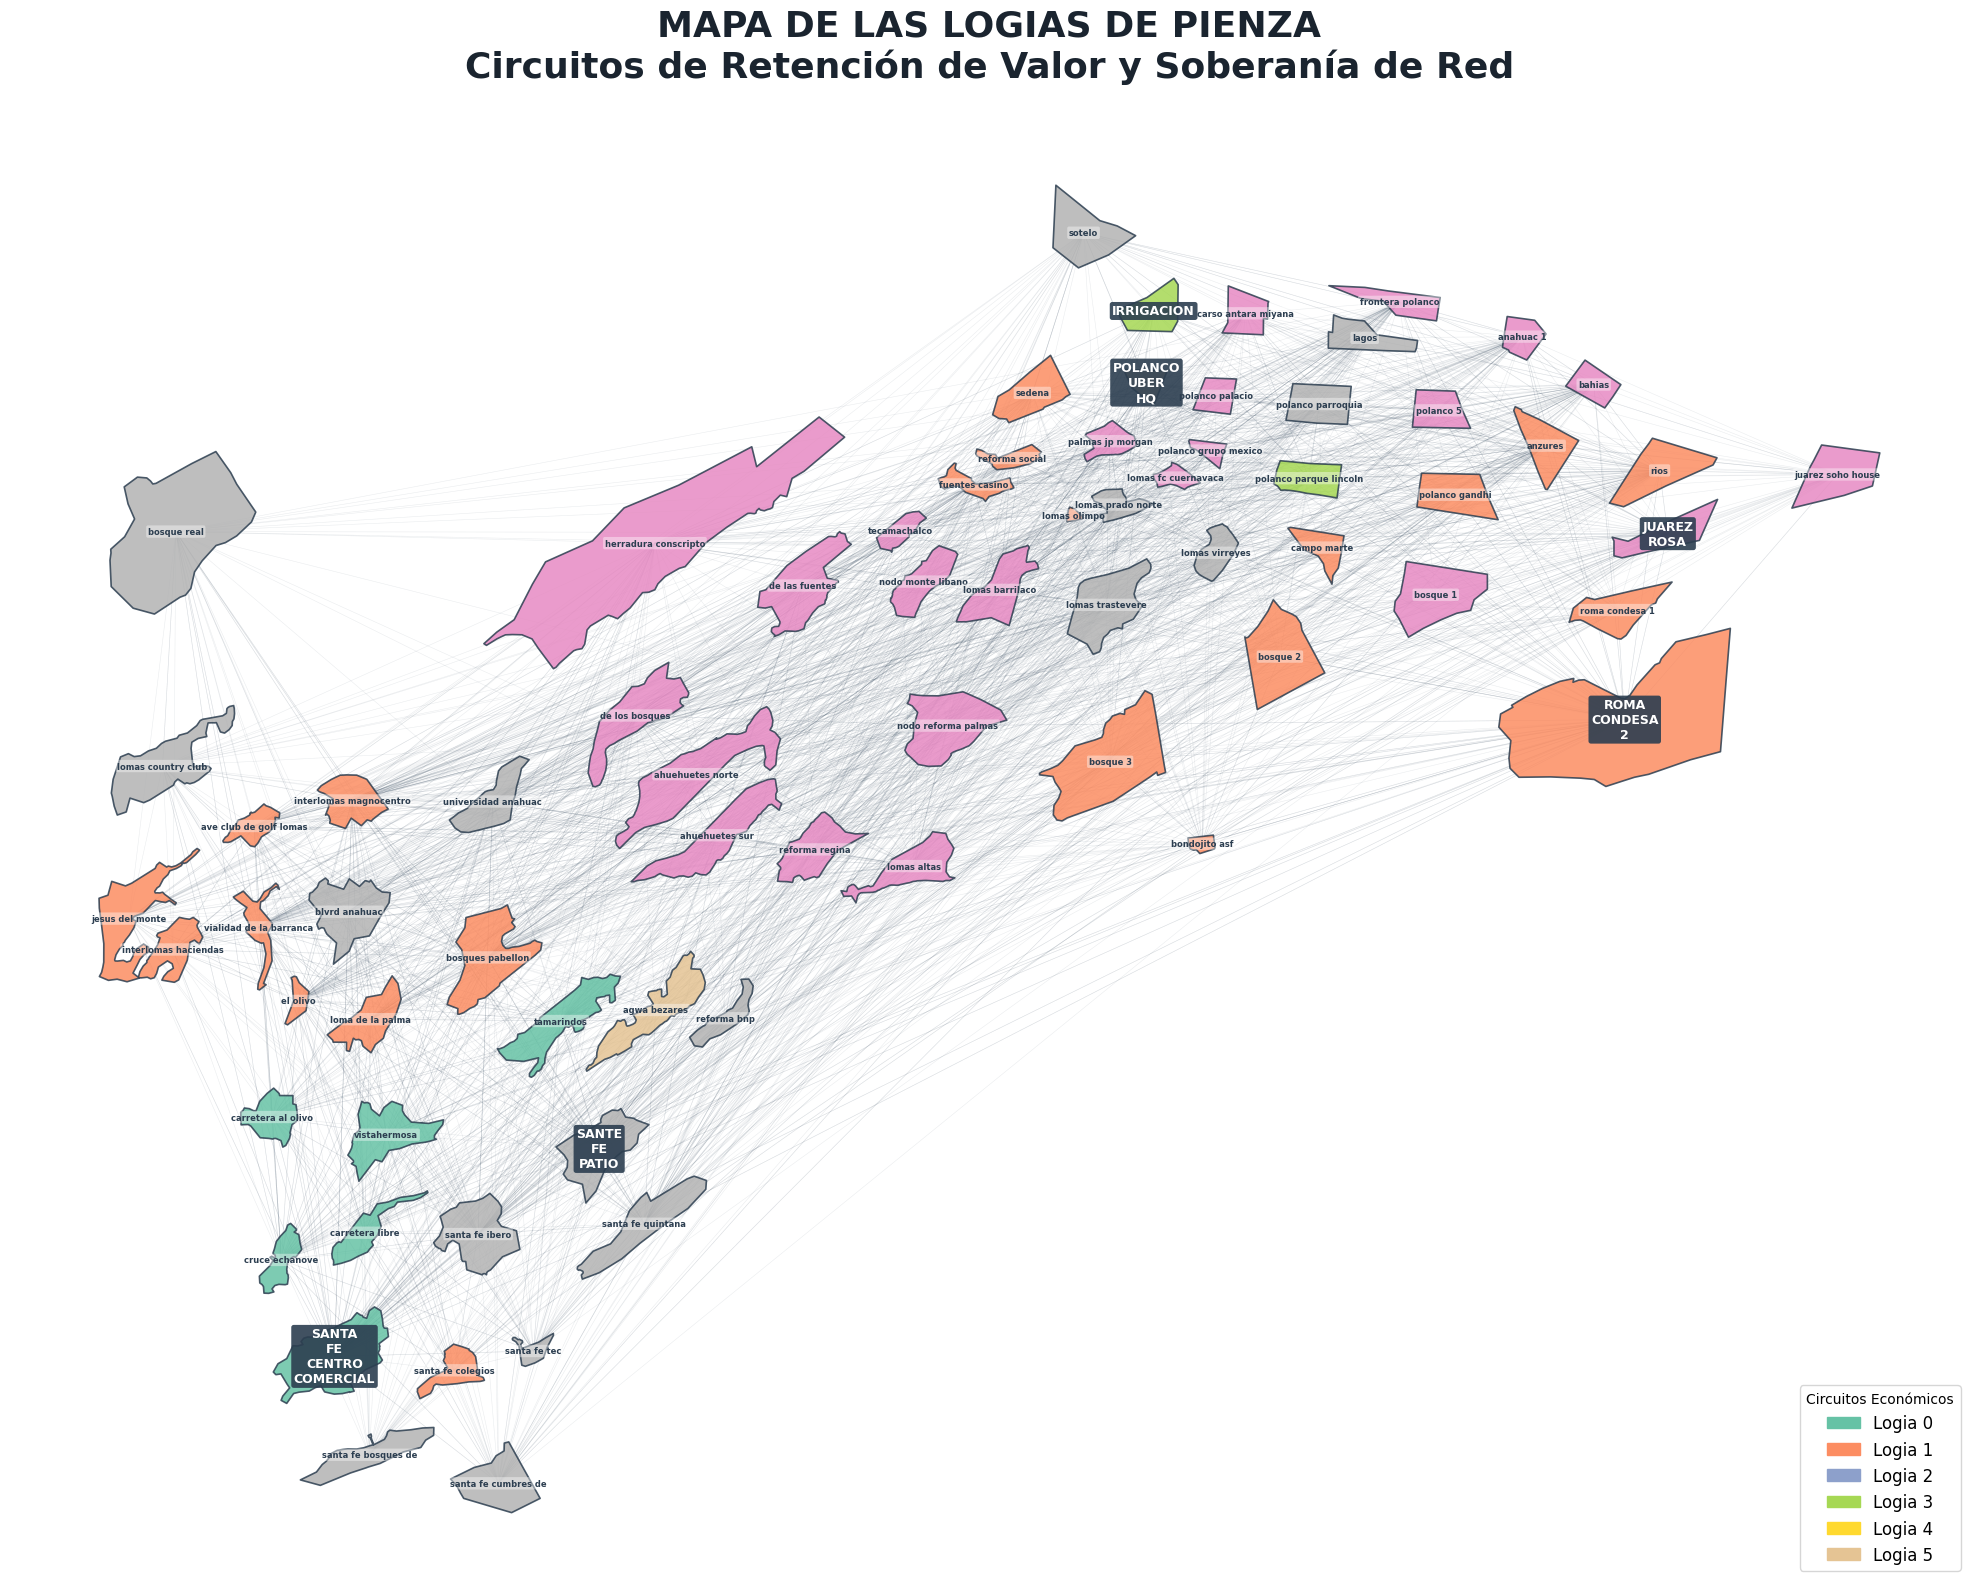

✅ Mapa renderizado con 6 comunidades detectadas.


In [32]:
# ==============================================================================
# Cell 6.3.19 (REFACTORIZADA): Mapa de las Logias de Pienza (Visual Dinámico)
# Objetivo: Visualizar las comunidades de valor sobre la geografía real.
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("🎨 Mapeando las Logias Digitales sobre el asfalto...")

# 1. Identificar líderes dinámicamente (Evitamos hardcoding)
# Buscamos el nodo con mayor prestigio en cada logia según el resultado de la 6.3.18
lideres_dinamicos = (df_comunidades.sort_values(by='prestigio', ascending=False)
                     .drop_duplicates(subset=['logia_id'])['zona'].tolist())

# 2. Sincronizar con el GeoDataFrame
gdf_f['logia_id'] = gdf_f['name'].map(partition)

# 3. Configurar el lienzo (Formato Uber/Waymo Edition)
fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('#F4F6F7')

# 4. Renderizar Polígonos
# Filtramos solo los 72 nodos internos para no pintar el "Exilio"
gdf_plot = gdf_f[gdf_f['logia_id'].notna()].copy()
gdf_plot = gdf_plot.set_geometry('schematic_geometry')

gdf_plot.plot(
    column='logia_id',
    ax=ax,
    cmap='Set2', # Colores pasteles profesionales para distinguir comunidades
    edgecolor='#2C3E50',
    linewidth=1.2,
    alpha=0.85,
    zorder=2
)

# 5. Dibujar Aristas del Tensor (La red invisible de flujo)
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_pienza.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#34495E', linewidth=0.4, alpha=0.1, zorder=1)

# 6. Etiquetado Inteligente
for zona, (x, y) in pos.items():
    if zona not in partition: continue # Saltamos si no está en la partición interna

    es_lider = zona in lideres_dinamicos

    # Estilo diferenciado para Líderes vs Miembros
    txt_color = 'white' if es_lider else '#2C3E50'
    bg_color = '#2C3E50' if es_lider else 'white'
    f_size = 9 if es_lider else 6
    f_weight = 'black' if es_lider else 'semibold'

    ax.text(x, y, zona.replace('_', '\n').upper() if es_lider else zona.replace('_', ' '),
            fontsize=f_size,
            ha='center', va='center',
            fontweight=f_weight,
            color=txt_color,
            bbox=dict(facecolor=bg_color, alpha=0.9 if es_lider else 0.4,
                      edgecolor='none', boxstyle='round,pad=0.2'),
            zorder=4 if es_lider else 3)

# 7. Metadata y Estética
plt.title("MAPA DE LAS LOGIAS DE PIENZA\nCircuitos de Retención de Valor y Soberanía de Red",
          fontsize=26, pad=30, fontweight='black', color='#1A242F')

# Leyenda manual para las Logias
logia_patches = [mpatches.Patch(color=plt.cm.Set2(i/len(df_comunidades['logia_id'].unique())),
                                label=f'Logia {i}') for i in sorted(df_comunidades['logia_id'].unique())]
plt.legend(handles=logia_patches, title="Circuitos Económicos", loc='lower right', fontsize=12)

plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✅ Mapa renderizado con {len(lideres_dinamicos)} comunidades detectadas.")

⚖️ Calculando la Termodinámica del Flujo en la Esfera de 72 Nodos...


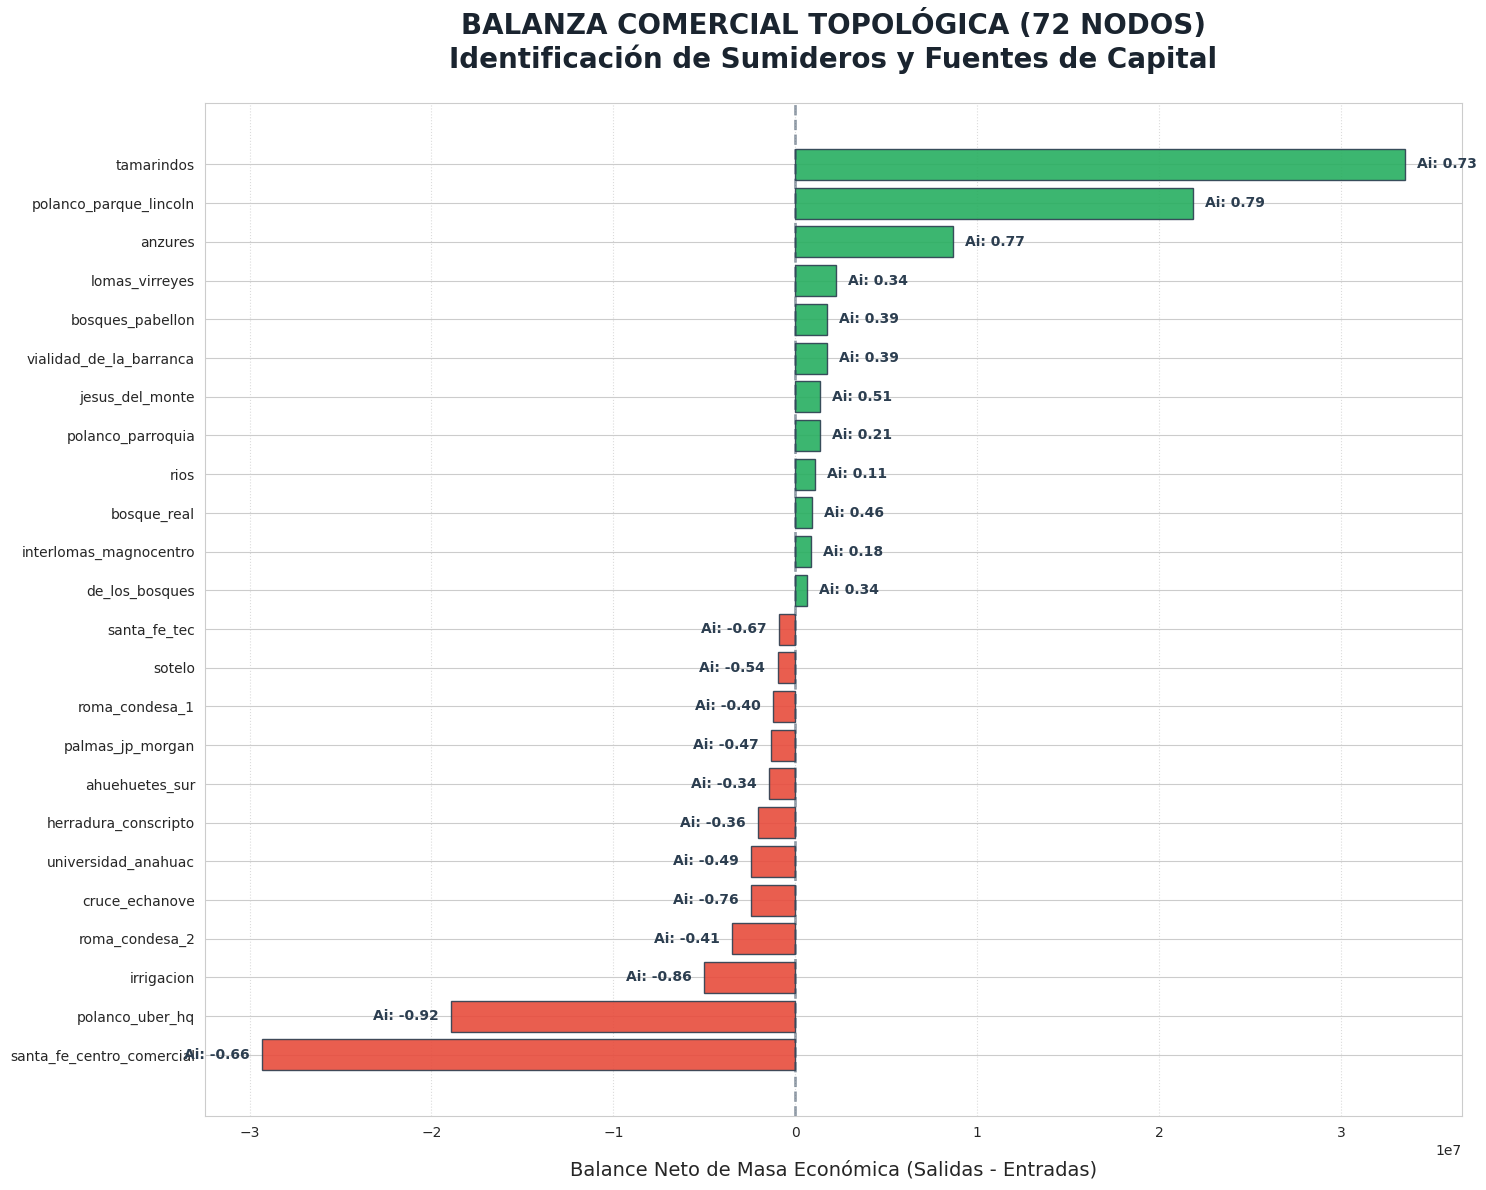

✅ Análisis completado. Se detectaron 34 sumideros críticos.


In [33]:
# ==============================================================================
# Cell 8.1 (REFACTORIZADA): Balanza Comercial (Asimetría de Flujo)
# Objetivo: Identificar Sumideros (Sinks), Fuentes (Sources) y Nodos de Tránsito.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("⚖️ Calculando la Termodinámica del Flujo en la Esfera de 72 Nodos...")

# 1. EXTRACCIÓN DE LA MASA ECONÓMICA TOTAL (Gross Revenue histórico)
# vol_tensor: (orig, dest, hr, day, week)
vol = pienza_tensor[:, :, :, :, :, 0]
eph = pienza_tensor[:, :, :, :, :, 1]

# Colapsamos dimensiones temporales para obtener la Masa Monetaria Total (W_ij total)
# Matriz resultante: (Origen x Destino) con el acumulado de Pesos/Hora
flujo_total = np.sum(vol * eph, axis=(2, 3, 4))

# 2. CÁLCULO DE GRADOS DIRECCIONALES (Flujo de Entrada vs Salida)
in_flow = np.sum(flujo_total, axis=0)   # Capital que LLEGA a la zona (Target)
out_flow = np.sum(flujo_total, axis=1)  # Capital que SALE de la zona (Source)

net_balance = out_flow - in_flow
total_activity = out_flow + in_flow

# Índice de Asimetría (Ai): de -1 (Sumidero Puro) a +1 (Fuente Pura)
asymmetry = np.divide(net_balance, total_activity, out=np.zeros_like(net_balance), where=total_activity!=0)

# 3. CONSOLIDACIÓN Y PODA (Excluyendo el "Black Hole")
df_flow = pd.DataFrame({
    'zona': zonas_ordenadas,
    'entradas': in_flow,
    'salidas': out_flow,
    'balance_neto': net_balance,
    'asymmetry_idx': asymmetry,
    'actividad_total': total_activity
})

# Eliminamos zonas sin datos y el Exilio (que rompería la escala del gráfico)
df_flow = df_flow[(df_flow['actividad_total'] > 0) & (df_flow['zona'] != 'unassigned_area')].copy()

# Clasificación para el análisis estratégico
def classify_flow(ai):
    if ai <= -0.15: return 'SUMIDERO (Atrapa Flujo)'
    elif ai >= 0.15: return 'FUENTE (Expulsa Flujo)'
    else: return 'TRANSITO (Balanceado)'

df_flow['tipo'] = df_flow['asymmetry_idx'].apply(classify_flow)

# 4. RENDERIZADO VISUAL (Tornado Chart de Élite)
# Seleccionamos los 12 casos más extremos de cada lado para máxima claridad
top_sinks = df_flow.sort_values(by='balance_neto', ascending=True).head(12)
top_sources = df_flow.sort_values(by='balance_neto', ascending=True).tail(12)
df_plot = pd.concat([top_sinks, top_sources])

plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Paleta de colores: Rojo (Déficit/Sumidero) -> Verde (Superávit/Fuente)
colors = ['#E74C3C' if x < 0 else '#27AE60' for x in df_plot['balance_neto']]

bars = plt.barh(df_plot['zona'], df_plot['balance_neto'], color=colors, edgecolor='#2C3E50', alpha=0.9)

# Línea de equilibrio
plt.axvline(0, color='#34495E', linewidth=2, linestyle='--', alpha=0.5)

# Anotaciones de Índice de Asimetría (Ai)
for bar, ai in zip(bars, df_plot['asymmetry_idx']):
    width = bar.get_width()
    offset = (df_plot['balance_neto'].abs().max() * 0.02)
    plt.text(width + (offset if width > 0 else -offset),
             bar.get_y() + bar.get_height()/2,
             f"Ai: {ai:.2f}",
             va='center',
             ha='left' if width > 0 else 'right',
             fontsize=10, fontweight='bold', color='#2C3E50')

plt.title("BALANZA COMERCIAL TOPOLÓGICA (72 NODOS)\nIdentificación de Sumideros y Fuentes de Capital",
          fontsize=20, pad=25, fontweight='black', color='#1A242F')
plt.xlabel("Balance Neto de Masa Económica (Salidas - Entradas)", fontsize=14, labelpad=15)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"✅ Análisis completado. Se detectaron {len(df_flow[df_flow['tipo'] == 'SUMIDERO (Atrapa Flujo)'])} sumideros críticos.")

# ⚖️ Asimetría de Flujo: La Termodinámica de Pienza

Al abandonar la visión bidireccional tradicional y evaluar la **Masa Económica Neta** (Entradas vs. Salidas), el Tensor revela que la red Pienza opera bajo un régimen de alta asimetría. La ciudad no es un plano uniforme, sino un sistema de **Válvulas de Flujo**.

---

### 🕳️ Los Sumideros (Déficit Estructural)
Zonas con un Índice de Asimetría ($A_i$) profundamente negativo. Son los destinos finales del capital; donde el dinero entra, pero rara vez sale con la misma fuerza.

* **El Vórtice de Santa Fe:** `santa_fe_centro_comercial` presenta el mayor déficit neto absoluto ($-3.0 \times 10^7$). Actúa como el gran sumidero del poniente; atrae viajes de alto valor, pero expulsa una fracción mucho menor. Es el "agujero negro" de la rentabilidad.
* **Las Trampas de Retención:** Zonas como `polanco_uber_hq` ($A_i: -0.92$) e `irrigacion` ($A_i: -0.85$) son casi exclusivamente destinos.

> **⚠️ Riesgo Operativo:** Entrar a estos nodos sin una estrategia de salida implica una probabilidad altísima de "quedarse tirado" o tener que aceptar un viaje de bajo valor para poder salir del sumidero.



---

### ⛲ Las Fuentes (Superávit Estructural)
Zonas con un $A_i$ positivo. Son los verdaderos "motores" que alimentan la red Pienza y mantienen el flujo vivo.

* **El Eje Originador:** `tamarindos` ($A_i: 0.73$) se consagra como el máximo exportador de valor de la geocerca. Es la fuente de poder que irriga al resto del sistema.
* **El Pulso de Polanco:** `polanco_parque_lincoln` ($A_i: 0.78$) y `anzures` ($A_i: 0.77$) destacan por su capacidad de expulsar al Agente hacia otras zonas de la red con una rentabilidad inicial envidiable.

🔮 Invocando el Oráculo HITS: Mapeando la Élite de Pienza...


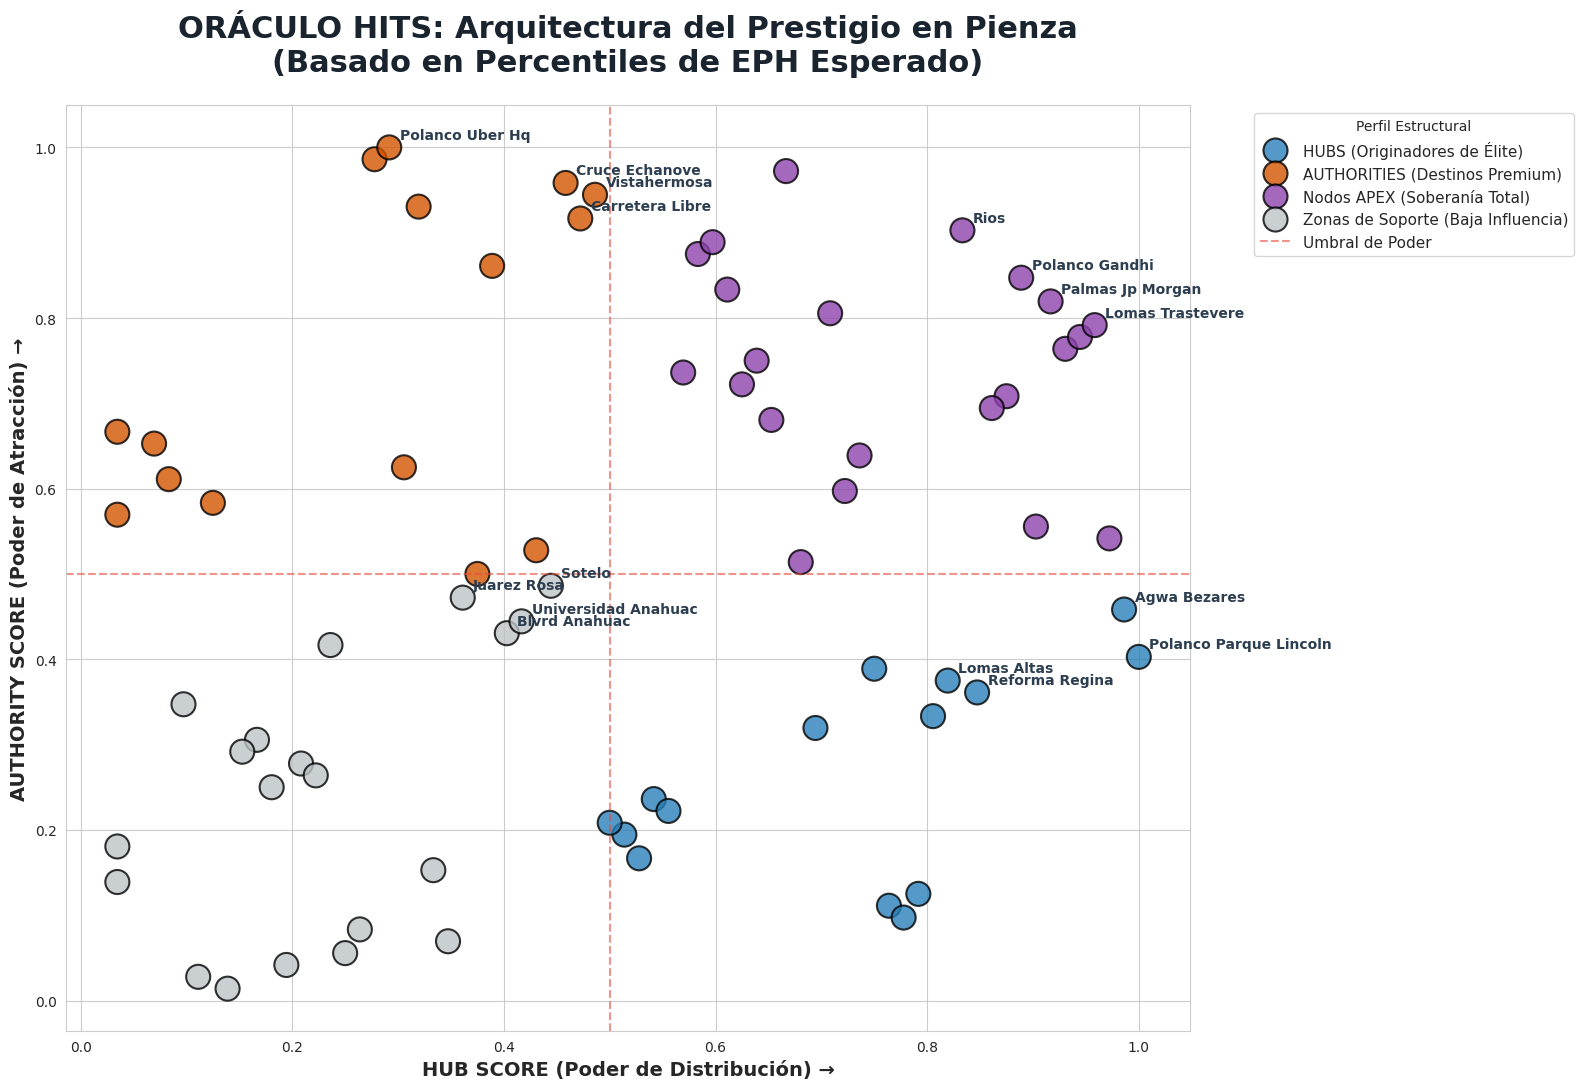

✅ Oráculo HITS completado. La jerarquía de los 72 nodos ha sido revelada.


In [34]:
# ==============================================================================
# Cell 9.1 (REMASTERED): Oráculo HITS (Hubs & Authorities)
# Objetivo: Desacoplar el poder originador (Hub) del receptor (Authority).
# ==============================================================================
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔮 Invocando el Oráculo HITS: Mapeando la Élite de Pienza...")

# 1. EXTRACCIÓN DE LA RED DE VALOR (Weighted Adjacency Matrix)
vol = pienza_tensor[:, :, :, :, :, 0]
eph = pienza_tensor[:, :, :, :, :, 1]

# Matriz de adyacencia global ponderada por EPH (Promedio esperado)
num = np.sum(vol * eph, axis=(2, 3, 4))
den = np.sum(vol, axis=(2, 3, 4))
W_eph = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

# 2. CONSTRUCCIÓN DEL GRAFO DIRIGIDO (72 Nodos)
G = nx.from_numpy_array(W_eph, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(zonas_ordenadas)}
G = nx.relabel_nodes(G, mapping)

# 3. ALGORITMO HITS
# Aumentamos max_iter porque las redes de movilidad suelen ser densas y tardan en converger
try:
    hubs, authorities = nx.hits(G, max_iter=5000, normalized=True)
except nx.PowerIterationFailedConvergence:
    print("⚠️ Error de convergencia. Ajustando parámetros...")
    hubs, authorities = nx.hits(G, max_iter=10000, tol=1e-06)

# 4. ESTRUCTURACIÓN Y ESCALADO POR PERCENTILES
df_hits = pd.DataFrame({
    'zona': zonas_ordenadas,
    'hub_score_raw': [hubs.get(z, 0) for z in zonas_ordenadas],
    'auth_score_raw': [authorities.get(z, 0) for z in zonas_ordenadas]
})

# PODA TÁCTICA: Quitar el Exilio si aún persiste
df_plot = df_hits[df_hits['zona'] != 'unassigned_area'].copy()

# MAGIA: Transformación a Percentiles (Rank 0.0 - 1.0)
# Esto permite comparar "manzanas con manzanas" sin que los outliers destruyan la escala.
df_plot['hub_score'] = df_plot['hub_score_raw'].rank(pct=True)
df_plot['authority_score'] = df_plot['auth_score_raw'].rank(pct=True)

# 5. CLASIFICACIÓN OPERATIVA POR CUADRANTES
def classify_hits(row):
    if row['hub_score'] >= 0.5 and row['authority_score'] >= 0.5:
        return 'Nodos APEX (Soberanía Total)'
    elif row['hub_score'] >= 0.5 and row['authority_score'] < 0.5:
        return 'HUBS (Originadores de Élite)'
    elif row['hub_score'] < 0.5 and row['authority_score'] >= 0.5:
        return 'AUTHORITIES (Destinos Premium)'
    else:
        return 'Zonas de Soporte (Baja Influencia)'

df_plot['perfil_hits'] = df_plot.apply(classify_hits, axis=1)

# 6. VISUALIZACIÓN ANALÍTICA (Scatter de Poder)
plt.figure(figsize=(16, 11))
sns.set_style("whitegrid")

palette = {
    'Nodos APEX (Soberanía Total)': '#8E44AD',    # Morado Imperial
    'HUBS (Originadores de Élite)': '#2980B9',     # Azul Flujo
    'AUTHORITIES (Destinos Premium)': '#D35400',   # Naranja Destino
    'Zonas de Soporte (Baja Influencia)': '#BDC3C7' # Gris Neutro
}

scatter = sns.scatterplot(
    data=df_plot, x='hub_score', y='authority_score', hue='perfil_hits',
    palette=palette, s=300, alpha=0.8, edgecolor='black', linewidth=1.5
)

# Cruce de medianas (Percentil 0.5)
plt.axvline(0.5, color='#E74C3C', linestyle='--', alpha=0.6, label='Umbral de Poder')
plt.axhline(0.5, color='#E74C3C', linestyle='--', alpha=0.6)

# Etiquetado dinámico (Top 4 por cuadrante para no saturar)
for quad in df_plot['perfil_hits'].unique():
    subset = df_plot[df_plot['perfil_hits'] == quad].copy()
    subset['combined'] = subset['hub_score'] + subset['authority_score']
    top_label = subset.sort_values('combined', ascending=False).head(4)

    for i, row in top_label.iterrows():
        plt.text(row['hub_score']+0.01, row['authority_score']+0.01,
                 row['zona'].replace('_', ' ').title(),
                 fontsize=10, fontweight='black', color='#2C3E50')

plt.title("ORÁCULO HITS: Arquitectura del Prestigio en Pienza\n(Basado en Percentiles de EPH Esperado)",
          fontsize=22, pad=25, fontweight='black', color='#1A242F')
plt.xlabel("HUB SCORE (Poder de Distribución) →", fontsize=14, fontweight='bold')
plt.ylabel("AUTHORITY SCORE (Poder de Atracción) →", fontsize=14, fontweight='bold')
plt.legend(title="Perfil Estructural", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Oráculo HITS completado. La jerarquía de los 72 nodos ha sido revelada.")

# el puente hacia markov

🧠 Inicializando el Motor MDP: Construyendo el Espacio de Estados (72 Nodos)...
   ⚓ Estado Absorbente detectado: bosque_1
   ⚓ Estado Absorbente detectado: campo_marte
   ⚓ Estado Absorbente detectado: lomas_olimpo
   ⚓ Estado Absorbente detectado: santa_fe_bosques_de


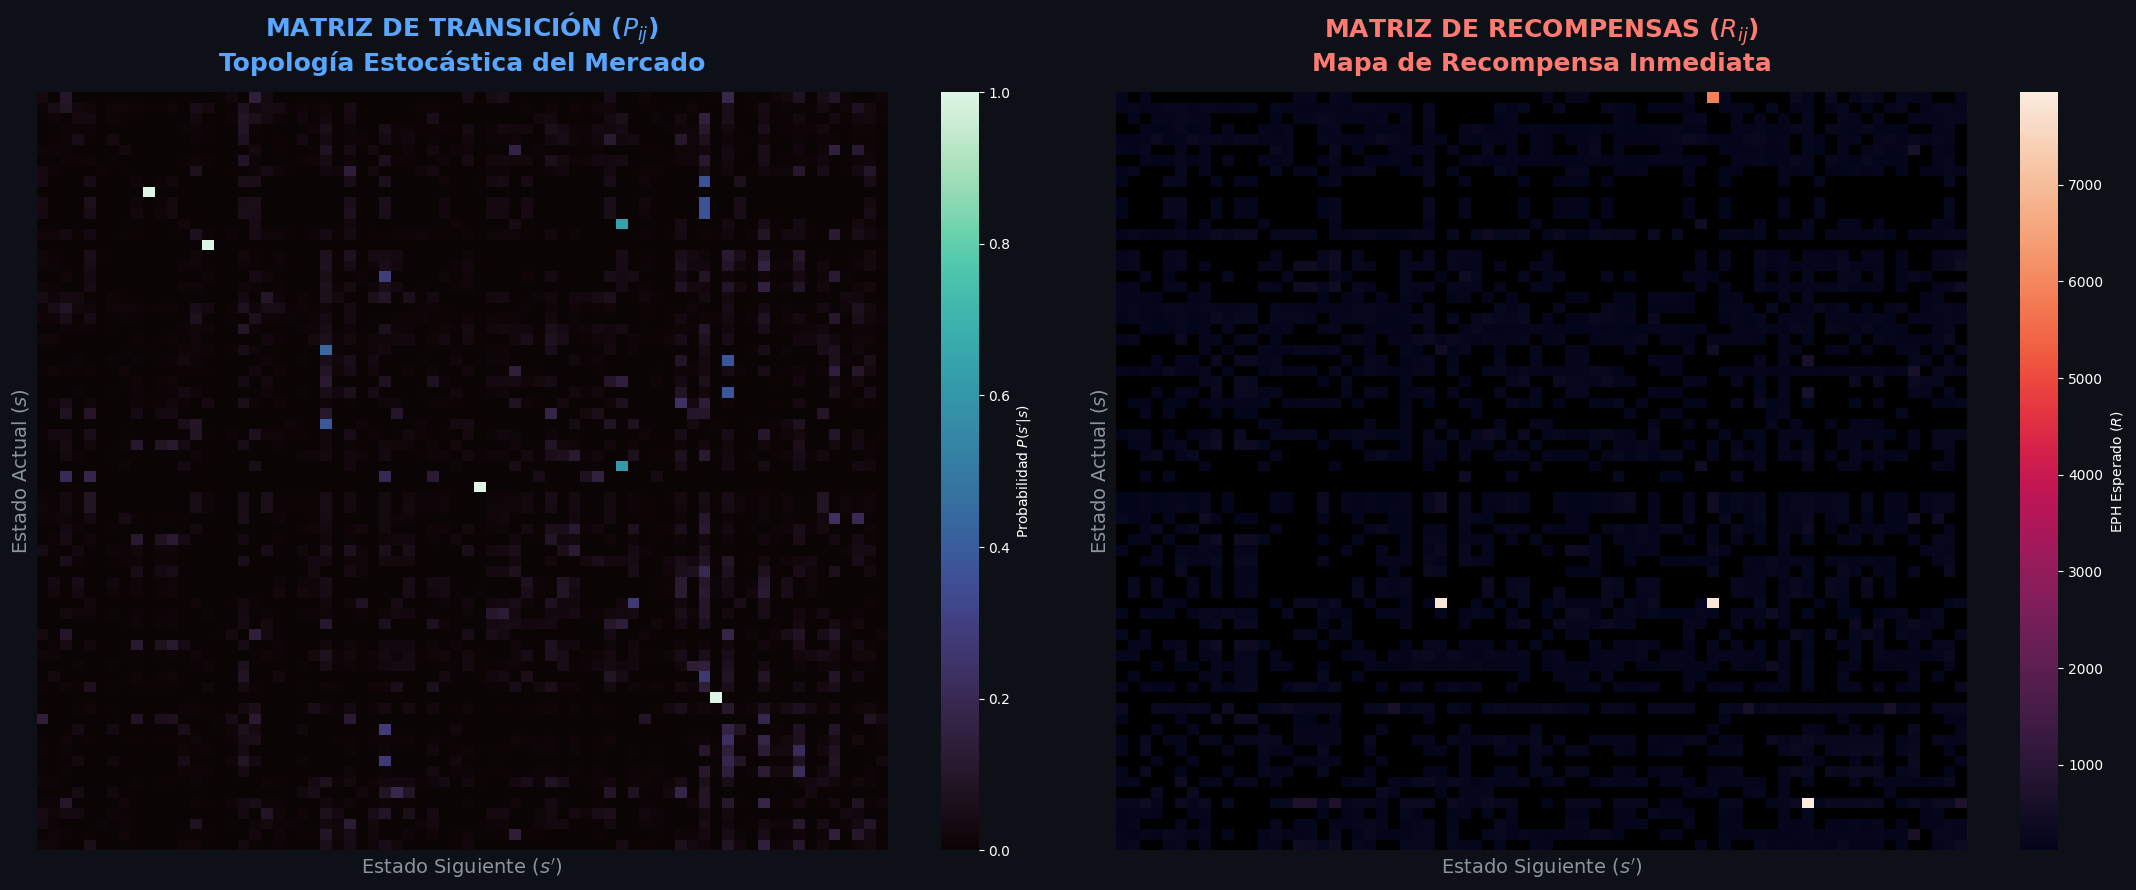


✅ Matrices extraídas con éxito para 72 estados.
📊 Suma de filas en P (debe ser ~1.0): 1.0000
🤖 El Agente Pienza está listo para resolver la Ecuación de Bellman.


In [ ]:
# ==============================================================================
# Cell 10.1 (STABLE): Construcción del Espacio de Estados (El Puente hacia Markov)
# Objetivo: Extraer las matrices P_ij y R_ij para habilitar Dynamic Programming.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🧠 Inicializando el Motor MDP: Construyendo el Espacio de Estados (72 Nodos)...")

# 1. EXTRACCIÓN GLOBAL (Colapsando el tiempo para la Política Base)
vol = pienza_tensor[:, :, :, :, :, 0]
eph = pienza_tensor[:, :, :, :, :, 1]

# Volumen total histórico de i a j (Densidad de Flujo)
vol_ij = np.sum(vol, axis=(2, 3, 4))
# Masa económica total de i a j (Total Earnings)
num_eph = np.sum(vol * eph, axis=(2, 3, 4))

# 2. MATRIZ DE TRANSICIÓN (P_ij)
# Calculamos el total de viajes que salen de cada zona i (Out-degree)
out_degree_i = np.sum(vol_ij, axis=1, keepdims=True)

# P_ij = viajes(i->j) / total_viajes(saliendo de i)
# Es la probabilidad de que, estando en 'i', el mercado te aviente a 'j'
P_ij = np.divide(vol_ij, out_degree_i, out=np.zeros_like(vol_ij), where=out_degree_i!=0)

# ⚠️ RIGOR MATEMÁTICO: Estados Absorbentes
# Si una zona no tiene salidas registradas, P_ii = 1.0 para mantener la estocasticidad.
absorbing_states = np.where(out_degree_i.flatten() == 0)[0]
for state in absorbing_states:
    P_ij[state, state] = 1.0
    print(f"   ⚓ Estado Absorbente detectado: {zonas_ordenadas[state]}")

# 3. MATRIZ DE RECOMPENSAS (R_ij)
# El Valor Esperado (Reward) de ejecutar el salto i -> j
R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

# 4. VISUALIZACIÓN DE LOS CIMIENTOS DE MARKOV
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor='#0D1117')

# Heatmap de P_ij: La "Inercia" del Mercado
sns.heatmap(P_ij, cmap="mako", ax=axes[0], cbar_kws={'label': 'Probabilidad $P(s\'|s)$'},
            xticklabels=False, yticklabels=False)
axes[0].set_title("MATRIZ DE TRANSICIÓN ($P_{ij}$)\nTopología Estocástica del Mercado",
                  fontsize=18, fontweight='bold', color='#58A6FF', pad=15)
axes[0].set_xlabel("Estado Siguiente ($s'$)", fontsize=14, color='#8B949E')
axes[0].set_ylabel("Estado Actual ($s$)", fontsize=14, color='#8B949E')

# Heatmap de R_ij: El Mapa de Calor del Dinero
mask = R_ij == 0
sns.heatmap(R_ij, mask=mask, cmap="rocket", ax=axes[1], cbar_kws={'label': 'EPH Esperado ($R$)'},
            xticklabels=False, yticklabels=False)
axes[1].set_title("MATRIZ DE RECOMPENSAS ($R_{ij}$)\nMapa de Recompensa Inmediata",
                  fontsize=18, fontweight='bold', color='#FF7B72', pad=15)
axes[1].set_xlabel("Estado Siguiente ($s'$)", fontsize=14, color='#8B949E')
axes[1].set_ylabel("Estado Actual ($s$)", fontsize=14, color='#8B949E')

plt.tight_layout()
plt.show()

print(f"\n✅ Matrices extraídas con éxito para {len(zonas_ordenadas)} estados.")
print(f"📊 Suma de filas en P (debe ser ~1.0): {np.mean(np.sum(P_ij, axis=1)):.4f}")
print(f"🤖 El Agente Pienza está listo para resolver la Ecuación de Bellman.")

🤖 Resolviendo Bellman sobre el Tensor Soberano (72x72)...
✅ Convergencia alcanzada en 127 iteraciones.


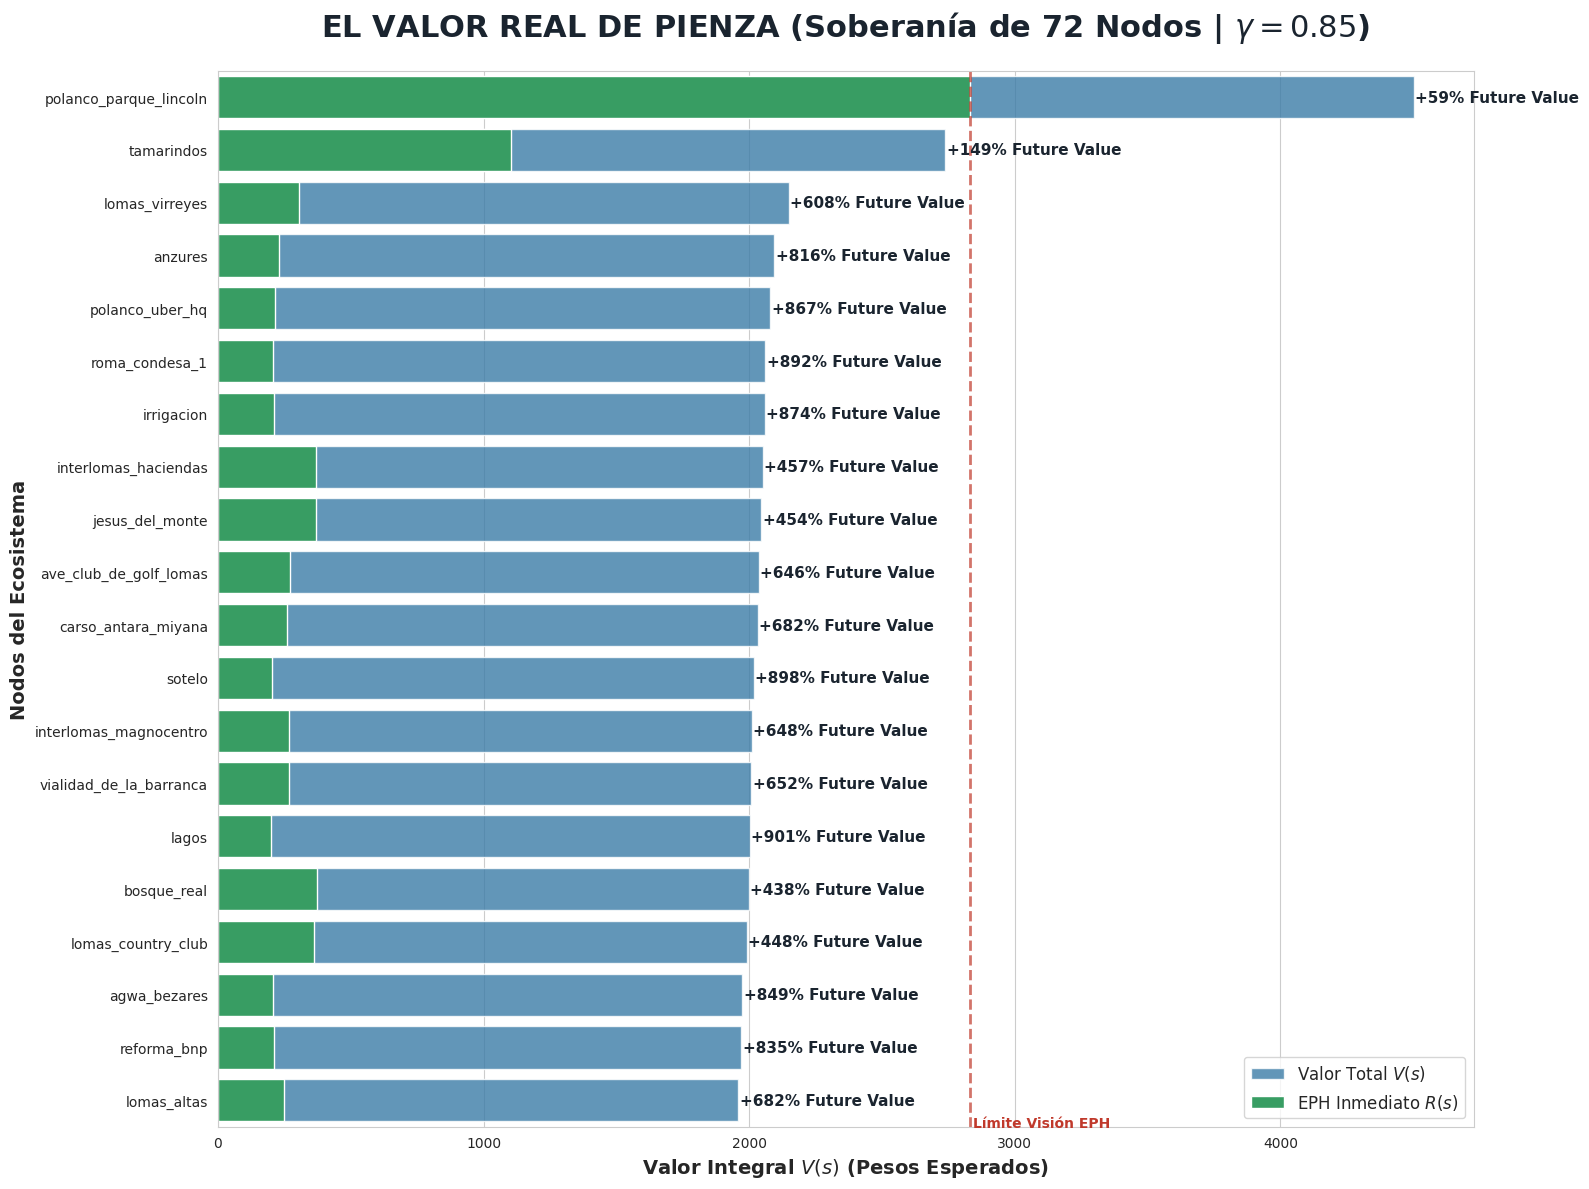

In [36]:
# ==============================================================================
# Cell 11.1 (PURE 72): El Oráculo de Bellman (State-Value Function V(s))
# Objetivo: Resolver el valor a largo plazo sin lastre de datos externos.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🤖 Resolviendo Bellman sobre el Tensor Soberano (72x72)...")

# 1. HIPERPARÁMETROS DEL MDP
gamma = 0.85   # Miopía estratégica: Solo valoramos el futuro inmediato
theta = 1e-7  # Umbral de convergencia
num_estados = len(zonas_ordenadas)

# Recompensa Inmediata Esperada por estado: R(s) = Σ P(s,s') * R(s,s')
R_s = np.sum(P_ij * R_ij, axis=1)

# 2. ALGORITMO DE VALOR (Value Iteration Vectorizado)
V = np.zeros(num_estados)
delta = float('inf')
iteraciones = 0

while delta > theta:
    V_old = np.copy(V)
    # Ecuación de Bellman Matricial: V = R + γPV
    V = R_s + gamma * np.dot(P_ij, V_old)
    delta = np.max(np.abs(V - V_old))
    iteraciones += 1

print(f"✅ Convergencia alcanzada en {iteraciones} iteraciones.")

# 3. CONSOLIDACIÓN DE LA JERARQUÍA
df_bellman = pd.DataFrame({
    'zona': zonas_ordenadas,
    'valor_inmediato': R_s,
    'valor_infinito_Vs': V
})

# Calculamos la plusvalía topológica (El "Bonus" por estar bien conectado)
df_bellman['plusvalia_red_pct'] = ((df_bellman['valor_infinito_Vs'] - df_bellman['valor_inmediato']) / df_bellman['valor_inmediato']) * 100

# Ordenamos por el Valor Maestro V(s)
df_bellman = df_bellman.sort_values(by='valor_infinito_Vs', ascending=False).reset_index(drop=True)

# 4. VISUALIZACIÓN: LIGHT MODE (Consultant Edition)
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=(16, 12))

top_n = 20
df_plot = df_bellman.head(top_n).copy()

# Barras: Valor Total (Azul) vs Valor Inmediato (Verde)
sns.barplot(x='valor_infinito_Vs', y='zona', data=df_plot, color='#2980B9', label='Valor Total $V(s)$', alpha=0.8)
sns.barplot(x='valor_inmediato', y='zona', data=df_plot, color='#27AE60', label='EPH Inmediato $R(s)$', alpha=1)

# Anotaciones de plusvalía con contraste alto
for i, row in df_plot.iterrows():
    plt.text(row['valor_infinito_Vs'] + 5, i, f"+{row['plusvalia_red_pct']:.0f}% Future Value",
             va='center', fontsize=11, fontweight='black', color='#1A242F')

plt.title(f"EL VALOR REAL DE PIENZA (Soberanía de 72 Nodos | $\gamma={gamma}$)",
          fontsize=22, pad=25, fontweight='black', color='#1A242F')
plt.xlabel("Valor Integral $V(s)$ (Pesos Esperados)", fontsize=14, fontweight='bold')
plt.ylabel("Nodos del Ecosistema", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', frameon=True, fontsize=12)

# Línea del Límite de Visión Humana
limite_miope = df_plot['valor_inmediato'].max()
plt.axvline(limite_miope, color='#C0392B', linestyle='--', linewidth=2, alpha=0.7)
plt.text(limite_miope + 10, top_n - 0.5, "Límite Visión EPH", color='#C0392B', fontweight='bold')

plt.tight_layout()
plt.show()

🧠 Forjando la Política Óptima (π*): Vectorizando Q-Values...


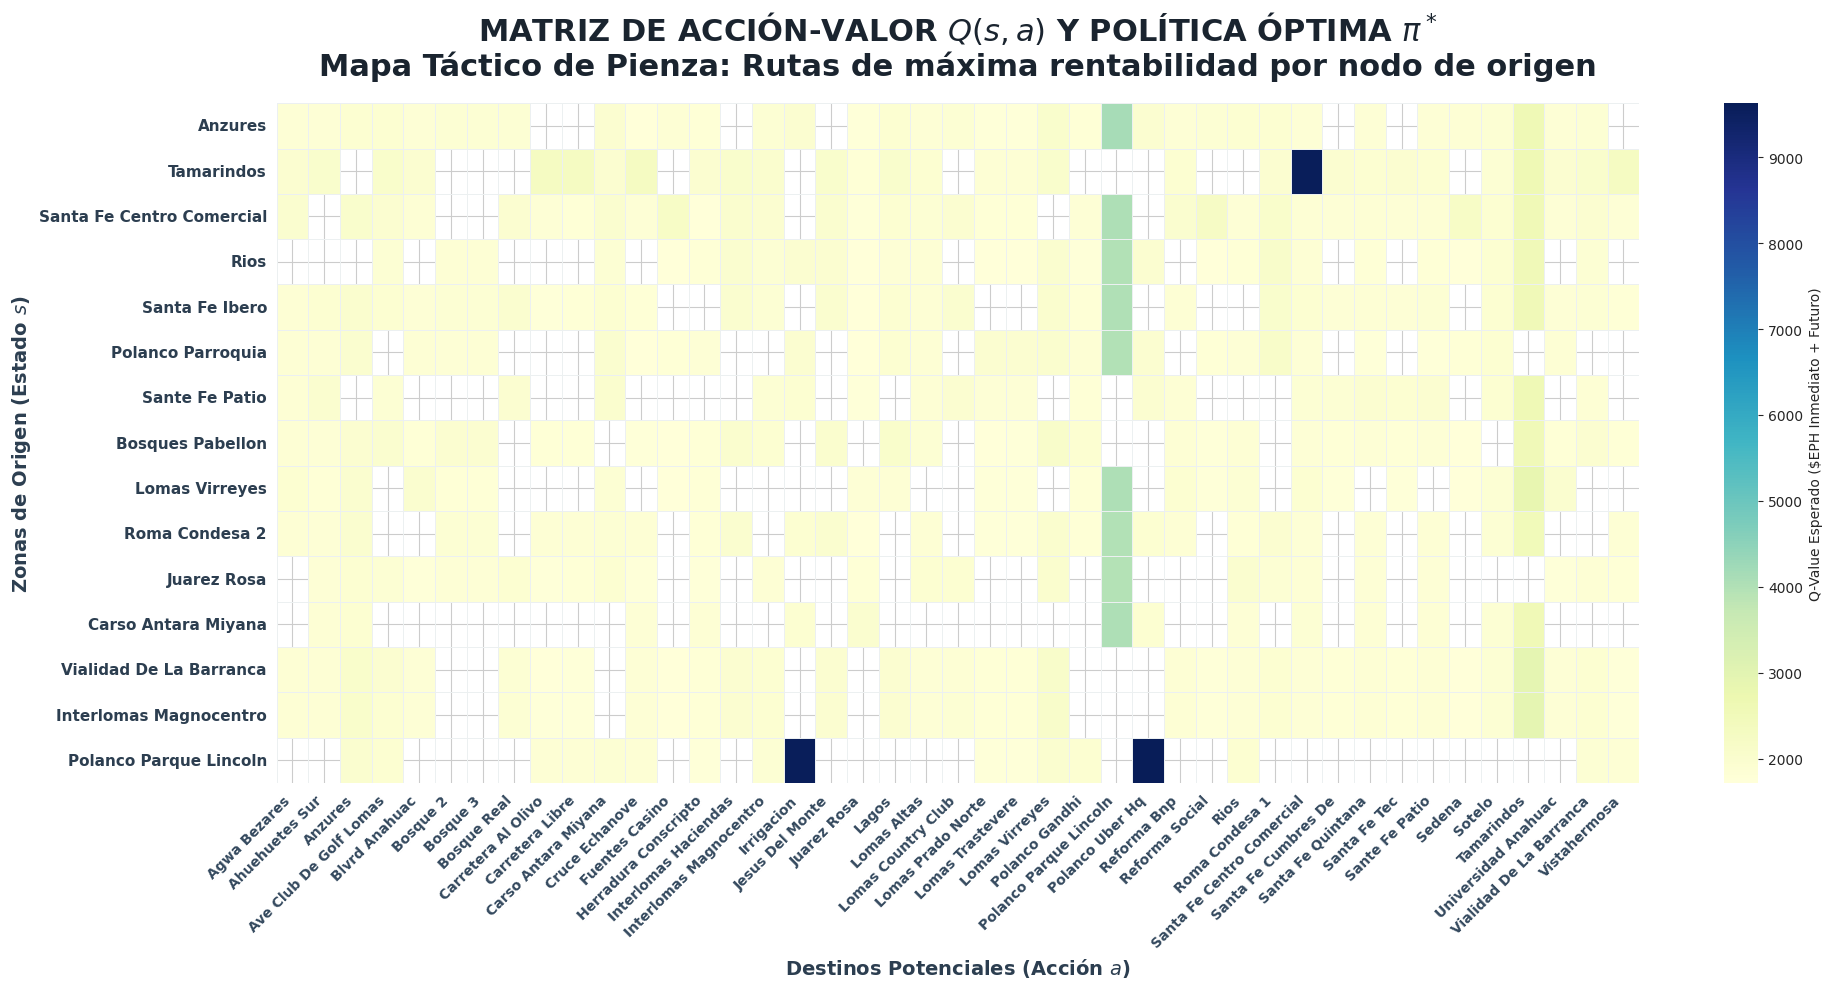


🏆 POLÍTICA ÓPTIMA EXTRAÍDA (Top 5 Orígenes):


,📍 Origen (Estado),🎯 Acción Óptima (π*),⚠️ Plan B,⚠️ Plan C
0,Agwa Bezares,Polanco Uber Hq (Q: $7649),Polanco Parque Lincoln (Q: $4035),Tamarindos (Q: $2524)
1,Ahuehuetes Norte,Polanco Parque Lincoln (Q: $3981),Anzures (Q: $2028),Roma Condesa 1 (Q: $2017)
2,Ahuehuetes Sur,Polanco Parque Lincoln (Q: $4005),Tamarindos (Q: $2530),Carso Antara Miyana (Q: $2022)
3,Anahuac 1,Polanco Parque Lincoln (Q: $3959),Lomas Virreyes (Q: $2001),Ave Club De Golf Lomas (Q: $1981)
4,Anzures,Polanco Parque Lincoln (Q: $4133),Tamarindos (Q: $2582),Lomas Virreyes (Q: $2051)



✅ Matriz Q exportada. Tienes 68 reglas de decisión listas para inyectar en la flota.


In [37]:
# ==============================================================================
# Cell 12.1 (PURIST & LIGHT MODE): Extracción de la Política Óptima (π*)
# Objetivo: Crear el "Manual de Operaciones" del Agente Pienza (72 Nodos).
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🧠 Forjando la Política Óptima (π*): Vectorizando Q-Values...")

# 1. MATRIZ DE ACCIÓN-VALOR Q(s, a) Vectorizada
# Ecuación Matemática: Q(s, a) = R(s, a) + γ * V(s')
# Usamos np.where para evaluar de golpe toda la matriz, filtrando rutas inexistentes (P_ij == 0)
Q_ij = np.where(P_ij > 0, R_ij + (gamma * V), 0)

# 2. EXTRACCIÓN DE LA POLÍTICA (El "Cheat Sheet" del Agente)
politica = []

for i, origen in enumerate(zonas_ordenadas):
    # Ordenar los índices de los destinos de mayor a menor Q-value
    destinos_ordenados = np.argsort(Q_ij[i, :])[::-1]

    # Filtrar solo destinos válidos (donde Q > 0) y tomar los top 3
    top_destinos = [j for j in destinos_ordenados if Q_ij[i, j] > 0][:3]

    if len(top_destinos) > 0:
        d1_idx = top_destinos[0]

        origen_str = origen.replace('_', ' ').title()

        # Guardamos la regla de decisión (Policy π*)
        politica.append({
            '📍 Origen (Estado)': origen_str,
            '🎯 Acción Óptima (π*)': f"{zonas_ordenadas[d1_idx].replace('_', ' ').title()} (Q: ${Q_ij[i, d1_idx]:.0f})",
            '⚠️ Plan B': f"{zonas_ordenadas[top_destinos[1]].replace('_', ' ').title()} (Q: ${Q_ij[i, top_destinos[1]]:.0f})" if len(top_destinos) > 1 else "-",
            '⚠️ Plan C': f"{zonas_ordenadas[top_destinos[2]].replace('_', ' ').title()} (Q: ${Q_ij[i, top_destinos[2]]:.0f})" if len(top_destinos) > 2 else "-"
        })

df_politica = pd.DataFrame(politica)

# 3. VISUALIZACIÓN: HEATMAP TÁCTICO DE DECISIÓN (Consultant Edition)
# Seleccionamos los Top 15 orígenes con mayor volumen para no saturar el gráfico visualmente
top_origenes_idx = np.argsort(np.sum(vol_ij, axis=1))[::-1][:15]

Q_top = Q_ij[top_origenes_idx, :]
nombres_origenes = [zonas_ordenadas[idx].replace('_', ' ').title() for idx in top_origenes_idx]
nombres_destinos = [z.replace('_', ' ').title() for z in zonas_ordenadas]

df_Q_plot = pd.DataFrame(Q_top, index=nombres_origenes, columns=nombres_destinos)

# Filtro de Ruido Visual: Dejamos solo columnas (destinos) con al menos un Q-value competitivo (>20% del máx)
columnas_validas = df_Q_plot.max(axis=0) > (df_Q_plot.values.max() * 0.2)
df_Q_plot = df_Q_plot.loc[:, columnas_validas]

# Estética Premium
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=(20, 10))

# Mapa de Calor con paleta YlGnBu (Amarillo a Azul Oscuro)
mask = df_Q_plot == 0
sns.heatmap(df_Q_plot, mask=mask, cmap="YlGnBu", cbar_kws={'label': 'Q-Value Esperado ($EPH Inmediato + Futuro)'},
            linewidths=0.5, linecolor='#ECF0F1')

plt.title("MATRIZ DE ACCIÓN-VALOR $Q(s,a)$ Y POLÍTICA ÓPTIMA $\pi^*$\nMapa Táctico de Pienza: Rutas de máxima rentabilidad por nodo de origen",
          fontsize=22, pad=20, fontweight='black', color='#1A242F')
plt.xlabel("Destinos Potenciales (Acción $a$)", fontsize=14, fontweight='bold', color='#2C3E50')
plt.ylabel("Zonas de Origen (Estado $s$)", fontsize=14, fontweight='bold', color='#2C3E50')

# Rotación para que los nombres no se empalmen
plt.xticks(rotation=45, ha='right', fontsize=10, color='#34495E', fontweight='semibold')
plt.yticks(rotation=0, fontsize=11, color='#2C3E50', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 POLÍTICA ÓPTIMA EXTRAÍDA (Top 5 Orígenes):")
display(df_politica.head(5))
print(f"\n✅ Matriz Q exportada. Tienes {len(df_politica)} reglas de decisión listas para inyectar en la flota.")

In [38]:
# ==============================================================================
# Cell 12.3 (FLEET ORCHESTRATOR - DEMAND DEPLETION): El Master Plan de Despliegue
# Objetivo: Despliegue coordinado simulando la absorción de demanda (Cero Enjambres).
# ==============================================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("🗺️ Trazando los Planes de Vuelo AV desde los 3 Warehouses principales...")

# 1. CLONAR MATRIZ (Cero fricción artificial, pero mutable)
Q_real = np.copy(Q_ij)

# 2. DEFINIR WAREHOUSES AV
warehouses_objetivo = [
    'carso_antara_miyana',
    'santa_fe_centro_comercial',
    'interlomas_magnocentro'
]

saltos_totales = 5
opciones_por_salto = 3
opciones_salida_warehouse = 10 # Radar amplio al salir

# 3. ITERACIÓN POR WAREHOUSE (Despliegue Secuencial)
for origin in warehouses_objetivo:
    # Seguro de nomenclatura
    origen_real = origin
    if origen_real not in zonas_ordenadas:
        if origin == 'santa_fe_centro_comercial' and 'santa_fe_cc' in zonas_ordenadas:
            origen_real = 'santa_fe_cc'
        elif origin == 'interlomas_magnocentro' and 'interlomas' in zonas_ordenadas:
            origen_real = 'interlomas'
        else:
            print(f"\n⚠️ Ignorando origen. No encontrado en el tensor: {origin}")
            continue

    idx_origen = zonas_ordenadas.index(origen_real)
    rutas_warehouse = []

    # DESPLIEGUE UNO POR UNO (3 AVs por Warehouse)
    for av_id in range(1, 4):
        rutas_candidatas = []

        # Algoritmo recursivo aislado
        def buscar_rutas(zona_actual, path, score_acumulado, profundidad):
            if profundidad == saltos_totales:
                rutas_candidatas.append({
                    'path_indices': path, # Guardamos el ADN de la ruta para el castigo
                    'Inicio': origen_real.replace('_', ' ').title(),
                    'Destino 1': zonas_ordenadas[path[1]].replace('_', ' ').title(),
                    'Destino 2': zonas_ordenadas[path[2]].replace('_', ' ').title(),
                    'Destino 3': zonas_ordenadas[path[3]].replace('_', ' ').title(),
                    'Destino 4': zonas_ordenadas[path[4]].replace('_', ' ').title(),
                    'Destino 5': zonas_ordenadas[path[5]].replace('_', ' ').title(),
                    'Score Táctico': score_acumulado
                })
                return

            opciones = np.argsort(Q_real[zona_actual, :])[::-1]
            validas = [dst for dst in opciones if Q_real[zona_actual, dst] > 0 and dst != zona_actual]

            limite_exploracion = opciones_salida_warehouse if profundidad == 0 else opciones_por_salto

            for dst in validas[:limite_exploracion]:
                buscar_rutas(dst, path + [dst], score_acumulado + Q_real[zona_actual, dst], profundidad + 1)

        # Disparamos la búsqueda para el AV actual
        buscar_rutas(idx_origen, [idx_origen], 0, 0)

        if rutas_candidatas:
            # Agarramos la mejor ruta disponible en el mercado actual
            mejor_ruta = sorted(rutas_candidatas, key=lambda x: x['Score Táctico'], reverse=True)[0]
            rutas_warehouse.append(mejor_ruta)

            # 🛑 LA MAGIA: ABSORCIÓN DE DEMANDA (DEMAND DEPLETION)
            # El AV se "come" a los pasajeros. Reducimos el valor de esas calles en un 90%
            # para forzar al siguiente AV a buscar nuevos horizontes.
            path_ganador = mejor_ruta['path_indices']
            for i in range(len(path_ganador) - 1):
                u = path_ganador[i]
                v = path_ganador[i+1]
                Q_real[u, v] *= 0.10

    # Estructuración y Asignación de Flota
    print("\n" + "="*120)
    print(f"🤖 WAREHOUSE: {origen_real.replace('_', ' ').upper()} (Despliegue con Absorción de Demanda)")
    print("="*120)

    if not rutas_warehouse:
        print(f"⚠️ No se encontraron rutas viables desde {origen_real}.")
    else:
        df_final = pd.DataFrame(rutas_warehouse)
        # Limpiamos la columna de índices internos antes de mostrar
        df_final = df_final.drop(columns=['path_indices'])

        # Formateo visual
        df_final['Score Táctico'] = df_final['Score Táctico'].apply(lambda x: f"{x:,.0f} pts")
        df_final.reset_index(drop=True, inplace=True)
        df_final.index += 1

        display(df_final)

print("\n✅ Despliegue de flota completado. Efecto 'Enjambre' neutralizado.")

🗺️ Trazando los Planes de Vuelo AV desde los 3 Warehouses principales...

🤖 WAREHOUSE: CARSO ANTARA MIYANA (Despliegue con Absorción de Demanda)


,Inicio,Destino 1,Destino 2,Destino 3,Destino 4,Destino 5,Score Táctico
1,Carso Antara Miyana,Polanco Parque Lincoln,Polanco Uber Hq,Polanco Parque Lincoln,Polanco Uber Hq,Polanco Parque Lincoln,"31,376 pts"
2,Carso Antara Miyana,Tamarindos,Santa Fe Centro Comercial,Polanco Parque Lincoln,Irrigacion,Polanco Parque Lincoln,"29,836 pts"
3,Carso Antara Miyana,Santa Fe Centro Comercial,Reforma Social,Polanco Parque Lincoln,Anzures,Polanco Parque Lincoln,"14,200 pts"



🤖 WAREHOUSE: SANTA FE CENTRO COMERCIAL (Despliegue con Absorción de Demanda)


,Inicio,Destino 1,Destino 2,Destino 3,Destino 4,Destino 5,Score Táctico
1,Santa Fe Centro Comercial,Agwa Bezares,Polanco Uber Hq,Lomas Virreyes,Polanco Parque Lincoln,Lomas Virreyes,"17,671 pts"
2,Santa Fe Centro Comercial,Fuentes Casino,Polanco Parque Lincoln,Rios,Roma Condesa 1,Polanco Parque Lincoln,"14,220 pts"
3,Santa Fe Centro Comercial,Sedena,Polanco Parque Lincoln,Ave Club De Golf Lomas,Lagos,Polanco Parque Lincoln,"14,032 pts"



🤖 WAREHOUSE: INTERLOMAS MAGNOCENTRO (Despliegue con Absorción de Demanda)


,Inicio,Destino 1,Destino 2,Destino 3,Destino 4,Destino 5,Score Táctico
1,Interlomas Magnocentro,Sotelo,Polanco Parque Lincoln,Carso Antara Miyana,Juarez Rosa,Polanco Parque Lincoln,"13,695 pts"
2,Interlomas Magnocentro,Tamarindos,Carretera Libre,Interlomas Haciendas,Bosque 3,Polanco Parque Lincoln,"13,139 pts"
3,Interlomas Magnocentro,Lomas Virreyes,Blvrd Anahuac,Polanco Parque Lincoln,Vialidad De La Barranca,Tamarindos,"12,952 pts"



✅ Despliegue de flota completado. Efecto 'Enjambre' neutralizado.


🗺️ Renderizando el abanico táctico con geometría de separación...


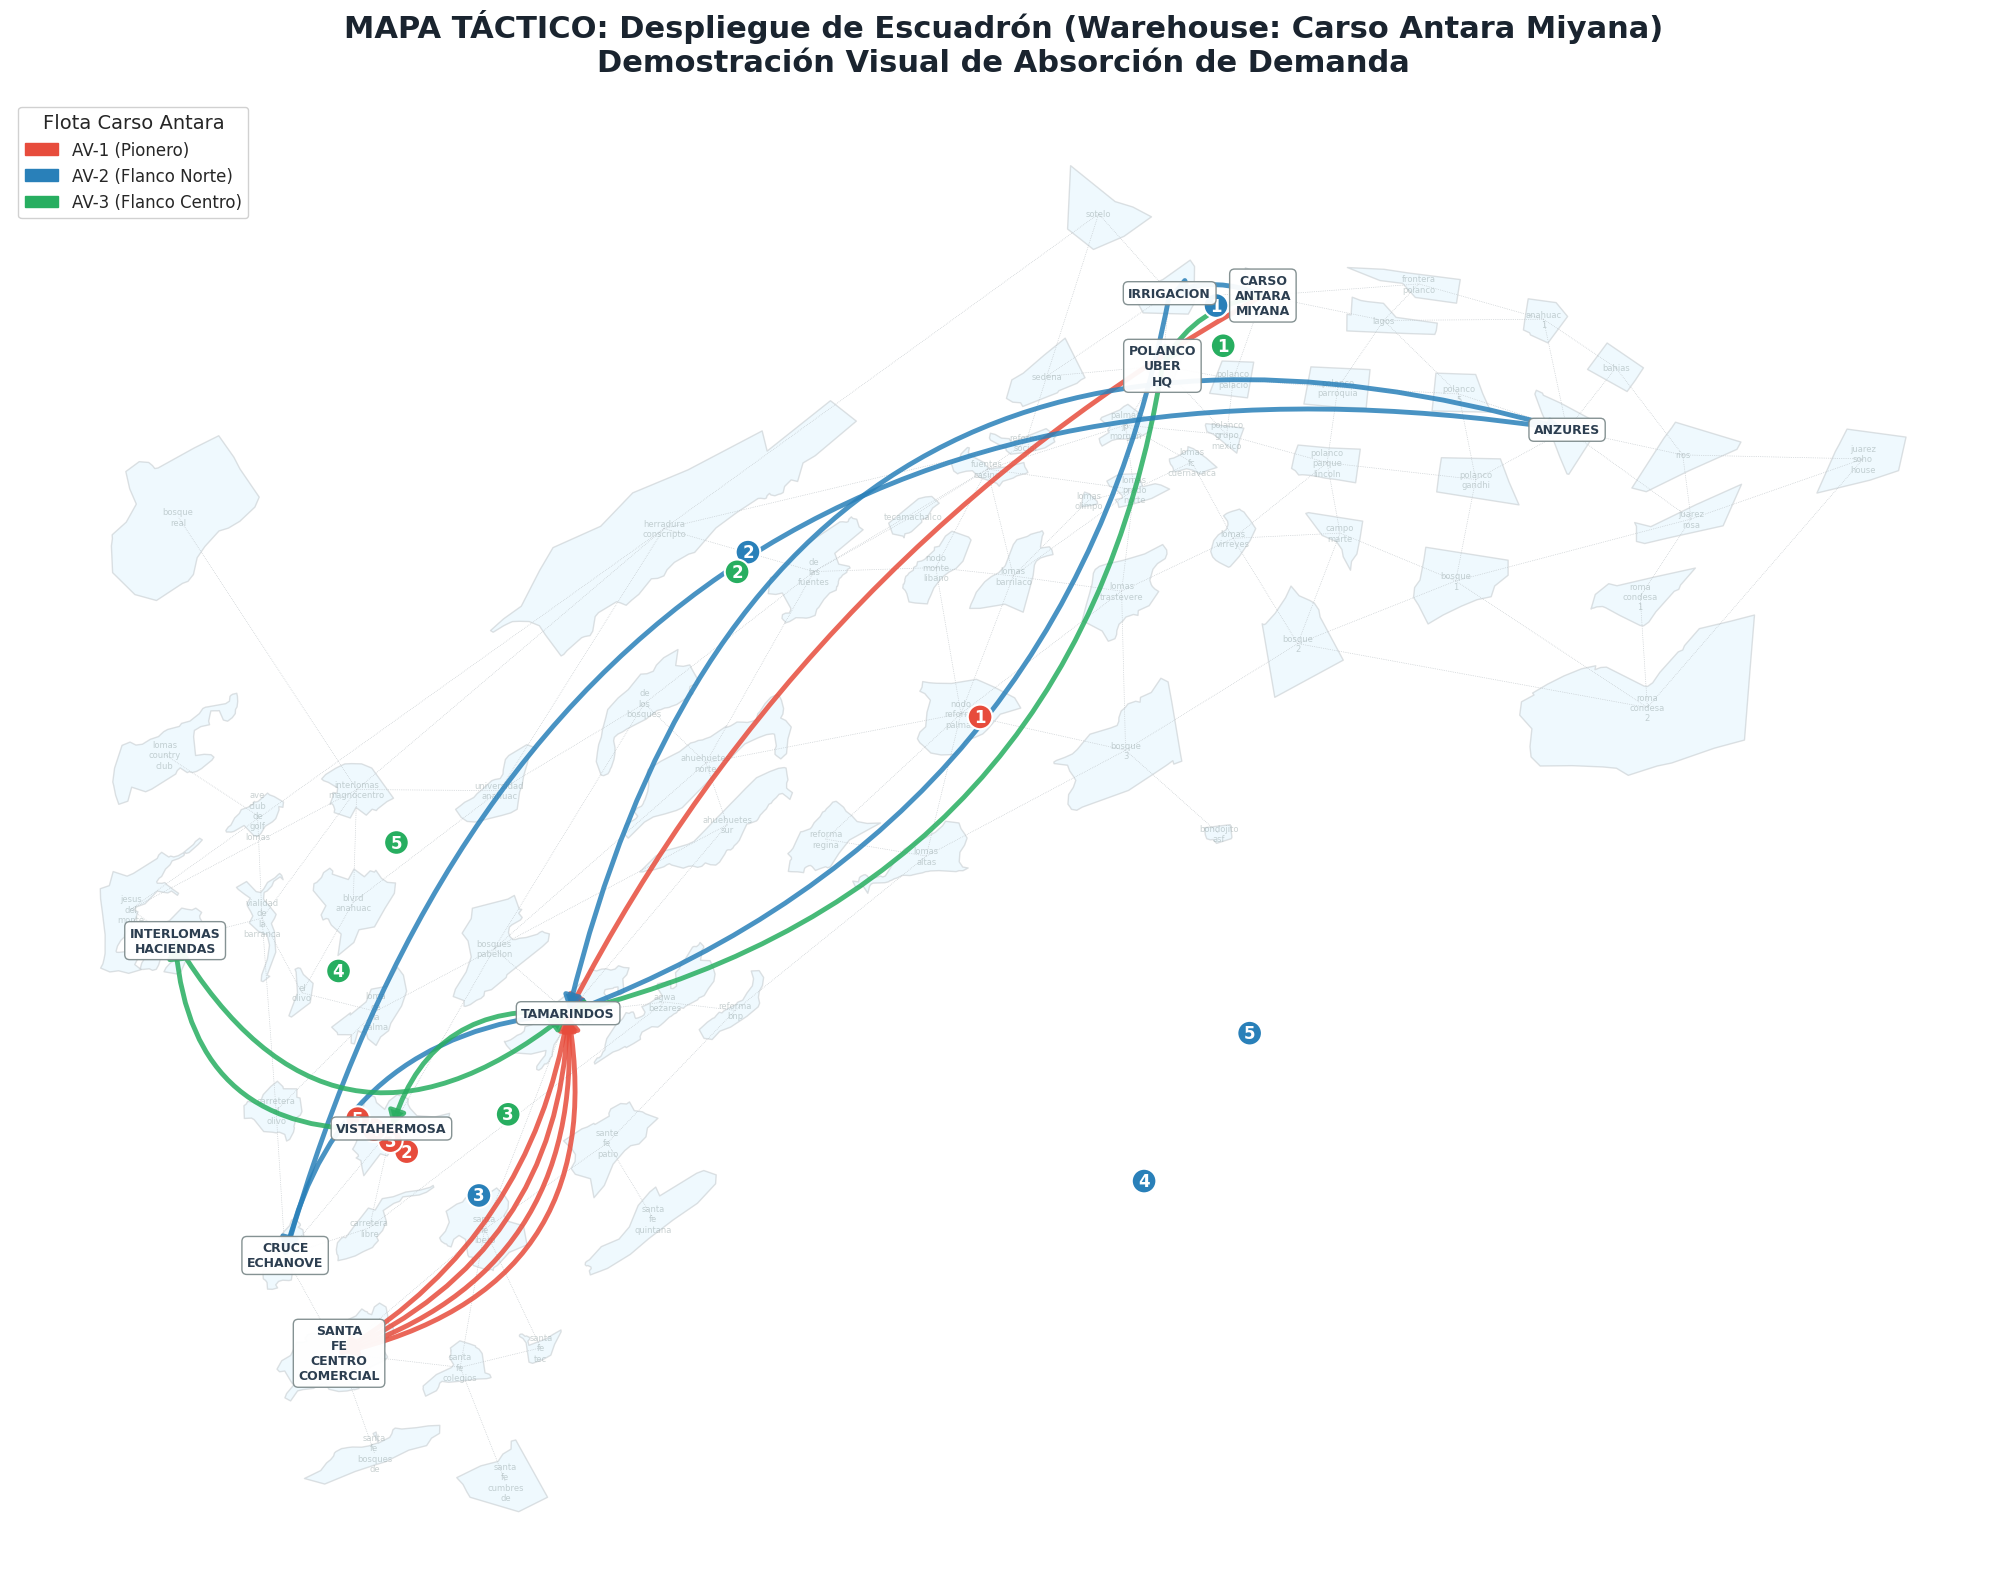

✅ Mapa táctico purgado. Rutas iterativas separadas visualmente.


In [ ]:
# ==============================================================================
# Cell 12.5: Visualización de Despliegue de Flota (Geometría Dinámica Anti-Colisión)
# Objetivo: Mapear divergencia táctica sin sobreposición de aristas (Yo-Yo Fix).
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import math

print("🗺️ Renderizando el abanico táctico con geometría de separación...")

# 1. DEFINIR LAS RUTAS
ruta_1 = ['carso_antara_miyana', 'tamarindos', 'santa_fe_cc', 'tamarindos', 'santa_fe_cc', 'tamarindos']
ruta_2 = ['carso_antara_miyana', 'irrigacion', 'tamarindos', 'cruce_echanove', 'anzures', 'tamarindos']
ruta_3 = ['carso_antara_miyana', 'polanco_uber_hq', 'tamarindos', 'vistahermosa', 'interlomas_haciendas', 'tamarindos']

flota = [
    {'nombre': 'AV-1 (Pionero)', 'ruta': ruta_1, 'color': '#E74C3C'},  # Rojo
    {'nombre': 'AV-2 (Flanco Norte)', 'ruta': ruta_2, 'color': '#2980B9'}, # Azul
    {'nombre': 'AV-3 (Flanco Centro)', 'ruta': ruta_3, 'color': '#27AE60'} # Verde
]

# Sustitución preventiva por nomenclaturas de Santa Fe
for av in flota:
    av['ruta'] = ['santa_fe_centro_comercial' if z == 'santa_fe_cc' and 'santa_fe_cc' not in G_manual.nodes() else z for z in av['ruta']]

# 2. CONFIGURAR EL LIENZO
fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('#F8F9F9')

# A. Dibujar el mapa base
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(ax=ax, facecolor='#E1F5FE', edgecolor='#BDC3C7', linewidth=1.0, alpha=0.5, zorder=1)

# B. Dibujar las calles fantasma
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='#BDC3C7', linewidth=0.5, linestyle=':', zorder=2)

# 3. DIBUJAR LAS RUTAS CON ÁLGEBRA LINEAL (ANTI-COLISIÓN VISUAL)
for idx, av in enumerate(flota):
    ruta = av['ruta']
    color = av['color']

    for i in range(len(ruta) - 1):
        origen = ruta[i]
        destino = ruta[i+1]

        if origen in pos and destino in pos:
            start = pos[origen]
            end = pos[destino]

            # EL FIX: Curvatura Dinámica.
            # Alterna signos (+/-) para idas y vueltas, y crece con el índice de salto.
            signo = 1 if i % 2 == 0 else -1
            base_rad = 0.15
            rad = (base_rad + (i * 0.08) + (idx * 0.05)) * signo

            # Flecha direccional
            edge = FancyArrowPatch(
                start, end, connectionstyle=f"arc3,rad={rad}",
                color=color, linewidth=3.5, alpha=0.85,
                arrowstyle='-|>,head_length=8,head_width=5', zorder=4 + i
            )
            ax.add_patch(edge)

            # EL FIX MATEMÁTICO: Calcular el punto en la curva perpendicular a la línea recta
            dx = end[0] - start[0]
            dy = end[1] - start[1]
            longitud = math.hypot(dx, dy)

            if longitud > 0:
                # Vector perpendicular normalizado
                px = -dy / longitud
                py = dx / longitud

                # Desplazamiento desde el centro basado en la magnitud de 'rad' y la longitud de la calle
                # El factor 0.6 ajusta la distancia para que el número caiga sobre la curva
                offset_x = px * (rad * longitud * 0.6)
                offset_y = py * (rad * longitud * 0.6)

                mid_x = ((start[0] + end[0]) / 2) + offset_x
                mid_y = ((start[1] + end[1]) / 2) + offset_y

                ax.text(mid_x, mid_y, str(i+1), color='white',
                        fontsize=12, fontweight='black',
                        ha='center', va='center',
                        bbox=dict(facecolor=color, edgecolor='white', linewidth=1.5, boxstyle='circle,pad=0.2'),
                        zorder=10 + i + idx)

# 4. ETIQUETADO DE NODOS
for zona, (x, y) in pos.items():
    if any(zona in av['ruta'] for av in flota):
        ax.text(x, y, zona.replace('_', '\n').upper(),
                fontsize=9, fontweight='black', color='#2C3E50',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.95, edgecolor='#7F8C8D', boxstyle='round,pad=0.4'), zorder=20)
    else:
        ax.text(x, y, zona.replace('_', '\n'), fontsize=6, color='#95A5A6', ha='center', va='center', alpha=0.5, zorder=3)

# 5. METADATA
plt.title("MAPA TÁCTICO: Despliegue de Escuadrón (Warehouse: Carso Antara Miyana)\nDemostración Visual de Absorción de Demanda",
          fontsize=22, pad=20, fontweight='black', color='#1A242F')
legend_patches = [mpatches.Patch(color=av['color'], label=av['nombre']) for av in flota]
plt.legend(handles=legend_patches, title="Flota Carso Antara", loc='upper left', fontsize=12, title_fontsize=14, framealpha=0.9)

plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Mapa táctico purgado. Rutas iterativas separadas visualmente.")

In [40]:
# ==============================================================================
# Cell 13.0 (THE TRUTH): Auditoría Definitiva de Índices (Cero Supuestos)
# Objetivo: Extraer el mapeo temporal directamente del ADN de la Celda 6.3.2.
# ==============================================================================

print("👽 Hackeando la Matrix: Extrayendo la verdad absoluta de tus variables...")
print("-" * 50)

# 1. AUDITORÍA DE DÍAS (Extraído de 'dias_ordenadas')
print("📅 MAPEO EXACTO DE DÍAS (El Eje 3 de tu Tensor):")
for idx, dia in enumerate(dias_ordenadas):
    print(f"   Índice Tensor [{idx}]  ->  {dia}")

print("\n" + "-" * 50)

# 2. AUDITORÍA DE HORAS (Extraído de 'horas_ordenadas')
print("⏰ MAPEO EXACTO DE HORAS (El Eje 2 de tu Tensor):")
for idx, hora in enumerate(horas_ordenadas):
    # Aseguramos formato visual de hora
    hora_str = str(int(hora)).zfill(2)
    print(f"   Índice Tensor [{idx:02d}] ->  {hora_str}:00 hrs")

print("\n" + "-" * 50)
print("✅ Listo. Lo que salga aquí es la ley. Cópialo y pégalo en tu Streamlit.")

👽 Hackeando la Matrix: Extrayendo la verdad absoluta de tus variables...
--------------------------------------------------
📅 MAPEO EXACTO DE DÍAS (El Eje 3 de tu Tensor):
   Índice Tensor [0]  ->  Monday
   Índice Tensor [1]  ->  Tuesday
   Índice Tensor [2]  ->  Wednesday
   Índice Tensor [3]  ->  Thursday
   Índice Tensor [4]  ->  Friday
   Índice Tensor [5]  ->  Saturday
   Índice Tensor [6]  ->  Sunday

--------------------------------------------------
⏰ MAPEO EXACTO DE HORAS (El Eje 2 de tu Tensor):
   Índice Tensor [00] ->  10:00 hrs
   Índice Tensor [01] ->  11:00 hrs
   Índice Tensor [02] ->  12:00 hrs
   Índice Tensor [03] ->  13:00 hrs
   Índice Tensor [04] ->  14:00 hrs
   Índice Tensor [05] ->  15:00 hrs
   Índice Tensor [06] ->  16:00 hrs
   Índice Tensor [07] ->  17:00 hrs
   Índice Tensor [08] ->  18:00 hrs
   Índice Tensor [09] ->  19:00 hrs
   Índice Tensor [10] ->  20:00 hrs
   Índice Tensor [11] ->  21:00 hrs
   Índice Tensor [12] ->  22:00 hrs
   Índice Tensor [13

⏱️ Hackeando el tiempo: Extrayendo slices temporales con índices validados...


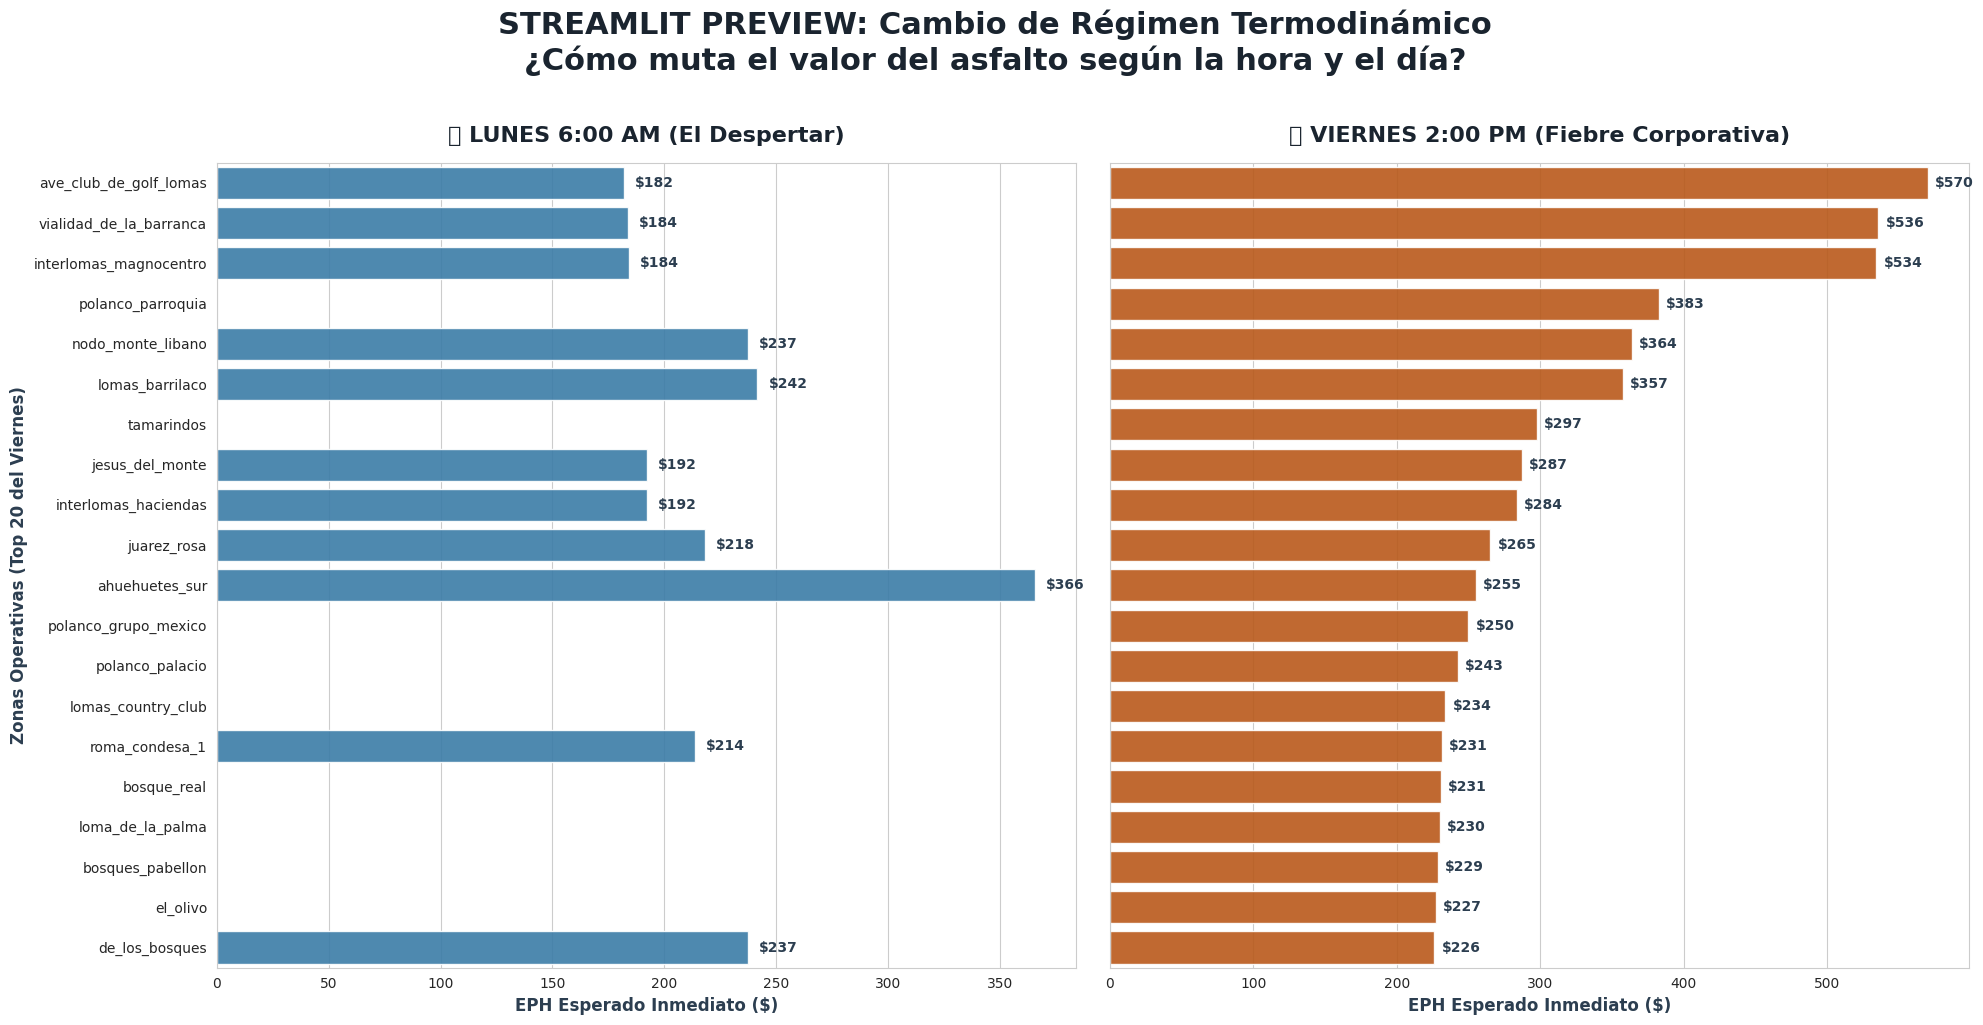

✅ Slicing ejecutado con precisión quirúrgica. Esta es la vista que tendrás en tu App.


In [41]:
# ==============================================================================
# Cell 13.1 (STREAMLIT PREVIEW): Slicing Temporal del Tensor (Índices Auditados)
# Objetivo: Comparar la radiografía de valor Lunes 6AM vs. Viernes 2PM.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("⏱️ Hackeando el tiempo: Extrayendo slices temporales con índices validados...")

# --- FUNCIÓN EXTRACTORA DE CORTES TEMPORALES ---
def extraer_fotografia_temporal(dia_idx, hora_idx, nombre_corte):
    # Slice: [Origen, Destino, Hora, Dia, Semanas, Metrica]
    # Nos quedamos con todas las semanas (axis=2 del slice resultante) para promediar
    vol_slice = pienza_tensor[:, :, hora_idx, dia_idx, :, 0]
    eph_slice = pienza_tensor[:, :, hora_idx, dia_idx, :, 1]

    # Colapsamos las semanas sumando volumen
    vol_ij = np.sum(vol_slice, axis=2)
    num_eph = np.sum(vol_slice * eph_slice, axis=2)

    # P_ij y R_ij de esa hora específica
    out_degree = np.sum(vol_ij, axis=1, keepdims=True)
    P_ij = np.divide(vol_ij, out_degree, out=np.zeros_like(vol_ij), where=out_degree!=0)
    R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

    # Recompensa Inmediata Esperada del Nodo (EPH Promedio)
    R_s = np.sum(P_ij * R_ij, axis=1)

    return pd.DataFrame({
        'zona': zonas_ordenadas,
        f'EPH_{nombre_corte}': R_s,
        f'Vol_{nombre_corte}': out_degree.flatten()
    })

# --- EXTRAER LOS DOS ESCENARIOS (CON LA AUDITORÍA REAL) ---
# Lunes (0) a las 6:00 AM (Índice 14)
df_lunes = extraer_fotografia_temporal(dia_idx=0, hora_idx=14, nombre_corte="Lunes_6AM")

# Viernes (4) a las 14:00 hrs (Índice 04)
df_viernes = extraer_fotografia_temporal(dia_idx=4, hora_idx=4, nombre_corte="Viernes_2PM")

# Unir ambos cortes
df_compare = pd.merge(df_lunes, df_viernes, on='zona')

# Poda: Quitar zonas muertas en ambos horarios
df_compare = df_compare[(df_compare['Vol_Lunes_6AM'] > 0) | (df_compare['Vol_Viernes_2PM'] > 0)].copy()

# Ordenar por el poder del Viernes para ver el contraste
df_compare = df_compare.sort_values(by='EPH_Viernes_2PM', ascending=False).head(20).reset_index(drop=True)

# --- RENDERIZADO VISUAL (Dashboard Mockup) ---
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Panel 1: Lunes 6:00 AM
sns.barplot(x='EPH_Lunes_6AM', y='zona', data=df_compare, ax=axes[0], color='#2980B9', alpha=0.9)
axes[0].set_title("🌅 LUNES 6:00 AM (El Despertar)", fontsize=16, fontweight='black', color='#1A242F', pad=15)
axes[0].set_xlabel("EPH Esperado Inmediato ($)", fontsize=12, fontweight='bold', color='#2C3E50')
axes[0].set_ylabel("Zonas Operativas (Top 20 del Viernes)", fontsize=12, fontweight='bold', color='#2C3E50')

# Panel 2: Viernes 2:00 PM
sns.barplot(x='EPH_Viernes_2PM', y='zona', data=df_compare, ax=axes[1], color='#D35400', alpha=0.9)
axes[1].set_title("🍔 VIERNES 2:00 PM (Fiebre Corporativa)", fontsize=16, fontweight='black', color='#1A242F', pad=15)
axes[1].set_xlabel("EPH Esperado Inmediato ($)", fontsize=12, fontweight='bold', color='#2C3E50')
axes[1].set_ylabel("")

# Añadir las etiquetas de valor a las barras
for ax, col in zip(axes, ['EPH_Lunes_6AM', 'EPH_Viernes_2PM']):
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 5, p.get_y() + p.get_height()/2, f"${width:.0f}",
                    va='center', fontsize=10, fontweight='bold', color='#2C3E50')

plt.suptitle("STREAMLIT PREVIEW: Cambio de Régimen Termodinámico\n¿Cómo muta el valor del asfalto según la hora y el día?",
             fontsize=22, fontweight='black', y=1.02, color='#1A242F')

plt.tight_layout()
plt.show()

print("✅ Slicing ejecutado con precisión quirúrgica. Esta es la vista que tendrás en tu App.")

In [42]:
# ==============================================================================
# Cell 12.4 (RESILIENT TIME-TRAVELER): Plan de Vuelo con Fallback de Memoria
# Objetivo: Proyectar 5 saltos donde el mercado muta, con seguro contra datos vacíos.
# ==============================================================================
import numpy as np
import pandas as pd
from IPython.display import display, HTML

def simulador_turno_dinamico(dia_idx_inicio, hora_idx_inicio, nombre_escenario):
    print(f"🚀 Iniciando simulación: {nombre_escenario}")

    # 1. Función para extraer Q(s, a) de una hora y día específicos con FALLBACK
    def get_Q_temporal(d_idx, h_idx):
        # Slice del tensor: [Origen, Destino, Hora, Dia, Producto, Canal]
        # Sumamos sobre el eje de productos (axis 4 del tensor original)
        vol_t = np.sum(pienza_tensor[:, :, h_idx, d_idx, :, 0], axis=2)
        eph_t = np.sum(pienza_tensor[:, :, h_idx, d_idx, :, 1], axis=2)

        # P_ij y R_ij locales
        out_deg = np.sum(vol_t, axis=1, keepdims=True)

        # Si no hay NADA de datos en esta hora (out_deg total es 0),
        # devolvemos la Q_ij Global de la celda 12.1 (Memoria de Largo Plazo)
        if np.sum(out_deg) == 0:
            return Q_ij

        P_local = np.divide(vol_t, out_deg, out=np.zeros_like(vol_t), where=out_deg!=0)
        R_local = np.divide(vol_t * eph_t, vol_t, out=np.zeros_like(vol_t), where=vol_t!=0)

        # Q = R_local + gamma * V_global
        Q_t = np.where(P_local > 0, R_local + (gamma * V), 0)

        # Si la zona específica no tiene salidas, le inyectamos la sabiduría global
        # para que el agente no se quede "congelado"
        zonas_vacias = (np.sum(Q_t, axis=1) == 0)
        Q_t[zonas_vacias] = Q_ij[zonas_vacias]

        return Q_t

    # 2. Algoritmo de Búsqueda Recursiva
    idx_anzures = zonas_ordenadas.index('anzures')
    rutas_dinamicas = []
    max_h_idx = len(h_map) # Usamos el tamaño real del tensor

    def buscar_con_reloj(zona_act, path, score_acum, h_idx, profundidad):
        if profundidad == 5:
            rutas_dinamicas.append({
                'Inicio': 'Anzures',
                'Salto 1 (T+0)': zonas_ordenadas[path[1]].replace('_', ' ').title(),
                'Salto 2 (T+1)': zonas_ordenadas[path[2]].replace('_', ' ').title(),
                'Salto 3 (T+2)': zonas_ordenadas[path[3]].replace('_', ' ').title(),
                'Salto 4 (T+3)': zonas_ordenadas[path[4]].replace('_', ' ').title(),
                'Salto 5 (T+4)': zonas_ordenadas[path[5]].replace('_', ' ').title(),
                'Score Total': score_acum
            })
            return

        # Obtenemos la matriz de decisión para este momento exacto
        Q_now = get_Q_temporal(dia_idx_inicio, h_idx)

        # Penalización a Polanco (opcional, la mantenemos por tu lógica original)
        try:
            idx_linc = zonas_ordenadas.index('polanco_parque_lincoln')
            Q_now[:, idx_linc] *= 0.50
        except ValueError: pass

        # Buscamos las mejores opciones
        opciones = np.argsort(Q_now[zona_act, :])[::-1]

        # Filtro: debe tener valor, no ser el mismo lugar y no ser exilio (si existiera)
        validas = [dst for dst in opciones if Q_now[zona_act, dst] > 0 and dst != zona_act]

        # Si no hay opciones válidas ni con fallback, intentamos un salto aleatorio a un hub
        # (esto evita que la lista salga vacía)
        if not validas:
            return

        # Exploramos las 3 mejores ramas para encontrar la ruta de mayor valor
        for dst in validas[:3]:
            proxima_hora = (h_idx + 1) % max_h_idx
            buscar_con_reloj(dst, path + [dst], score_acum + Q_now[zona_act, dst], proxima_hora, profundidad + 1)

    # Lanzar la búsqueda
    buscar_con_reloj(idx_anzures, [idx_anzures], 0, hora_idx_inicio, 0)

    # Formateo de resultados
    df_res = pd.DataFrame(rutas_dinamicas)
    if not df_res.empty:
        # Ordenamos por las rutas que más dinero/puntos generan
        df_res = df_res.sort_values('Score Total', ascending=False).head(10)
        df_res['Score Total'] = df_res['Score Total'].apply(lambda x: f"${x:,.0f} EPH-Eq")
        df_res.reset_index(drop=True, inplace=True)
        df_res.index += 1
    else:
        print(f"⚠️ No se pudieron generar rutas para {nombre_escenario}. Probablemente Anzures es un estado absorbente en ese horario.")

    return df_res

# --- EJECUCIÓN DE LOS ESCENARIOS ---

# Lunes (0) 6:00 AM (Índice 14 según tu auditoría 13.0)
df_lunes_evol = simulador_turno_dinamico(0, 14, "LUNES 6:00 AM (Amanecer)")

# Viernes (4) 2:00 PM (Índice 4 según tu auditoría 13.0)
df_viernes_evol = simulador_turno_dinamico(4, 4, "VIERNES 2:00 PM (Peak)")

print("\n" + "="*120)
print("📊 RESULTADOS: RUTAS ÓPTIMAS CON EVOLUCIÓN TEMPORAL")
print("="*120)

if not df_lunes_evol.empty:
    print("\n📅 ESCENARIO LUNES:")
    display(HTML(df_lunes_evol.to_html(classes='table table-dark table-striped')))

if not df_viernes_evol.empty:
    print("\n📅 ESCENARIO VIERNES:")
    display(HTML(df_viernes_evol.to_html(classes='table table-dark table-striped')))

🚀 Iniciando simulación: LUNES 6:00 AM (Amanecer)
🚀 Iniciando simulación: VIERNES 2:00 PM (Peak)

📊 RESULTADOS: RUTAS ÓPTIMAS CON EVOLUCIÓN TEMPORAL

📅 ESCENARIO LUNES:


,Inicio,Salto 1 (T+0),Salto 2 (T+1),Salto 3 (T+2),Salto 4 (T+3),Salto 5 (T+4),Score Total
1,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Tamarindos,"$18,346 EPH-Eq"
2,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Reforma Social,"$18,012 EPH-Eq"
3,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Fuentes Casino,"$17,991 EPH-Eq"
4,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Reforma Social,Tamarindos,Santa Fe Centro Comercial,"$17,954 EPH-Eq"
5,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Tamarindos,Santa Fe Centro Comercial,"$17,932 EPH-Eq"
6,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Ave Club De Golf Lomas,Tamarindos,"$10,875 EPH-Eq"
7,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Reforma Social,Ave Club De Golf Lomas,Tamarindos,"$10,872 EPH-Eq"
8,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Reforma Social,Vialidad De La Barranca,Tamarindos,"$10,842 EPH-Eq"
9,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Vialidad De La Barranca,Tamarindos,"$10,822 EPH-Eq"
10,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Reforma Social,Tamarindos,Carretera Libre,"$10,653 EPH-Eq"



📅 ESCENARIO VIERNES:


,Inicio,Salto 1 (T+0),Salto 2 (T+1),Salto 3 (T+2),Salto 4 (T+3),Salto 5 (T+4),Score Total
1,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Santa Fe Centro Comercial,"$18,488 EPH-Eq"
2,Anzures,Carso Antara Miyana,Anzures,Lomas Virreyes,Tamarindos,Santa Fe Centro Comercial,"$18,270 EPH-Eq"
3,Anzures,Carso Antara Miyana,Anzures,Polanco Uber Hq,Tamarindos,Santa Fe Centro Comercial,"$18,004 EPH-Eq"
4,Anzures,Carso Antara Miyana,Juarez Rosa,Lomas Altas,Polanco Parque Lincoln,Polanco Uber Hq,"$17,345 EPH-Eq"
5,Anzures,Carso Antara Miyana,Juarez Rosa,Lomas Altas,Polanco Parque Lincoln,Irrigacion,"$17,314 EPH-Eq"
6,Anzures,Carso Antara Miyana,Tamarindos,Santa Fe Quintana,Carso Antara Miyana,Tamarindos,"$11,204 EPH-Eq"
7,Anzures,Carso Antara Miyana,Tamarindos,Sante Fe Patio,Carso Antara Miyana,Tamarindos,"$11,193 EPH-Eq"
8,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Carretera Libre,"$11,186 EPH-Eq"
9,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Vistahermosa,"$11,185 EPH-Eq"
10,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Carso Antara Miyana,Tamarindos,"$10,973 EPH-Eq"


### Streamlit


In [43]:
# ==============================================================================
# SCRIPT MVP: EXPORTACIÓN PARA PYDECK (Todos los arcos, sin límite)
# Objetivo: Generar CSV tabular puro, manteniendo las mismas columnas del MVP
# ==============================================================================
import pandas as pd
import numpy as np
import networkx as nx

print("🚀 Generando Dataset (Todos los Arcos) para PyDeck...")

# 1. RECUPERAR LA TERMODINÁMICA GLOBAL
vol_ij = np.sum(pienza_tensor[:, :, :, :, :, 0], axis=(2, 3, 4))
num_eph = np.sum(pienza_tensor[:, :, :, :, :, 0] * pienza_tensor[:, :, :, :, :, 1], axis=(2, 3, 4))

# Matriz de Peso Maestro EPH (Rentabilidad)
R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

# 2. EXTRAER TODOS LOS ARCOS POR ZONA ORIGEN (Adiós al límite de 5)
data_arcos = []
posiciones = nx.get_node_attributes(G_manual, 'real_centroid') 

for i, origen in enumerate(zonas_ordenadas):
    if origen not in posiciones: continue
        
    # Rutas que realmente tienen viajes
    rutas_validas = np.where(vol_ij[i, :] > 0)[0]
    if len(rutas_validas) == 0: continue
        
    # Ordenar por el valor de rentabilidad (R_ij) pero SIN el [:5]
    rutas_ordenadas = sorted(rutas_validas, key=lambda j: R_ij[i, j], reverse=True)
    
    for rank, j in enumerate(rutas_ordenadas):
        destino = zonas_ordenadas[j]
        if destino not in posiciones: continue
            
        data_arcos.append({
            'origen_id': origen,
            'destino_id': destino,
            'rank_ruta': rank + 1,
            'volumen_historico': vol_ij[i, j],
            'peso_maestro_eph': R_ij[i, j],  
            'start_lon': posiciones[origen][0],
            'start_lat': posiciones[origen][1],
            'end_lon': posiciones[destino][0],
            'end_lat': posiciones[destino][1]
        })

df_arcos = pd.DataFrame(data_arcos)
print(f"✅ Se extrajeron {len(df_arcos)} vectores en total.")

# 3. EXPORTAR A CSV
ruta_export = '/workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv'
df_arcos.to_csv(ruta_export, index=False)

print(f"🏆 Dataset completo listo en: {ruta_export}")

🚀 Generando Dataset (Todos los Arcos) para PyDeck...
✅ Se extrajeron 2440 vectores en total.
🏆 Dataset completo listo en: /workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv


In [44]:
# ==============================================================================
# Cell: AUDITORÍA DE INTEGRIDAD DEL CSV KEPLER
# Objetivo: Validar renglones, columnas, nulos y tipos de dato antes de exportar.
# ==============================================================================
import pandas as pd

print("🔍 INICIANDO RADIOGRAFÍA DEL DATASET KEPLER...")
print("-" * 75)

# 1. Cargar el archivo recién creado
ruta_export = '/workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv'
try:
    df_audit = pd.read_csv(ruta_export)
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo en {ruta_export}")
    raise

# 2. Shape y Dimensiones
print(f"📐 SHAPE: {df_audit.shape[0]:,} renglones (arcos) x {df_audit.shape[1]} columnas.")

# 3. Nulos e Integridad
nulos_totales = df_audit.isnull().sum().sum()
if nulos_totales == 0:
    print("🛡️ NULOS: 0 (Dataset 100% íntegro).")
else:
    print("⚠️ ALERTA DE NULOS por columna:")
    print(df_audit.isnull().sum()[df_audit.isnull().sum() > 0])

# 4. Tipos de Dato (Esquema esperado por Kepler)
print("\n🧬 ESQUEMA DE COLUMNAS (Tipos de Dato):")
schema_df = pd.DataFrame(df_audit.dtypes, columns=['Tipo']).reset_index()
schema_df.columns = ['Columna', 'Tipo']
display(schema_df)

# 5. Termodinámica Básica (Resumen de Volumen y EPH)
print("\n📊 RESUMEN ESTADÍSTICO (Volumen y Rentabilidad):")
display(df_audit[['volumen_historico', 'peso_maestro_eph']].describe().T.round(2))

# 6. Muestra Visual
print("\n👀 MUESTRA ALEATORIA (3 Vectores):")
display(df_audit.sample(3))

print("-" * 75)
print("✅ Si los 'start_' y 'end_' son floats y no hay nulos, Kepler lo leerá como mantequilla.")

🔍 INICIANDO RADIOGRAFÍA DEL DATASET KEPLER...
---------------------------------------------------------------------------
📐 SHAPE: 2,440 renglones (arcos) x 9 columnas.
🛡️ NULOS: 0 (Dataset 100% íntegro).

🧬 ESQUEMA DE COLUMNAS (Tipos de Dato):


,Columna,Tipo
0,origen_id,object
1,destino_id,object
2,rank_ruta,int64
3,volumen_historico,float64
4,peso_maestro_eph,float64
5,start_lon,float64
6,start_lat,float64
7,end_lon,float64
8,end_lat,float64



📊 RESUMEN ESTADÍSTICO (Volumen y Rentabilidad):


,count,mean,std,min,25%,50%,75%,max
volumen_historico,2440.0,188.71,417.52,1.00,26.00,74.00,187.00,6217.00
peso_maestro_eph,2440.0,218.98,298.66,112.37,173.17,195.68,224.49,7958.25



👀 MUESTRA ALEATORIA (3 Vectores):


,origen_id,destino_id,rank_ruta,volumen_historico,peso_maestro_eph,start_lon,start_lat,end_lon,end_lat
1630,polanco_parque_lincoln,lomas_fc_cuernavaca,28,197.0,157.887708,-99.197083,19.428901,-99.207698,19.428953
2343,universidad_anahuac,santa_fe_ibero,39,152.0,125.583316,-99.261967,19.403197,-99.263116,19.368823
890,herradura_conscripto,campo_marte,28,165.0,163.388378,-99.249061,19.423738,-99.196066,19.423385


---------------------------------------------------------------------------
✅ Si los 'start_' y 'end_' son floats y no hay nulos, Kepler lo leerá como mantequilla.


🛡️ Iniciando prueba de fuego: Mapeo estricto CSV -> GeoJSON

📋 TABLA: 10 Viajes Aleatorios (Extraídos crudos del CSV):


,origen_id,destino_id,peso_maestro_eph,start_lon,start_lat,end_lon,end_lat
0,polanco_palacio,nodo_monte_libano,264.777860,-99.204435,19.435449,-99.227758,19.420682
1,lomas_altas,lomas_virreyes,194.789874,-99.228501,19.398071,-99.204458,19.422974
2,sante_fe_patio,campo_marte,192.742745,-99.253494,19.375589,-99.196066,19.423385
3,palmas_jp_morgan,palmas_jp_morgan,187.131945,-99.212898,19.431838,-99.212898,19.431838
4,loma_de_la_palma,sedena,135.809740,-99.271660,19.385899,-99.219063,19.435677
5,polanco_palacio,ahuehuetes_norte,269.188042,-99.204435,19.435449,-99.245779,19.405377
6,carretera_al_olivo,de_los_bosques,233.080444,-99.279464,19.378126,-99.250600,19.410038
7,carretera_libre,sotelo,165.625609,-99.272154,19.368928,-99.214993,19.448409
8,sedena,tecamachalco,153.323076,-99.219063,19.435677,-99.229566,19.424709
9,loma_de_la_palma,lagos,358.508576,-99.271660,19.385899,-99.192648,19.440053


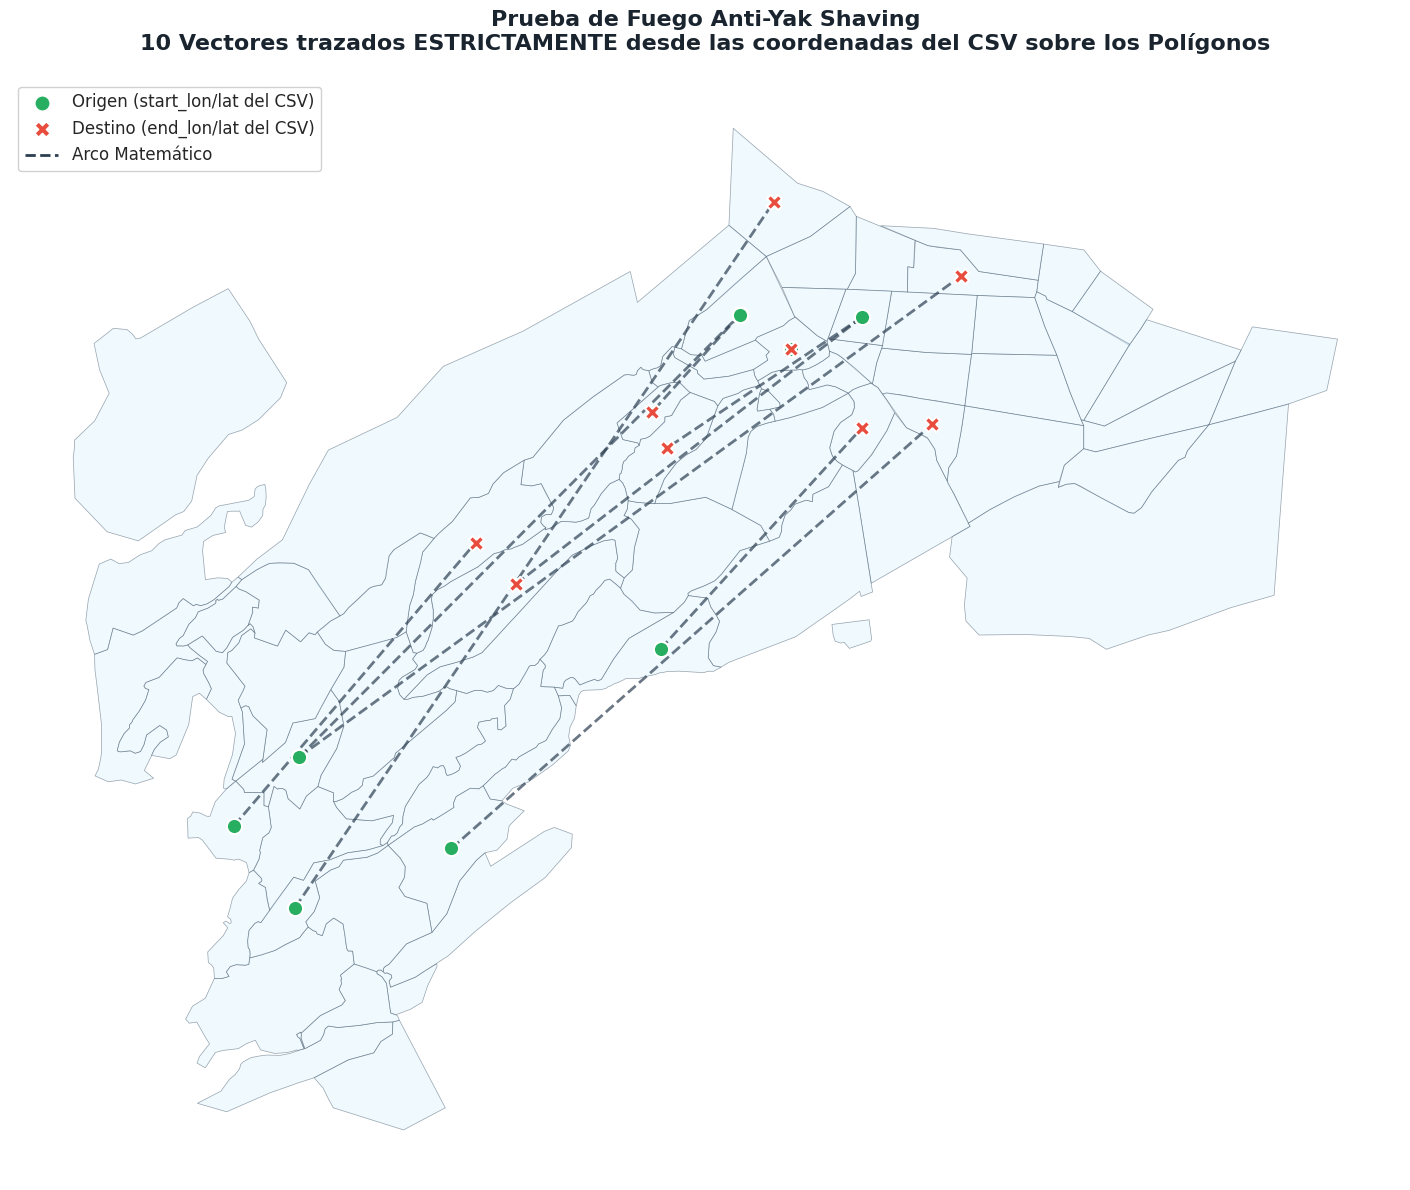

✅ Prueba finalizada. Los círculos verdes y las X rojas deben estar clavados en el centro de sus polígonos.


In [45]:
# ==============================================================================
# Cell: AUDITORÍA VISUAL (CSV vs GeoJSON) - 10 Random Trips
# Objetivo: Mapear los centroides del CSV sobre los polígonos para evitar Yak Shaving.
# ==============================================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

print("🛡️ Iniciando prueba de fuego: Mapeo estricto CSV -> GeoJSON")

# 1. Cargar Inputs (Cero trampa, puro disco)
csv_path = '/workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv'
geojson_path = '/workspaces/pienza/assets/poly.geojson'

df_csv = pd.read_csv(csv_path)
gdf_poly = gpd.read_file(geojson_path)

# 2. Extraer 10 viajes aleatorios
# Usamos random_state=42 para que si la corres dos veces te muestre los mismos 10 y puedas analizarlos
df_muestra = df_csv.sample(n=10, random_state=42).reset_index(drop=True)

# 3. Mostrar la tabla de los 10 viajes
print("\n📋 TABLA: 10 Viajes Aleatorios (Extraídos crudos del CSV):")
display(df_muestra[['origen_id', 'destino_id', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat']])

# 4. Trazar el mapa
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#F8F9F9')

# A. Dibujar Polígonos (Capa base usando el GeoJSON original)
gdf_poly.plot(ax=ax, facecolor='#E1F5FE', edgecolor='#34495E', linewidth=0.5, alpha=0.5)

# B. Dibujar los 10 vectores usando ESTRICTAMENTE las coordenadas del CSV
for idx, row in df_muestra.iterrows():
    slon, slat = row['start_lon'], row['start_lat']
    elon, elat = row['end_lon'], row['end_lat']
    
    # Trazar la línea del trayecto
    ax.plot([slon, elon], [slat, elat], color='#2C3E50', linewidth=2, linestyle='--', alpha=0.7, zorder=2)
    
    # Trazar punto de Origen (Verde)
    ax.scatter(slon, slat, color='#27AE60', s=120, edgecolor='white', linewidth=1.5, zorder=3)
    
    # Trazar punto de Destino (Rojo, con forma de X)
    ax.scatter(elon, elat, color='#E74C3C', s=120, edgecolor='white', linewidth=1.5, marker='X', zorder=3)

# Añadir leyenda manual para entender el mapa
ax.scatter([], [], color='#27AE60', s=120, edgecolor='white', label='Origen (start_lon/lat del CSV)')
ax.scatter([], [], color='#E74C3C', s=120, edgecolor='white', marker='X', label='Destino (end_lon/lat del CSV)')
ax.plot([], [], color='#2C3E50', linewidth=2, linestyle='--', label='Arco Matemático')

plt.title("Prueba de Fuego Anti-Yak Shaving\n10 Vectores trazados ESTRICTAMENTE desde las coordenadas del CSV sobre los Polígonos", 
          fontsize=16, fontweight='black', pad=20, color='#1A242F')
plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Prueba finalizada. Los círculos verdes y las X rojas deben estar clavados en el centro de sus polígonos.")

In [46]:
# ==============================================================================
# Cell X.X: ENGRASANDO EL CSV - Edge Centrality Metrics
# Objetivo: Inyectar Betweenness, Closeness y PageRank al CSV original sin alterar lo existente.
# ==============================================================================
import pandas as pd
import networkx as nx
import numpy as np

print("🧪 Iniciando Inyección de Métricas de Aristas (Edge-Level Analysis)...")

# 1. CARGAR EL CSV ORIGINAL (Intocable)
input_path = "/workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv"
output_path = "/workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_edge_centrality.csv"

df_base = pd.read_csv(input_path)
print(f"✅ CSV Original cargado con {len(df_base)} aristas.")

# 2. RECONSTRUCCIÓN DEL GRAFO (Desde el Tensor)
vol_tensor = pienza_tensor[:, :, :, :, :, 0]
eph_tensor = pienza_tensor[:, :, :, :, :, 1]

num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)

# Usamos zonas_ordenadas para mantener la nomenclatura de tus IDs
mapping = {i: name for i, name in enumerate(zonas_ordenadas)}
G_functional = nx.relabel_nodes(G_functional, mapping)

for u, v, data in G_functional.edges(data=True):
    data['distance'] = 1.0 / data['weight'] if data['weight'] > 0 else float('inf')

# 3. CREACIÓN DEL LINE GRAPH (Dual de la Red)
L_G = nx.line_graph(G_functional)

for edge_node in L_G.nodes():
    u, v = edge_node
    L_G.nodes[edge_node]['weight'] = G_functional[u][v]['weight']
    L_G.nodes[edge_node]['distance'] = G_functional[u][v]['distance']

print(f"✅ Line Graph construido: {L_G.number_of_nodes()} trayectos operativos analizados.")

# 4. CÁLCULO DE LAS 3 MÉTRICAS MAESTRAS
ebet_cent = nx.edge_betweenness_centrality(G_functional, weight='distance', normalized=True)
eclo_cent = nx.closeness_centrality(L_G, distance='distance')
epr_cent = nx.pagerank(L_G, weight='weight', alpha=0.85)

# Empaquetamos en un DataFrame intermedio
df_metrics = pd.DataFrame([
    {
        'origen_id': u, 
        'destino_id': v, 
        'edge_betweenness': ebet_cent.get((u, v), 0),
        'edge_closeness': eclo_cent.get((u, v), 0),
        'edge_pagerank': epr_cent.get((u, v), 0)
    }
    for u, v in G_functional.edges()
])

# Normalización para la visualización (Escala 0-1)
cols_norm = ['edge_betweenness', 'edge_closeness', 'edge_pagerank']
for col in cols_norm:
    if df_metrics[col].max() > 0:
        df_metrics[col] = df_metrics[col] / df_metrics[col].max()

# 5. MERGE INCREMENTAL (El momento de la verdad)
# Hacemos un 'left merge' para asegurar que el archivo base no pierda ni gane renglones, solo agregue columnas
df_final = pd.merge(df_base, df_metrics, on=['origen_id', 'destino_id'], how='left')

# Llenamos con 0 en caso de que haya algún trayecto que el grafo no procesó
df_final[cols_norm] = df_final[cols_norm].fillna(0)

# 6. EXPORTAR EL NUEVO CSV
df_final.to_csv(output_path, index=False)
print("\n" + "="*80)
print(f"🎉 ¡Éxito! Nueva versión de la base de datos exportada en:")
print(f"   -> {output_path}")
print("="*80)
print(f"Nuevas columnas disponibles: {list(df_final.columns)}")

🧪 Iniciando Inyección de Métricas de Aristas (Edge-Level Analysis)...
✅ CSV Original cargado con 2440 aristas.
✅ Line Graph construido: 2440 trayectos operativos analizados.



🎉 ¡Éxito! Nueva versión de la base de datos exportada en:
   -> /workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_edge_centrality.csv
Nuevas columnas disponibles: ['origen_id', 'destino_id', 'rank_ruta', 'volumen_historico', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'edge_betweenness', 'edge_closeness', 'edge_pagerank']


In [47]:
# ==============================================================================
# Cell X.X: ENGRASANDO EL CSV - Trinidad Económica (EPH y Masa)
# Objetivo: Inyectar eph_maestro y masa_economica al CSV original mediante un Merge.
# ==============================================================================
import pandas as pd
import numpy as np

print("💰 Iniciando Inyección de Variables Económicas (EPH y Masa)...")

# 1. CARGAR EL CSV ORIGINAL (Intocable)
input_path = "/workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_edge_centrality.csv"
output_path = "/workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_eph_maestro.csv"

df_base = pd.read_csv(input_path)
print(f"✅ CSV Original cargado con {len(df_base)} aristas.")

# 2. EXTRACCIÓN DE LA FÍSICA ECONÓMICA (Desde el Tensor)
# vol_tensor: (orig, dest, hr, day, week)
vol_tensor = pienza_tensor[:, :, :, :, :, 0]
eph_tensor = pienza_tensor[:, :, :, :, :, 1]

# Masa Económica (num) y Volumen Histórico Total (den)
num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))

# EPH Maestro Ponderado (W_master)
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

# 3. EMPAQUETADO EN DATAFRAME INTERMEDIO
# Iteramos sobre la matriz para crear una lista plana de [origen, destino, masa, eph]
econ_data = []
for i, origin in enumerate(zonas_ordenadas):
    for j, dest in enumerate(zonas_ordenadas):
        masa_val = float(num[i, j])
        eph_val = float(W_master[i, j])
        
        # Solo guardamos aristas que tengan actividad para no inflar la memoria
        if masa_val > 0 or den[i, j] > 0:
            econ_data.append({
                'origen_id': origin,
                'destino_id': dest,
                'masa_economica': masa_val,
                'eph_maestro': eph_val
            })

df_econ = pd.DataFrame(econ_data)
print(f"✅ Diccionario económico construido con {len(df_econ)} trayectos activos.")

# 4. MERGE INCREMENTAL (El momento de la verdad)
# Hacemos un 'left merge' para asegurar que el archivo base mantenga su estructura exacta
df_final = pd.merge(df_base, df_econ, on=['origen_id', 'destino_id'], how='left')

# Llenamos con 0 las rutas que no tuvieron actividad económica (si las hubiera)
df_final['masa_economica'] = df_final['masa_economica'].fillna(0)
df_final['eph_maestro'] = df_final['eph_maestro'].fillna(0)

# 5. EXPORTAR EL NUEVO CSV MAESTRO
df_final.to_csv(output_path, index=False)
print("\n" + "="*80)
print(f"🎉 ¡Éxito! Nueva versión enriquecida exportada en:")
print(f"   -> {output_path}")
print("="*80)
print(f"Columnas disponibles ahora: {list(df_final.columns)}")

💰 Iniciando Inyección de Variables Económicas (EPH y Masa)...
✅ CSV Original cargado con 2440 aristas.
✅ Diccionario económico construido con 2440 trayectos activos.

🎉 ¡Éxito! Nueva versión enriquecida exportada en:
   -> /workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_eph_maestro.csv
Columnas disponibles ahora: ['origen_id', 'destino_id', 'rank_ruta', 'volumen_historico', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'edge_betweenness', 'edge_closeness', 'edge_pagerank', 'masa_economica', 'eph_maestro']
